# SI Code 02 (T0-shift) | TEXAS analysis

The T0-shift counterpart of `SI_code2_TEXAS_analysis.ipynb`, which stays the
**parent additive-EIV** analysis of the original submission. This exists so the
revision can switch to T0-shift without touching that record.

Identical except the model and what follows from it:

| | parent (`SI_code2`) | T0-shift (here) |
|---|---|---|
| model | `..._priorApprox_eiv` | `..._priorApprox_eiv_t0shift` |
| coefficients | `beta_G23_crtp`, `beta_NO3_crtp` | `gamma_G23_crtp`, `gamma_NO3_crtp` |
| where they enter | the response, outside the logistic | the inflection point T₀, inside it |
| units | Scaled RI | °C |
| sign | β negative | γ positive |
| figures | `figN.pdf` | `figN_t0shift.pdf` |

The units and the sign are why β and γ cannot share an axis, and why the
corrected-curve cells are genuinely different rather than renamed: a T0-shift
correction shifts the curve **along the temperature axis**, it does not raise
or lower it.

Every figure filename carries `_t0shift`, so running this cannot overwrite
the parent's figures.


In [1]:
# ── Sampling knob ──────────────────────────────────────────────────────────
#
# False (default): read the cached posteriors and draw the figures.
# True:            re-run Stan, which OVERWRITES the cached posteriors.
#
# This exists because save_posterior writes one canonical path per
# calibration and replaces what is there. Without the guard, opening this
# notebook and running all cells silently discards the audited 400/1000
# posteriors that scripts/run_manuscript_refits.py produced and that the
# comparability audit signed off -- and the replacements would be at this
# notebook's own budget, so the two model arms would no longer be comparable.
RUN_STAN = False


In [2]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.12.8


# Python libraries

In [3]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle

## for kriging plotting
from scipy.spatial import cKDTree
from pykrige.ok import OrdinaryKriging

import cartopy.crs as ccrs
import cmocean.cm as cmo

try:
    import ultraplot as plot
except ImportError:
    plot = None  # proplot is optional; install via: pip install ultraplot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',   # <- lines 51-57
                    'font.weight': 'normal',                #    swap this whole
                    'axes.labelweight': 'normal',           #    update() call
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need
%load_ext autoreload
%autoreload 2
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior
from TEXAS.stan.io import load_posterior, save_posterior
from TEXAS import predict_T_from_proxyObs, predict_proxy_from_T
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.data import MahalanobisOutlierDetector, build_invT_inputData, build_fwd_data
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial

0.2.6


In [4]:
# ── Posterior names: ask TEXAS for them, do not spell them out ──────────────
#
# Every load_posterior() below used to carry a hand-written ~90-char name like
#     gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift_SST_gdgt23ratio_no3_1.0_scaledRI_cren3
# and after the 2026-08-12 refit that is the wrong thing to ask for in a way
# that does NOT raise. The refit writes short case ids (tx.GHEB.sst.sri03.G23-N10),
# and resolve_posterior_path tries an exact legacy-name hit FIRST. For culmeso
# and the univariate baseline an old flat file still exists, so the legacy name
# resolves -- silently, to the PRE-refit posterior. The five-layer figures below
# were mixing calibrations that way: legacy culmeso t0 mean 35.80 vs refit 35.64,
# univariate SST 34.17 vs 34.06.
#
# Building the name from attrs is the same call save_posterior makes, so it
# cannot drift from what is on disk.
from TEXAS.utils.naming import case_from_attrs, resolve_posterior_path
from TEXAS.utils.paths import POSTERIOR_CACHE_DIR

BND_STEM     = 'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift'
EIV_STEM     = 'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv'
UNIV_STEM    = 'gen_logi_fixed_hier_crtp_univ_priorApprox'
CULMESO_STEM = 'gen_logi_fixed_culmeso'


def fwd_name(temptype, y_param='scaledRI_cren3', *, stem=BND_STEM,
             gdgt23ratio=False, no3_cutoff=None):
    """Case id of a forward calibration, e.g. ``tx.GHEB.sst.sri03.G23-N10``.

    ``temptype`` takes either the column ('t_sf2tc_avg') or the label
    ('thermoT') -- both name the same case.
    """
    temptype = {'t_sf2tc_avg': 'thermoT'}.get(temptype, temptype)
    attrs = {'stan_model_name': stem,
             'temptype': temptype,
             'proxy_name': y_param,
             'use_gdgt23ratio': int(bool(gdgt23ratio)),
             'use_no3': int(no3_cutoff is not None)}
    if no3_cutoff is not None:
        attrs['no3_cutoff'] = float(no3_cutoff)
    return str(case_from_attrs(attrs))


def culmeso_name(y_param='scaledRI_cren3'):
    """Stage-1 culture+mesocosm case id, e.g. ``tx.GCDU.cul.sri03.p0``."""
    return fwd_name('cultureT', y_param, stem=CULMESO_STEM)


def fwd_exists(name) -> bool:
    """Is this calibration in the cache, under any layout?"""
    return resolve_posterior_path(str(name), POSTERIOR_CACHE_DIR) is not None


# Preflight. T0-shift was fitted later than the additive arm and its grid is
# not complete; a MISSING row here is a figure layer that will not draw, and it
# is much cheaper to see that now than forty cells later.
_y = 'scaledRI_cren3'
print(f"{'target':8s} {'predictors':13s} {'case id':30s} present")
print('-' * 60)
print(f"{'culture':8s} {'--':13s} {culmeso_name(_y):30s} "
      f"{'yes' if fwd_exists(culmeso_name(_y)) else 'MISSING'}")
for _tp in ('SST', 'thermoT'):
    for _g, _c, _d in ((None, None, 'thermal only'), (True, None, 'G23'),
                       (False, 1.0, 'NO3'), (True, 1.0, 'G23 + NO3')):
        _n = (fwd_name(_tp, _y, stem=UNIV_STEM) if _d == 'thermal only'
              else fwd_name(_tp, _y, gdgt23ratio=bool(_g), no3_cutoff=_c))
        print(f"{_tp:8s} {_d:13s} {_n:30s} "
              f"{'yes' if fwd_exists(_n) else 'MISSING'}")


target   predictors    case id                        present
------------------------------------------------------------
culture  --            tx.GCDU.cul.sri03.p0           yes
SST      thermal only  tx.GHPU.sst.sri03.p0           yes
SST      G23           tx.GHEB.sst.sri03.G23          yes
SST      NO3           tx.GHEB.sst.sri03.N10          yes
SST      G23 + NO3     tx.GHEB.sst.sri03.G23-N10      yes
thermoT  thermal only  tx.GHPU.thm.sri03.p0           yes
thermoT  G23           tx.GHEB.thm.sri03.G23          yes
thermoT  NO3           tx.GHEB.thm.sri03.N10          yes
thermoT  G23 + NO3     tx.GHEB.thm.sri03.G23-N10      yes


# Cosmetic settings

In [5]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype_marker_dict = {
    'culture':'^',
    'mesocosm':'s',
    'coretop':'.',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

# Miscellaneous functions

In [6]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient


import inspect
from IPython.display import Markdown
def display_function_signature(func):
    sig = inspect.signature(func)
    params = []
    for param_name, param in sig.parameters.items():
        if param.default != inspect.Parameter.empty:
            params.append(f"    {param_name}={param.default}")
        else:
            params.append(f"    {param_name}")

    formatted = f"{func.__name__}(\n" + ",\n".join(params) + "\n)"
    return Markdown(f"```python\n{formatted}\n```")

In [7]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.021,0.105), #(0.021,0.105)  <--- recalculated from the Fig S2 in O'Brien et al., 2017 | (0.0170,0.19) <--- shown in the main text of O'Brien et al., 2017
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

In [8]:
# ── sig-fig helpers (self-contained) ─────────────────────────────────────────

def _n_decimals(scale: float) -> int:
    """Decimal places needed to show `scale` to 1-2 sig figs (GUM §7.2.6)."""
    if not math.isfinite(scale) or scale <= 0:
        return 3
    mag = math.floor(math.log10(abs(scale)))
    first_digit = int(abs(scale) / 10 ** mag)
    return max(0, 1 - mag) if first_digit <= 3 else max(0, -mag)


def _format_stat(median: float, std: float, fmt: str | None = None) -> str:
    """Return 'median ± std' formatted to appropriate significant figures.
    Uncertainty drives precision: 1 sig fig on std (2 if leading digit <= 3).

    Parameters
    ----------
    fmt : str or None
        Optional format spec override (e.g. ``'.3f'``, ``'.2e'``).
        When given, both median and std are formatted with this spec and
        the automatic sig-fig logic is bypassed entirely.
    """
    if fmt is not None:
        return f"{median:{fmt}} ± {std:{fmt}}"
    if not math.isfinite(std) or std <= 0:
        return f"{median:.3g}"
    n_dec = _n_decimals(std)
    fmt   = f".{n_dec}f"
    return f"{round(median, n_dec):{fmt}} ± {round(std, n_dec):{fmt}}"


# ── formatting helpers ────────────────────────────────────────────────────────

def _fmt_r2(r2: float) -> str:
    """R² precision driven by unexplained variance; capped at 3 d.p."""
    n = min(_n_decimals(1 - r2), 3)
    return f"{round(r2, n):.{n}f}"


def _fmt_rmse(rmse: float) -> str:
    """RMSE always reported to 2 sig figs."""
    mag = math.floor(math.log10(abs(rmse)))
    n   = max(0, 1 - mag)
    return f"{round(rmse, n):.{n}f}"


def _fmt_delta_r2(dr2: float) -> str:
    if abs(dr2) == 0:
        return f"{dr2:.3f}"
    n = _n_decimals(abs(dr2))
    return f"{round(dr2, n):.{n}f}"


def _fmt_p(p: float) -> str:
    if p < 0.001:
        return "<0.001"
    mag = math.floor(math.log10(abs(p)))
    return f"{round(p, -mag + 1):.2e}"


def _fmt_coef(coef: float, ci_halfwidth: float) -> str:
    """coef ± 95% CI, precision driven by CI half-width."""
    sigma = ci_halfwidth / 1.96
    return _format_stat(coef, sigma)


def _fmt_delta(delta: float) -> str:
    """Delta to 2 sig figs with sign."""
    if abs(delta) == 0:
        return "+0.000"
    d_mag = math.floor(math.log10(abs(delta)))
    nd    = max(0, 1 - d_mag)
    return f"{delta:+.{nd}f}"


## Logistic equations

In [9]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def inverse_generalized_logistic_model_fixed_upper(y, x0, b, k, v):
    """
    Inverse of the generalized logistic model function with a fixed upper asymptote.
    Parameters:
    - y: The output value for which to compute the inverse.
    - x0: Inflection point
    - b: Lower asymptote (left asymptote)
    - k: Slope
    - v: Shape parameter
    Returns:
    - The input value x corresponding to the output y in the generalized logistic model.
    """
    term = ((1 - b) / (y - b))**v - 1
    x = x0 - (np.log(term) / k)
    return x

In [10]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

# Set local path

In [11]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

# Detect environment
IN_DOCKER = Path("/home/micromamba/app").exists()

if IN_DOCKER:
    local_onedrive_path = Path("/mnt/onedrive")
    local_github_path = Path("/home/micromamba/app")
    print(local_github_path)
else:
    local_onedrive_path = Path.home() / "OneDrive"   # adjust if needed
    local_github_path = Path.home() / "Documents/GitHub/TEXAS"
    print(local_github_path)

Set CMDSTAN -> /home/ronnie-rattan/.cmdstan/cmdstan-2.36.0
/home/ronnie-rattan/Documents/GitHub/TEXAS


In [12]:
print(local_github_path)

/home/ronnie-rattan/Documents/GitHub/TEXAS


In [13]:
### Regression dataset compilation
fpath = os.path.join(local_github_path,'data/spreadsheets')
fname = r'ds_gridded_screened_global_compilation_finalized.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,scaledRI_noCrens,t_sf2tc_avg,thermoNO3_se,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5,ocean_region_id,ocean_region,ocean_region_abbrev
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.014819,-1.636017,0.158812,1.761114,1.533491,1.647303,1.874926,24.0,Weddell Sea,Weddell Sea
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.024862,-1.586854,0.000000,1.575668,1.421365,1.498516,1.652819,27.0,Ross Sea,Ross Sea
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.015979,-1.692642,0.131073,1.648903,1.464398,1.556650,1.741155,24.0,Weddell Sea,Weddell Sea
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.013538,-1.498910,0.158812,1.547138,1.425926,1.486532,1.607744,24.0,Weddell Sea,Weddell Sea
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.013332,-1.651191,0.041285,1.604469,1.425698,1.515084,1.693855,24.0,Weddell Sea,Weddell Sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,...,0.208941,22.000000,NaN,1.673550,1.594122,1.633836,1.713264,NaN,NaN,NaN
1572,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,...,0.217802,25.000000,NaN,1.793452,1.683386,1.738419,1.848485,NaN,NaN,NaN
1573,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,...,0.177191,32.000000,NaN,2.269506,1.779857,2.024682,2.514331,NaN,NaN,NaN
1574,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,...,0.444013,36.000000,NaN,2.414045,1.989968,2.202006,2.626083,NaN,NaN,NaN


In [14]:
def pred_texRI_fn(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Calibration posteriors

In [15]:
if not RUN_STAN:
    print('RUN_STAN = False -> using the cached posterior. '
          'Set it True only if you mean to refit and overwrite.')
else:
    # Save data for Stan
    y_params = ['scaledRI_cren3']
    for y_param in y_params:
        cul_df = gridded_combined_df[gridded_combined_df['datatype']=='culture'].dropna(subset=[y_param,'SST']).reset_index(drop=True)
        meso_df = gridded_combined_df[gridded_combined_df['datatype']=='mesocosm'].dropna(subset=[y_param,'SST']).reset_index(drop=True)
        data = build_fwd_data(
            t_cul = cul_df['SST'].values,
            proxy_cul = cul_df[y_param].values,
            t_meso = meso_df['SST'].values,
            proxy_meso = meso_df[y_param].values,
        )

        stan_file_name = 'gen_logi_fixed_culmeso'
        gen_logi_fixed_cul_meso_post_ds, diag = get_posterior(
                     data=data, 
                     proxy_name=y_param,
                     stan_file=stan_file_name,
                     temptype='cultureT')


        # Save posteriors
        save_posterior(gen_logi_fixed_cul_meso_post_ds,filename_suffix="")



RUN_STAN = False -> using the cached posterior. Set it True only if you mean to refit and overwrite.


#### Appendix A | Prior and posterior distributions for the TEXAS top-layer (culture and mesocosm) model parameters

In [16]:
load_posterior("tx.GCDU.cul.sri03.p0")

<xarray.Dataset> Size: 200kB
Dimensions:              (chain: 4, draw: 1000)
Coordinates:
  * chain                (chain) int64 32B 1 2 3 4
  * draw                 (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    t0_culmeso           (chain, draw) float64 32kB 39.82 34.71 ... 39.61 35.08
    k_culmeso            (chain, draw) float64 32kB 0.2528 0.254 ... 0.3324
    v_culmeso            (chain, draw) float64 32kB 3.901 2.119 ... 3.513 2.911
    b_culmeso            (chain, draw) float64 32kB 0.3811 0.4661 ... 0.4666
    sigma_proxyObs_cul   (chain, draw) float64 32kB 0.1003 0.07704 ... 0.0991
    sigma_proxyObs_meso  (chain, draw) float64 32kB 0.05793 0.08303 ... 0.06881
Attributes: (12/43)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_culmeso_model
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_culmeso
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS
    case_id:                      tx.GCDU.cul.sri03.p0
    filename:                     tx.GCDU.cul.sri03.p0.fwd.nc
    iter_warmup:                  400
    iter_warmup_source:           asserted from manifest.csv; not recoverable...

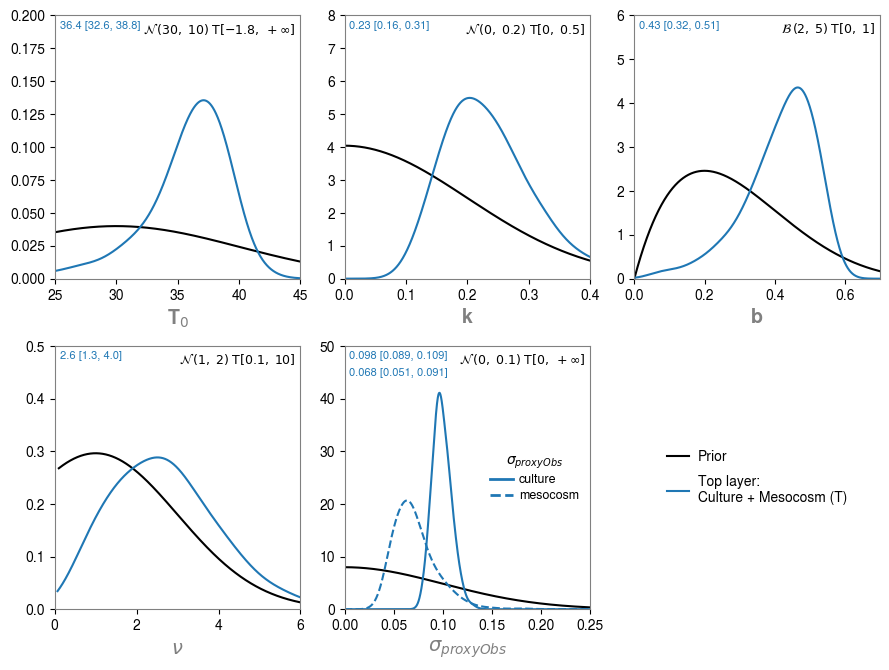

In [17]:
legend_labels = ['Top layer: Culture + Mesocosm (Culturing/Mesocosm T)',
                 'Prior']
# ── Forward posteriors from 032326 run ────────────────────────────────────────              
post_fwd = [
    "tx.GCDU.cul.sri03.p0", 
]  

fig, axs = plot_prior_distributions(
    posterior_datasets=post_fwd,
    posterior_labels_list=legend_labels,
    use_linestyle_by_param=True,
    show_histogram=False,
    set_leg_max_ncol=1,
    set_fig_height_factor=3,
    show_suptitle=False,
    show_annotation=True,
    show_subplot_legend=False,
    show_figure_legend=False,
    show_prior_expression=True,
    annotation_style='ci68'
)

axs[0,0].set_xlim(25,45)
axs[0,0].set_ylim(0,0.2)
axs[0,1].set_xlim(0,0.4)
axs[0,1].set_ylim(0,8)
axs[0,2].set_xlim(0,0.7)
axs[0,2].set_ylim(0,6)
axs[1,0].set_xlim(0,6)
axs[1,0].set_ylim(0,0.5)
# sigma_proxyObs panel (added 2026-08-13). These limits used to sit on an EMPTY
# axis -- a leftover from a layout with more panels -- so they would have been
# inherited by the noise panel and squashed it flat (sigma is ~0.04-0.13, not 0-6).
axs[1,1].set_xlim(0,0.25)
axs[1,1].set_ylim(0,50)
axs[1,2].set_xlim(-0.01,0)
axs[1,2].set_ylim(0,1200)
fig.tight_layout()

for ax in axs.flatten():
    
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, color="gray", fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, color="gray", fontweight='bold')
    
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, color="gray")
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, color="gray")
    
    ax.spines[:].set_color("gray")
    
    
    ax.grid(False)
    ax.set_ylim(bottom=0)
    
# Legend moved out of axs[1,1] (2026-08-13): that cell used to be empty and was
# a convenient place to park the legend. It now holds the sigma_proxyObs panel,
# where the legend sat on top of the credible-interval annotations. Anchored to
# the still-empty bottom-right cell instead.
#
# The third entry is not decoration: the top layer estimates a SEPARATE noise
# scale for culture and for mesocosm data, drawn solid and dashed in that panel.
# Without a key the dashed curve is unidentifiable, which is the same class of
# omission the noise terms themselves were.
from matplotlib.lines import Line2D as _Line2D

h, _ = axs[0, 0].get_legend_handles_labels()
prior_h, post_h = h[0], h[-1]
post_c = post_h.get_color()

# plot_prior_distributions() ends with set_visible(False) on any axes without
# data, so the empty bottom-right cell must be switched back on before it can
# host a legend. axis('off') keeps it blank.
leg_ax = axs[1, 2]
leg_ax.set_visible(True)
leg_ax.axis('off')
leg_ax.legend(handles=[prior_h, post_h],
              labels=['Prior', 'Top layer:\nCulture + Mesocosm (T)'],
              loc='center', fontsize=10, frameon=False,
              handlelength=1.6, handletextpad=0.6, labelspacing=0.8)

# The solid/dashed split is local to this panel -- it separates the two noise
# scales, not two datasets -- so its key belongs here rather than in the figure
# legend, where 'solid' already means 'posterior'.
axs[1, 1].legend(handles=[_Line2D([], [], color=post_c, lw=2, ls='-'),
                          _Line2D([], [], color=post_c, lw=2, ls='--')],
                 labels=['culture', 'mesocosm'],
                 title=r'$\sigma_{proxyObs}$',
                 loc='center right', fontsize=9, title_fontsize=10,
                 frameon=False, handlelength=1.8, handletextpad=0.5,
                 labelspacing=0.3)



fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'AppendixA_culmesoT_prior_distributions_t0shift.pdf'),dpi=300,bbox_inches="tight",)

# Coretop analysis

In [18]:
coretop_df = gridded_combined_df[gridded_combined_df['datatype']=='coretop'].dropna(subset=['no3_sf2tc_avg', 'SST']).reset_index(drop=True)
coretop_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,scaledRI_noCrens,t_sf2tc_avg,thermoNO3_se,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5,ocean_region_id,ocean_region,ocean_region_abbrev
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.014819,-1.636017,0.158812,1.761114,1.533491,1.647303,1.874926,24.0,Weddell Sea,Weddell Sea
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.024862,-1.586854,0.000000,1.575668,1.421365,1.498516,1.652819,27.0,Ross Sea,Ross Sea
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.015979,-1.692642,0.131073,1.648903,1.464398,1.556650,1.741155,24.0,Weddell Sea,Weddell Sea
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.013538,-1.498910,0.158812,1.547138,1.425926,1.486532,1.607744,24.0,Weddell Sea,Weddell Sea
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.013332,-1.651191,0.041285,1.604469,1.425698,1.515084,1.693855,24.0,Weddell Sea,Weddell Sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,84.125,46.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,0.026794,-1.237260,0.013632,1.680000,1.445333,1.562667,1.797333,0.0,Arctic Ocean,Arctic Ocean
1509,84.875,40.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,0.038654,-1.373924,0.257496,1.635830,1.424415,1.530122,1.741537,0.0,Arctic Ocean,Arctic Ocean
1510,86.875,-146.125,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,0.054241,-1.474355,0.022468,1.987319,1.454710,1.721014,2.253623,0.0,Arctic Ocean,Arctic Ocean
1511,87.125,104.625,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,0.051712,-1.377392,0.037861,2.089165,1.560948,1.825056,2.353273,0.0,Arctic Ocean,Arctic Ocean


In [19]:
if not RUN_STAN:
    print('RUN_STAN = False -> using the cached posterior. '
          'Set it True only if you mean to refit and overwrite.')
else:
    temp_params = ['SST',
                #    't_sf2tc_avg'
                   ]
    y_params = ['scaledRI_cren3']
    reg_data = coretop_df[[*temp_params, *y_params]].dropna()   

    for temp_param in temp_params:
        for y_param in y_params:                 
            # Load the matching culmeso posterior for this proxy
            # (saved in stage 1 with suffix from save_posterior filename)             
            culmeso_post = load_posterior(       
                culmeso_name(y_param)                   
            )     
                    
            data = build_fwd_data(               
                t_crtp=reg_data[temp_param].values,
                proxy_crtp=reg_data[y_param].values,   
                culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors         
            )     
             
            gen_logi_crtp_post_ds, diag = get_posterior(                              
                data=data,
                proxy_name=y_param,              
                stan_file='gen_logi_fixed_hier_crtp_univ_priorApprox',
                temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),                  
            )     
            save_posterior(gen_logi_crtp_post_ds, filename_suffix="")  

RUN_STAN = False -> using the cached posterior. Set it True only if you mean to refit and overwrite.


In [20]:
if not RUN_STAN:
    print('RUN_STAN = False -> using the cached posterior. '
          'Set it True only if you mean to refit and overwrite.')
else:
    temp_params = ['SST',
                #    't_sf2tc_avg'
                   ]
    y_params = ['scaledRI_cren3']
    secondary_predictors = ['gdgt23ratio']
    reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors,               
        'gdgt23ratio_se']].dropna()   

    for temp_param in temp_params:
        for y_param in y_params:                 
            # Load the matching culmeso posterior for this proxy
            # (saved in stage 1 with suffix from save_posterior filename)             
            # ── Stage 1: culmeso posterior (same as before) ───────────────────    
            culmeso_post = load_posterior(
                culmeso_name(y_param)                 
            )         

            # ── R2_thermal: extract from existing thermal-only coretop posterior   
            # Use the univ priorApprox run (no G23, no NO3) as the thermal baseline.
            _temptype = {'t_sf2tc_avg': 'thermoT'}.get(temp_param, temp_param)      
            thermal_post = load_posterior(           
                fwd_name(_temptype, y_param, stem=UNIV_STEM) 
            )         
            R2_thermal = float(thermal_post["R2_full"].mean())
            print(f"R2_thermal ({temp_param}, {y_param}): {R2_thermal:.3f}")        
                
            # ── Build data dict ───────────────────────────────────────────────    
            data = build_fwd_data(
                t_crtp               = reg_data[temp_param].values,                 
                proxy_crtp           = reg_data[y_param].values,
                gdgt23ratio_crtp     = reg_data['gdgt23ratio'].values,              
                sd_gdgt23ratio_crtp  = reg_data['gdgt23ratio_se'].values,          
                R2_thermal           = R2_thermal,          # ← new for ver2
                # sd_proxyObs omitted → defaults to 0.03 for all sites              
                culmeso_posterior    = culmeso_post,               
            )  
            # ── Run ver2 model ────────────────────────────────────────────────    
            post, diag = get_posterior(
                data       = data,                   
                proxy_name = y_param,
                stan_file  = 'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift',     
                temptype   = _temptype,              
            )  
            save_posterior(post, filename_suffix="")  

RUN_STAN = False -> using the cached posterior. Set it True only if you mean to refit and overwrite.


In [21]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors, 
#     'thermoNO3_se',]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                 
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)             
#         # ── Stage 1: culmeso posterior (same as before) ───────────────────    
#         culmeso_post = load_posterior(
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}"                 
#         )         

#         # ── R2_thermal: extract from existing thermal-only coretop posterior   
#         # Use the univ priorApprox run (no G23, no NO3) as the thermal baseline.
#         _temptype = {'t_sf2tc_avg': 'thermoT'}.get(temp_param, temp_param)      
#         thermal_post = load_posterior(           
#             f"gen_logi_fixed_hier_crtp_univ_priorApprox_{_temptype}_{y_param}" 
#         )         
#         R2_thermal = float(thermal_post["R2_full"].mean())
#         print(f"R2_thermal ({temp_param}, {y_param}): {R2_thermal:.3f}")               
#         data = build_fwd_data(               
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             no3_crtp             = reg_data['no3_sf2tc_avg'].values,            
#             sd_no3_crtp          = reg_data['thermoNO3_se'].values,          
#             R2_thermal           = R2_thermal,          # ← new for ver2  
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.0
                   
#         )     
               
#         gen_logi_crtp_post_ds, diag = get_posterior(                              
#             data=data,
#             proxy_name=y_param,
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                           
#         )     
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="")  

In [22]:
# temp_params = ['SST', 't_sf2tc_avg']                       
# y_params = ['scaledRI_cren3']                         
# secondary_predictors = ['no3_sf2tc_avg', 'gdgt23ratio']           
                            
# # ── Add SD columns alongside the predictors ──────────────────────────────                            
# reg_data = coretop_df[[      
#     *temp_params, *y_params, *secondary_predictors,               
#     'gdgt23ratio_se',       # per-site SE of G₂/₃ (same units as gdgt23ratio)
#     'thermoNO3_se',     # per-site SE of NO₃ (µmol/L)         
# ]].dropna()

# for temp_param in temp_params:                   
#     for y_param in y_params:

#         # ── Stage 1: culmeso posterior (same as before) ───────────────────    
#         culmeso_post = load_posterior(
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}"                 
#         )         

#         # ── R2_thermal: extract from existing thermal-only coretop posterior   
#         # Use the univ priorApprox run (no G23, no NO3) as the thermal baseline.
#         _temptype = {'t_sf2tc_avg': 'thermoT'}.get(temp_param, temp_param)      
#         thermal_post = load_posterior(           
#             f"gen_logi_fixed_hier_crtp_univ_priorApprox_{_temptype}_{y_param}" 
#         )         
#         R2_thermal = float(thermal_post["R2_full"].mean())
#         print(f"R2_thermal ({temp_param}, {y_param}): {R2_thermal:.3f}")        
                
#         # ── Build data dict ───────────────────────────────────────────────    
#         data = build_fwd_data(
#             t_crtp               = reg_data[temp_param].values,                 
#             proxy_crtp           = reg_data[y_param].values,
#             gdgt23ratio_crtp     = reg_data['gdgt23ratio'].values,              
#             sd_gdgt23ratio_crtp  = reg_data['gdgt23ratio_se'].values,
#             no3_crtp             = reg_data['no3_sf2tc_avg'].values,            
#             sd_no3_crtp          = reg_data['thermoNO3_se'].values,             
#             R2_thermal           = R2_thermal,          # ← new for ver2
#             # sd_proxyObs omitted → defaults to 0.03 for all sites              
#             culmeso_posterior    = culmeso_post, 
#             no3_cutoff           = 1.0,          
#         )         
                
#         # ── Run ver2 model ────────────────────────────────────────────────    
#         post, diag = get_posterior(
#             data       = data,                   
#             proxy_name = y_param,
#             stan_file  = 'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift',     
#             temptype   = _temptype,              
#         )
#         save_posterior(post, filename_suffix="_eiv")      

In [23]:
# temp_params = ['SST', 't_sf2tc_avg']                       
# y_params = ['scaledRI_cren3']                         
# secondary_predictors = ['no3_sf2tc_avg', 'gdgt23ratio']           
                            
# # ── Add SD columns alongside the predictors ──────────────────────────────                            
# reg_data = coretop_df[[      
#     *temp_params, *y_params, *secondary_predictors,               
#     'gdgt23ratio_se',       # per-site SE of G₂/₃ (same units as gdgt23ratio)
#     'thermoNO3_se',     # per-site SE of NO₃ (µmol/L)         
# ]].dropna()

# for temp_param in temp_params:                   
#     for y_param in y_params:

#         # ── Stage 1: culmeso posterior (same as before) ───────────────────    
#         culmeso_post = load_posterior(
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}"                 
#         )         

#         # ── R2_thermal: extract from existing thermal-only coretop posterior   
#         # Use the univ priorApprox run (no G23, no NO3) as the thermal baseline.
#         _temptype = {'t_sf2tc_avg': 'thermoT'}.get(temp_param, temp_param)      
#         thermal_post = load_posterior(           
#             f"gen_logi_fixed_hier_crtp_univ_priorApprox_{_temptype}_{y_param}" 
#         )         
#         R2_thermal = float(thermal_post["R2_full"].mean())
#         print(f"R2_thermal ({temp_param}, {y_param}): {R2_thermal:.3f}")        
                
#         # ── Build data dict ───────────────────────────────────────────────    
#         data = build_fwd_data(
#             t_crtp               = reg_data[temp_param].values,                 
#             proxy_crtp           = reg_data[y_param].values,
#             gdgt23ratio_crtp     = reg_data['gdgt23ratio'].values,              
#             sd_gdgt23ratio_crtp  = reg_data['gdgt23ratio_se'].values,
#             no3_crtp             = reg_data['no3_sf2tc_avg'].values,            
#             sd_no3_crtp          = reg_data['thermoNO3_se'].values,             
#             R2_thermal           = R2_thermal,          # ← new for ver2
#             # sd_proxyObs omitted → defaults to 0.03 for all sites              
#             culmeso_posterior    = culmeso_post, 
#             no3_cutoff           = 1.0,          
#         )         
                
#         # ── Run ver2 model ────────────────────────────────────────────────    
#         post, diag = get_posterior(
#             data       = data,                   
#             proxy_name = y_param,
#             stan_file  = 'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift',     
#             temptype   = _temptype,              
#         )
#         save_posterior(post, filename_suffix="_eiv")      

In [24]:
# temp_params = ['SST', 't_sf2tc_avg']                       
# y_params = ['scaledRI_cren3']                         
# secondary_predictors = ['no3_sf2tc_avg', 'gdgt23ratio']           
                            
# # ── Add SD columns alongside the predictors ──────────────────────────────                            
# reg_data = coretop_df[[      
#     *temp_params, *y_params, *secondary_predictors,               
#     'gdgt23ratio_se',       # per-site SE of G₂/₃ (same units as gdgt23ratio)
#     'thermoNO3_se',     # per-site SE of NO₃ (µmol/L)         
# ]].dropna()

# for temp_param in temp_params:                   
#     for y_param in y_params:

#         # ── Stage 1: culmeso posterior (same as before) ───────────────────    
#         culmeso_post = load_posterior(
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}"                 
#         )         

#         # ── R2_thermal: extract from existing thermal-only coretop posterior   
#         # Use the univ priorApprox run (no G23, no NO3) as the thermal baseline.
#         _temptype = {'t_sf2tc_avg': 'thermoT'}.get(temp_param, temp_param)      
#         thermal_post = load_posterior(           
#             f"gen_logi_fixed_hier_crtp_univ_priorApprox_{_temptype}_{y_param}" 
#         )         
#         R2_thermal = float(thermal_post["R2_full"].mean())
#         print(f"R2_thermal ({temp_param}, {y_param}): {R2_thermal:.3f}")        
                
#         # ── Build data dict ───────────────────────────────────────────────    
#         data = build_fwd_data(
#             t_crtp               = reg_data[temp_param].values,                 
#             proxy_crtp           = reg_data[y_param].values,
#             gdgt23ratio_crtp     = reg_data['gdgt23ratio'].values,              
#             sd_gdgt23ratio_crtp  = reg_data['gdgt23ratio_se'].values,
#             no3_crtp             = reg_data['no3_sf2tc_avg'].values,            
#             sd_no3_crtp          = reg_data['thermoNO3_se'].values,             
#             R2_thermal           = R2_thermal,          # ← new for ver2
#             # sd_proxyObs omitted → defaults to 0.03 for all sites              
#             culmeso_posterior    = culmeso_post, 
#             no3_cutoff           = 1.0,          
#         )         
                
#         # ── Run ver2 model ────────────────────────────────────────────────    
#         post, diag = get_posterior(
#             data       = data,                   
#             proxy_name = y_param,
#             stan_file  = 'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift',     
#             temptype   = _temptype,              
#         )
#         save_posterior(post, filename_suffix="_eiv_t0shift")      

### Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [25]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)> Size: 423MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(102, 720, 1440), dtype=float32)
Coordinates:
  * depth    (depth) float32 408B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

#### Appendix B | Prior and posterior distributions for the TEXAS bottom-layer (coretop) model parameters calibrated to SST

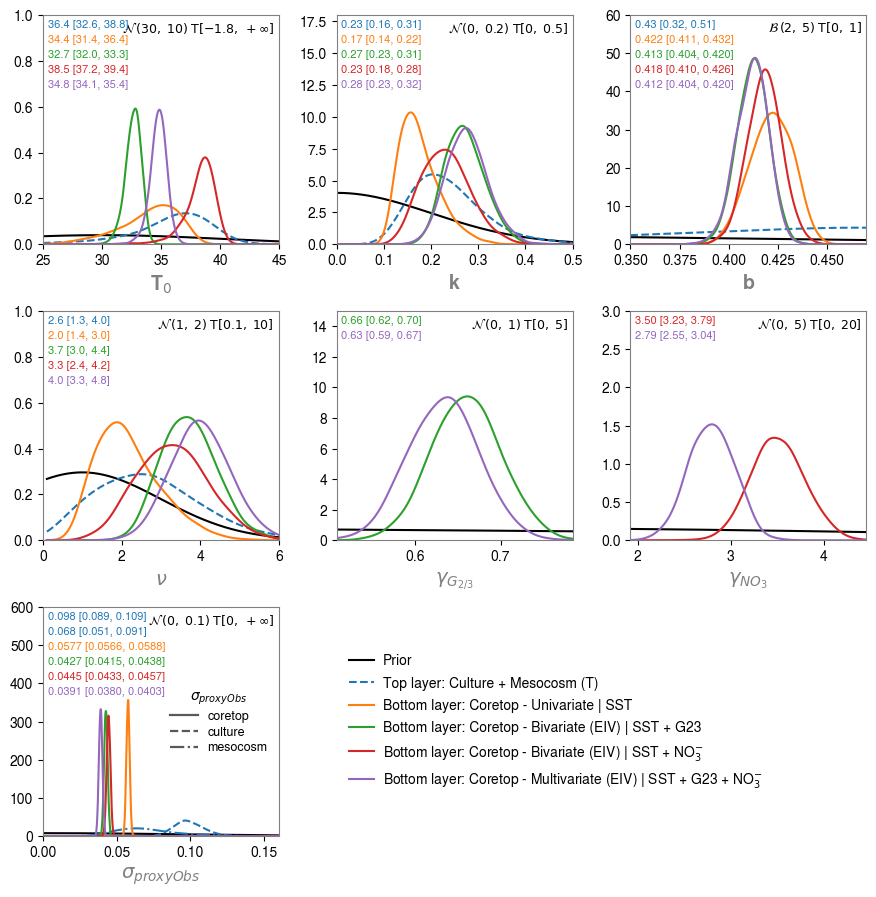

In [26]:
import importlib
import TEXAS.plotting.prior_plot
importlib.reload(TEXAS.plotting.prior_plot)

legend_labels = ['Top layer: Culture + Mesocosm (T)', 
                 'Bottom layer: Coretop - Univariate | SST', 
                 'Bottom layer: Coretop - Bivariate (EIV) | SST + G23', 
                 r'Bottom layer: Coretop - Bivariate (EIV) | SST + NO$_{3}^{-}$',
                 r'Bottom layer: Coretop - Multivariate (EIV) | SST + G23 + NO$_{3}^{-}$',
                 'Prior']
# ── Forward posteriors from 032326 run ────────────────────────────────────────              
post_fwd = [       
    # Stage 1 — culmeso   
    culmeso_name(),            
    # Stage 2 — SST / scaledRI                           
    fwd_name('SST', stem=UNIV_STEM),
    fwd_name('SST', gdgt23ratio=True),
    fwd_name('SST', no3_cutoff=1.0),
    fwd_name('SST', gdgt23ratio=True, no3_cutoff=1.0),      
]  

fig, axs = plot_prior_distributions(
    posterior_datasets=post_fwd,
    posterior_labels_list=legend_labels,
    use_linestyle_by_param=True,
    show_histogram=False,
    set_leg_max_ncol=1,
    set_fig_height_factor=3,
    show_suptitle=False,
    show_annotation=True,
    show_subplot_legend=False,
    show_figure_legend=False,
    show_prior_expression=True,
    annotation_style='ci68'
)

axs[0,0].set_xlim(25,45)
axs[0,0].set_ylim(0,1)
axs[0,1].set_xlim(0,0.5)
axs[0,1].set_ylim(0,18)
axs[0,2].set_xlim(0.35,0.47)
axs[0,2].set_ylim(0,60)
axs[1,0].set_xlim(0,6)
axs[1,0].set_ylim(0,1)

axs[2,0].set_xlim(0,0.16)
axs[2,0].set_ylim(0,600)
# axs[1,1].set_xlim(-0.01,0)
axs[1,1].set_ylim(0,15)
# axs[1,2].set_xlim(-0.07,-0.02)
axs[1,2].set_ylim(0,3)

for ax in axs.flatten():
    
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, color="gray", fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, color="gray", fontweight='bold')
    ax.spines[:].set_color("gray")
    
    
    ax.grid(False)
    ax.set_ylim(bottom=0)
    
from matplotlib.lines import Line2D as _Line2D

# The function reserves bottom space for its own legend whether or not it draws
# one (0.25 + 0.25 per row). Reclaim it -- the legend goes in the empty cells.
n_leg = len(post_fwd) + 1                      # datasets + Prior
w, h = fig.get_size_inches()
fig.set_size_inches(w, h - (0.25 + 0.25 * n_leg))
fig.subplots_adjust(bottom=0.07)

# Span the two hidden bottom-right cells. Reading their positions after the
# resize keeps this correct if the grid ever reflows, unlike a fixed anchor.
p1, p2 = axs[2, 1].get_position(), axs[2, 2].get_position()
h_, l_ = axs[0, 0].get_legend_handles_labels()
fig.legend(h_, ['Prior'] + legend_labels,
           loc='center left',
           bbox_to_anchor=(p1.x0, p1.y0, p2.x1 - p1.x0, p1.height),
           bbox_transform=fig.transFigure,
           ncol=1, fontsize=10, frameon=False,
           handlelength=1.8, handletextpad=0.6, labelspacing=0.6)

# Linestyle key for the noise panel: sorted param labels give cul, meso, crtp
# -> solid, dashed, dash-dot. Neutral handle colour, since the message here is
# the linestyle, not which dataset.
axs[2, 0].legend(handles=[_Line2D([], [], color='0.35', lw=1.6, ls=ls)
                          for ls in ['-', '--', '-.']],
                 labels=['coretop','culture', 'mesocosm',],
                 title=r'$\sigma_{proxyObs}$',
                 loc='center right', fontsize=9, title_fontsize=10,
                 frameon=False, handlelength=2.2, labelspacing=0.3)

fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'AppendixB_SST_prior_distributions_t0shift.pdf'),dpi=300)

#### Appendix C | Prior and posterior distributions for the TEXAS bottom-layer (coretop) model parameters calibrated to Thermo-T

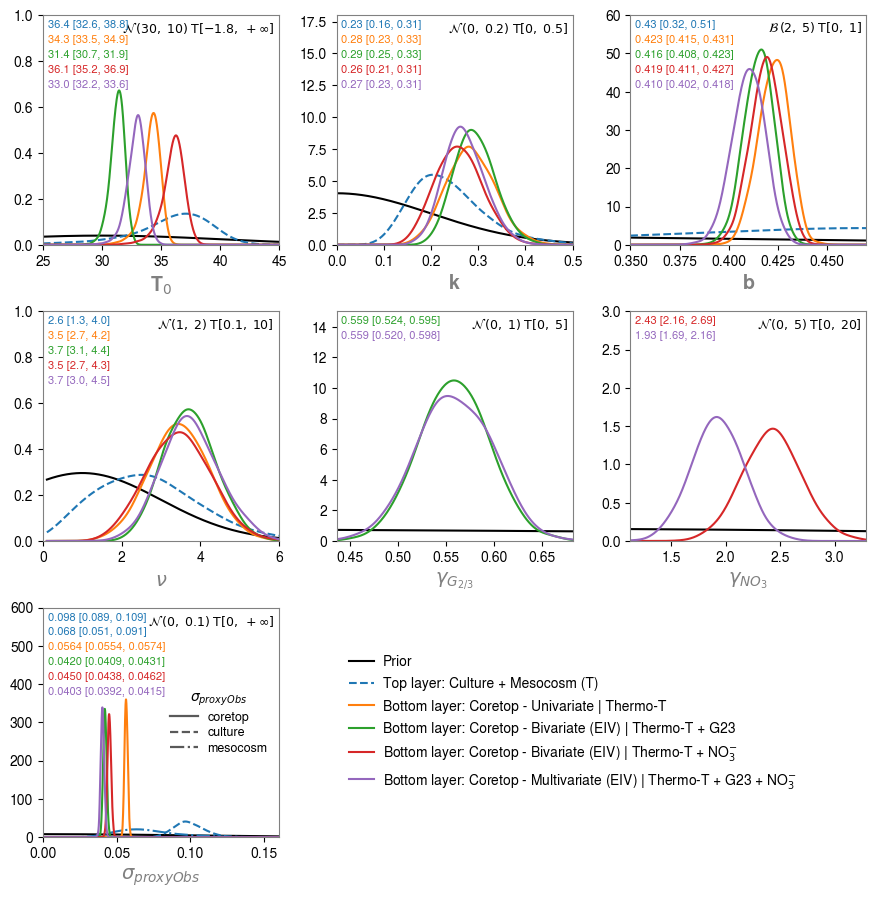

In [27]:
legend_labels = ['Top layer: Culture + Mesocosm (T)', 
                 'Bottom layer: Coretop - Univariate | Thermo-T', 
                 'Bottom layer: Coretop - Bivariate (EIV) | Thermo-T + G23', 
                 r'Bottom layer: Coretop - Bivariate (EIV) | Thermo-T + NO$_{3}^{-}$',
                 r'Bottom layer: Coretop - Multivariate (EIV) | Thermo-T + G23 + NO$_{3}^{-}$',
                 'Prior']
# ── Forward posteriors from 032326 run ────────────────────────────────────────              
post_fwd = [       
    # Stage 1 — culmeso   
    culmeso_name(),            
    # Stage 2 — thermoT / scaledRI                           
    fwd_name('thermoT', stem=UNIV_STEM),
    fwd_name('thermoT', gdgt23ratio=True),
    fwd_name('thermoT', no3_cutoff=1.0),
    fwd_name('thermoT', gdgt23ratio=True, no3_cutoff=1.0),           
]  

fig, axs = plot_prior_distributions(
    posterior_datasets=post_fwd,
    posterior_labels_list=legend_labels,
    use_linestyle_by_param=True,
    show_histogram=False,
    set_leg_max_ncol=1,
    set_fig_height_factor=3,
    show_suptitle=False,
    show_annotation=True,
    show_subplot_legend=False,
    show_figure_legend=False,
    show_prior_expression=True,
    annotation_style='ci68'
)

axs[0,0].set_xlim(25,45)
axs[0,0].set_ylim(0,1)
axs[0,1].set_xlim(0,0.5)
axs[0,1].set_ylim(0,18)
axs[0,2].set_xlim(0.35,0.47)
axs[0,2].set_ylim(0,60)
axs[1,0].set_xlim(0,6)
axs[1,0].set_ylim(0,1)

axs[2,0].set_xlim(0,0.16)
axs[2,0].set_ylim(0,600)
# axs[1,1].set_xlim(-0.01,0)
axs[1,1].set_ylim(0,15)
# axs[1,2].set_xlim(-0.07,-0.02)
axs[1,2].set_ylim(0,3)

for ax in axs.flatten():
    
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, color="gray", fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, color="gray", fontweight='bold')
    ax.spines[:].set_color("gray")
    
    
    ax.grid(False)
    ax.set_ylim(bottom=0)
    
from matplotlib.lines import Line2D as _Line2D

# The function reserves bottom space for its own legend whether or not it draws
# one (0.25 + 0.25 per row). Reclaim it -- the legend goes in the empty cells.
n_leg = len(post_fwd) + 1                      # datasets + Prior
w, h = fig.get_size_inches()
fig.set_size_inches(w, h - (0.25 + 0.25 * n_leg))
fig.subplots_adjust(bottom=0.07)

# Span the two hidden bottom-right cells. Reading their positions after the
# resize keeps this correct if the grid ever reflows, unlike a fixed anchor.
p1, p2 = axs[2, 1].get_position(), axs[2, 2].get_position()
h_, l_ = axs[0, 0].get_legend_handles_labels()
fig.legend(h_, ['Prior'] + legend_labels,
           loc='center left',
           bbox_to_anchor=(p1.x0, p1.y0, p2.x1 - p1.x0, p1.height),
           bbox_transform=fig.transFigure,
           ncol=1, fontsize=10, frameon=False,
           handlelength=1.8, handletextpad=0.6, labelspacing=0.6)

# Linestyle key for the noise panel: sorted param labels give cul, meso, crtp
# -> solid, dashed, dash-dot. Neutral handle colour, since the message here is
# the linestyle, not which dataset.
axs[2, 0].legend(handles=[_Line2D([], [], color='0.35', lw=1.6, ls=ls)
                          for ls in ['-', '--', '-.']],
                 labels=['coretop','culture', 'mesocosm',],
                 title=r'$\sigma_{proxyObs}$',
                 loc='center right', fontsize=9, title_fontsize=10,
                 frameon=False, handlelength=2.2, labelspacing=0.3)


fig.savefig(os.path.join(fpath, "posterior_check.png"), dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'AppendixC_thermoT_prior_distributions_t0shift.pdf'),dpi=300)

In [28]:
plot_culmeso_df = gridded_combined_df[gridded_combined_df['datatype'].isin(['culture','mesocosm'])].dropna(subset=['scaledRI','SST']).reset_index(drop=True)

y_params = ['scaledRI_cren3']
for y_param in y_params:
    pred_scaledRI_culmeso_results = generate_ensemble_auto(
        post_ds = load_posterior(culmeso_name(y_param)),
        x_vals = plot_culmeso_df['SST'].values,
        percentiles=[2.5,50,97.5],
    )
    plot_culmeso_df[f'pred_{y_param}'] = pred_scaledRI_culmeso_results['p50']

In [29]:
y_params = ['scaledRI_cren3']
plot_coretop_df = coretop_df
for y_param in y_params:
    pred_scaledRI_crtp_results = generate_ensemble_auto(
        post_ds = load_posterior(fwd_name('SST', y_param, gdgt23ratio=True, no3_cutoff=1.0)),
        x_vals = plot_coretop_df['SST'].values,
        gdgt23ratio = plot_coretop_df['gdgt23ratio'].values,
        no3 = plot_coretop_df['no3_sf2tc_avg'].values,
        no3_cutoff = 1.0,
        percentiles=[2.5,50,97.5],
    )
    plot_coretop_df[f'pred_{y_param}'] = pred_scaledRI_crtp_results['p50']
    plot_coretop_df[f'residual_{y_param}'] = plot_coretop_df['scaledRI'] - plot_coretop_df[f'pred_{y_param}']
    
    pred_scaledRI_crtp_results_thermoT = generate_ensemble_auto(
        post_ds = load_posterior(fwd_name('thermoT', y_param, gdgt23ratio=True, no3_cutoff=1.0)),
        x_vals = plot_coretop_df['t_sf2tc_avg'].values,
        gdgt23ratio = plot_coretop_df['gdgt23ratio'].values,
        no3 = plot_coretop_df['no3_sf2tc_avg'].values,
        no3_cutoff = 1.0,
        percentiles=[2.5,50,97.5],
    )
    plot_coretop_df[f'pred_{y_param}_thermoT'] = pred_scaledRI_crtp_results_thermoT['p50']
    plot_coretop_df[f'residual_{y_param}_thermoT'] = plot_coretop_df['scaledRI'] - plot_coretop_df[f'pred_{y_param}_thermoT']


#### Fig. 7 | Top layer of the TEXAS hierarchical model using culture and mesocosm data

0.72
t0_culmeso: median=36.3958, sd=3.7573
k_culmeso: median=0.2255, sd=0.0746
b_culmeso: median=0.4339, sd=0.1018
v_culmeso: median=2.5754, sd=1.3184
sigma_proxyObs_cul: median=0.0983, sd=0.0098
sigma_proxyObs_meso: median=0.0678, sd=0.0222


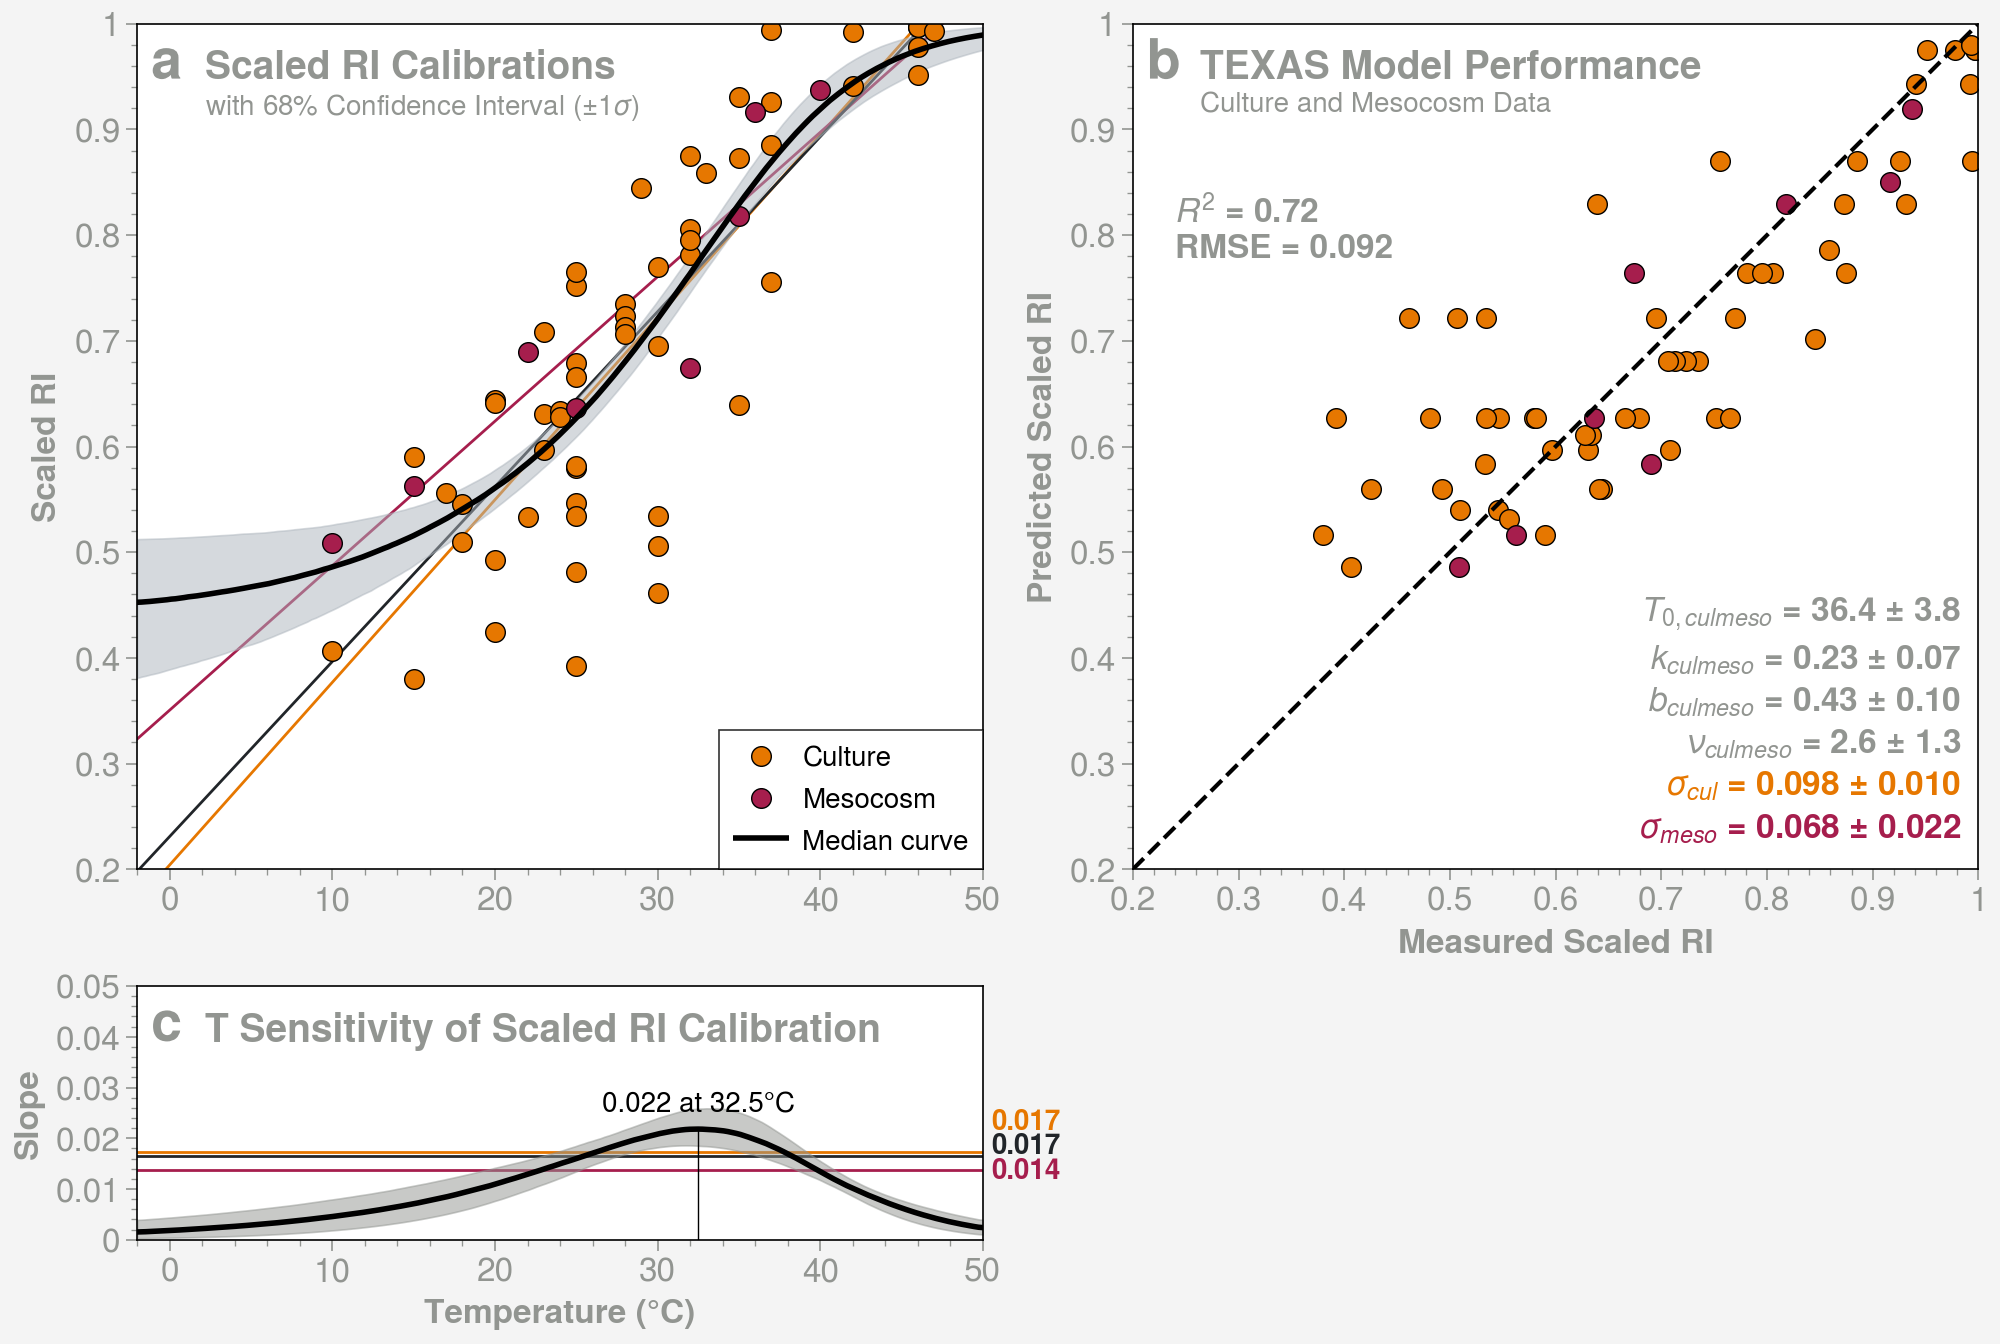

In [30]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_culmeso_df
XX = np.linspace(-2,50,200)
x_param = 'SST'
y_param = 'scaledRI_cren3'
grouped = plot_data.groupby('datatype')
for name, group in grouped:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=50,
               c=datatype_color_dict.get(name),
               m='o',mec='k',mew=0.5)
    
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=50,
               c=datatype_color_dict.get(name),
               m='o',mec='k',mew=0.5)
    
    ### linear regression line for each datatype with 95% CI shading
    from sklearn.linear_model import LinearRegression
    from sklearn.utils import resample
    
    model = LinearRegression()
    X = group[x_param].values.reshape(-1, 1)
    y = group[y_param].values
    model.fit(X, y)
    x_range = XX.reshape(-1, 1)
    y_pred = model.predict(x_range)
    axs[0,0].plot(x_range, y_pred, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    slope = model.coef_[0]
    axs[1,0].axhline(slope, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    text = f"{slope:.3f}"
    
    y_adjust = 0.006 if name=='culture' else 0
    axs[1,0].text(1.01, slope + y_adjust, 
                  text,
                  transform=axs[1,0].get_yaxis_transform(),
                  ha = 'left', verticalalignment='center',
                  fontsize=10,fontweight='bold',
                  color=datatype_color_dict.get(name))
    
    
model = LinearRegression()
X = plot_data[x_param].values.reshape(-1, 1)
y = plot_data[y_param].values
model.fit(X, y)
x_range = XX.reshape(-1, 1)
y_pred = model.predict(x_range)
axs[0,0].plot(x_range, y_pred, color='gray9', lw=1, zorder=0)

slope = model.coef_[0]
text = f"{slope:.3f}"
axs[1,0].axhline(slope, color='gray9', lw=1, zorder=0)
axs[1,0].text(1.01, slope + 0.002, text,
            transform=axs[1,0].get_yaxis_transform(),
            ha = 'left', verticalalignment='center',
            fontsize=10,fontweight='bold',
            color='gray9')

# Get all samples
gen_logi_fixed_cul_meso_post_ds = load_posterior(culmeso_name(y_param))
t0_samples = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].values.flatten()
b_samples = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].values.flatten()
k_samples = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].values.flatten()
v_samples = gen_logi_fixed_cul_meso_post_ds["v_culmeso"].values.flatten()

# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5',zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)


################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

r_squared_culmeso = r2_score(
    plot_data[y_param],
    plot_data[f'pred_{y_param}']
)

rmse_culmeso = mean_squared_error(
    plot_data[y_param],
    plot_data[f'pred_{y_param}']
)

print(_fmt_r2(r_squared_culmeso))
text = f'$R^2$ = {_fmt_r2(r_squared_culmeso)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_culmeso))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color="gray")

param_label_dict = {
    't0_culmeso': r'$T_{0,culmeso}$',
    'k_culmeso':  r'$k_{culmeso}$',
    'b_culmeso':  r'$b_{culmeso}$',
    'v_culmeso':  r'$\nu_{culmeso}$',
    'sigma_proxyObs_cul':  r'$\sigma_{cul}$',
    'sigma_proxyObs_meso': r'$\sigma_{meso}$',
}

# Explicit order, not a name filter: the noise scales are named for their data
# source (sigma_proxyObs_cul / _meso), so 'culmeso' in var_name misses both.
# Four shared curve parameters, then the two per-source residual scales.
var_list = ['t0_culmeso', 'k_culmeso', 'b_culmeso', 'v_culmeso',
            'sigma_proxyObs_cul', 'sigma_proxyObs_meso']

# Six lines at 0.05 pitch: start at 0.28 so the last clears the axis floor.
# Sigmas take their datatype colour so the reader can pair each with its points
# without a second legend; the curve parameters stay gray (they are shared).
sigma_color_dict = {'sigma_proxyObs_cul':  datatype_color_dict.get('culture'),
                    'sigma_proxyObs_meso': datatype_color_dict.get('mesocosm')}

for i, var in enumerate(var_list):
    var_samples = gen_logi_fixed_cul_meso_post_ds[var].values.flatten()
    var_median = np.median(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: median={var_median:.4f}, sd={var_sd:.4f}")
    text = f"{param_label_dict.get(var,var)} = {_format_stat(var_median,var_sd)}"
    ax.text(0.98, 0.28 - 0.05*i, text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold',
            color=sigma_color_dict.get(var, "gray"))


ax.plot([0.2,1],[0.2,1],c='k',ls='--')
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color="gray")
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color="gray")

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color="gray")

text = 'Culture and Mesocosm Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color="gray")

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color="gray")

h, l = axs[0,0].get_legend_handles_labels()

axs[0,0].legend([h[ii] for ii in [0,1,2]], ['Culture','Mesocosm','Median curve'], 
                ncol=1,
                fontsize=10, loc='lower right')


###########
plot.rc['abc']=True
axs[:3].format(grid=False,
           abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor="gray",
           fontsize=12,labelsize=12,
           labelcolor="gray",xtickcolor="gray",ytickcolor="gray",
           xticklabelcolor="gray",yticklabelcolor="gray",
           xlabelweight='bold', ylabelweight='bold', )

axs[0,0].format(ylim=(0.2,1))
axs[1,1].axis('off')
plot.rc['abc']=False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig6_scaledRI_culmeso_coretop_calibrations_t0shift.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

#### Fig. 8 | Bottom layer of the TEXAS hierarchical model incorporating secondary environmental predictors with the gridded global coretop data

t0_crtp: median=34.8 ± 0.7
k_crtp: median=0.28 ± 0.04
b_crtp: median=0.412 ± 0.008
v_crtp: median=4.0 ± 0.7
gamma_G23_crtp: median=0.63 ± 0.04
gamma_NO3_crtp: median=2.79 ± 0.24
sigma_proxyObs_crtp: median=0.0391 ± 0.0011


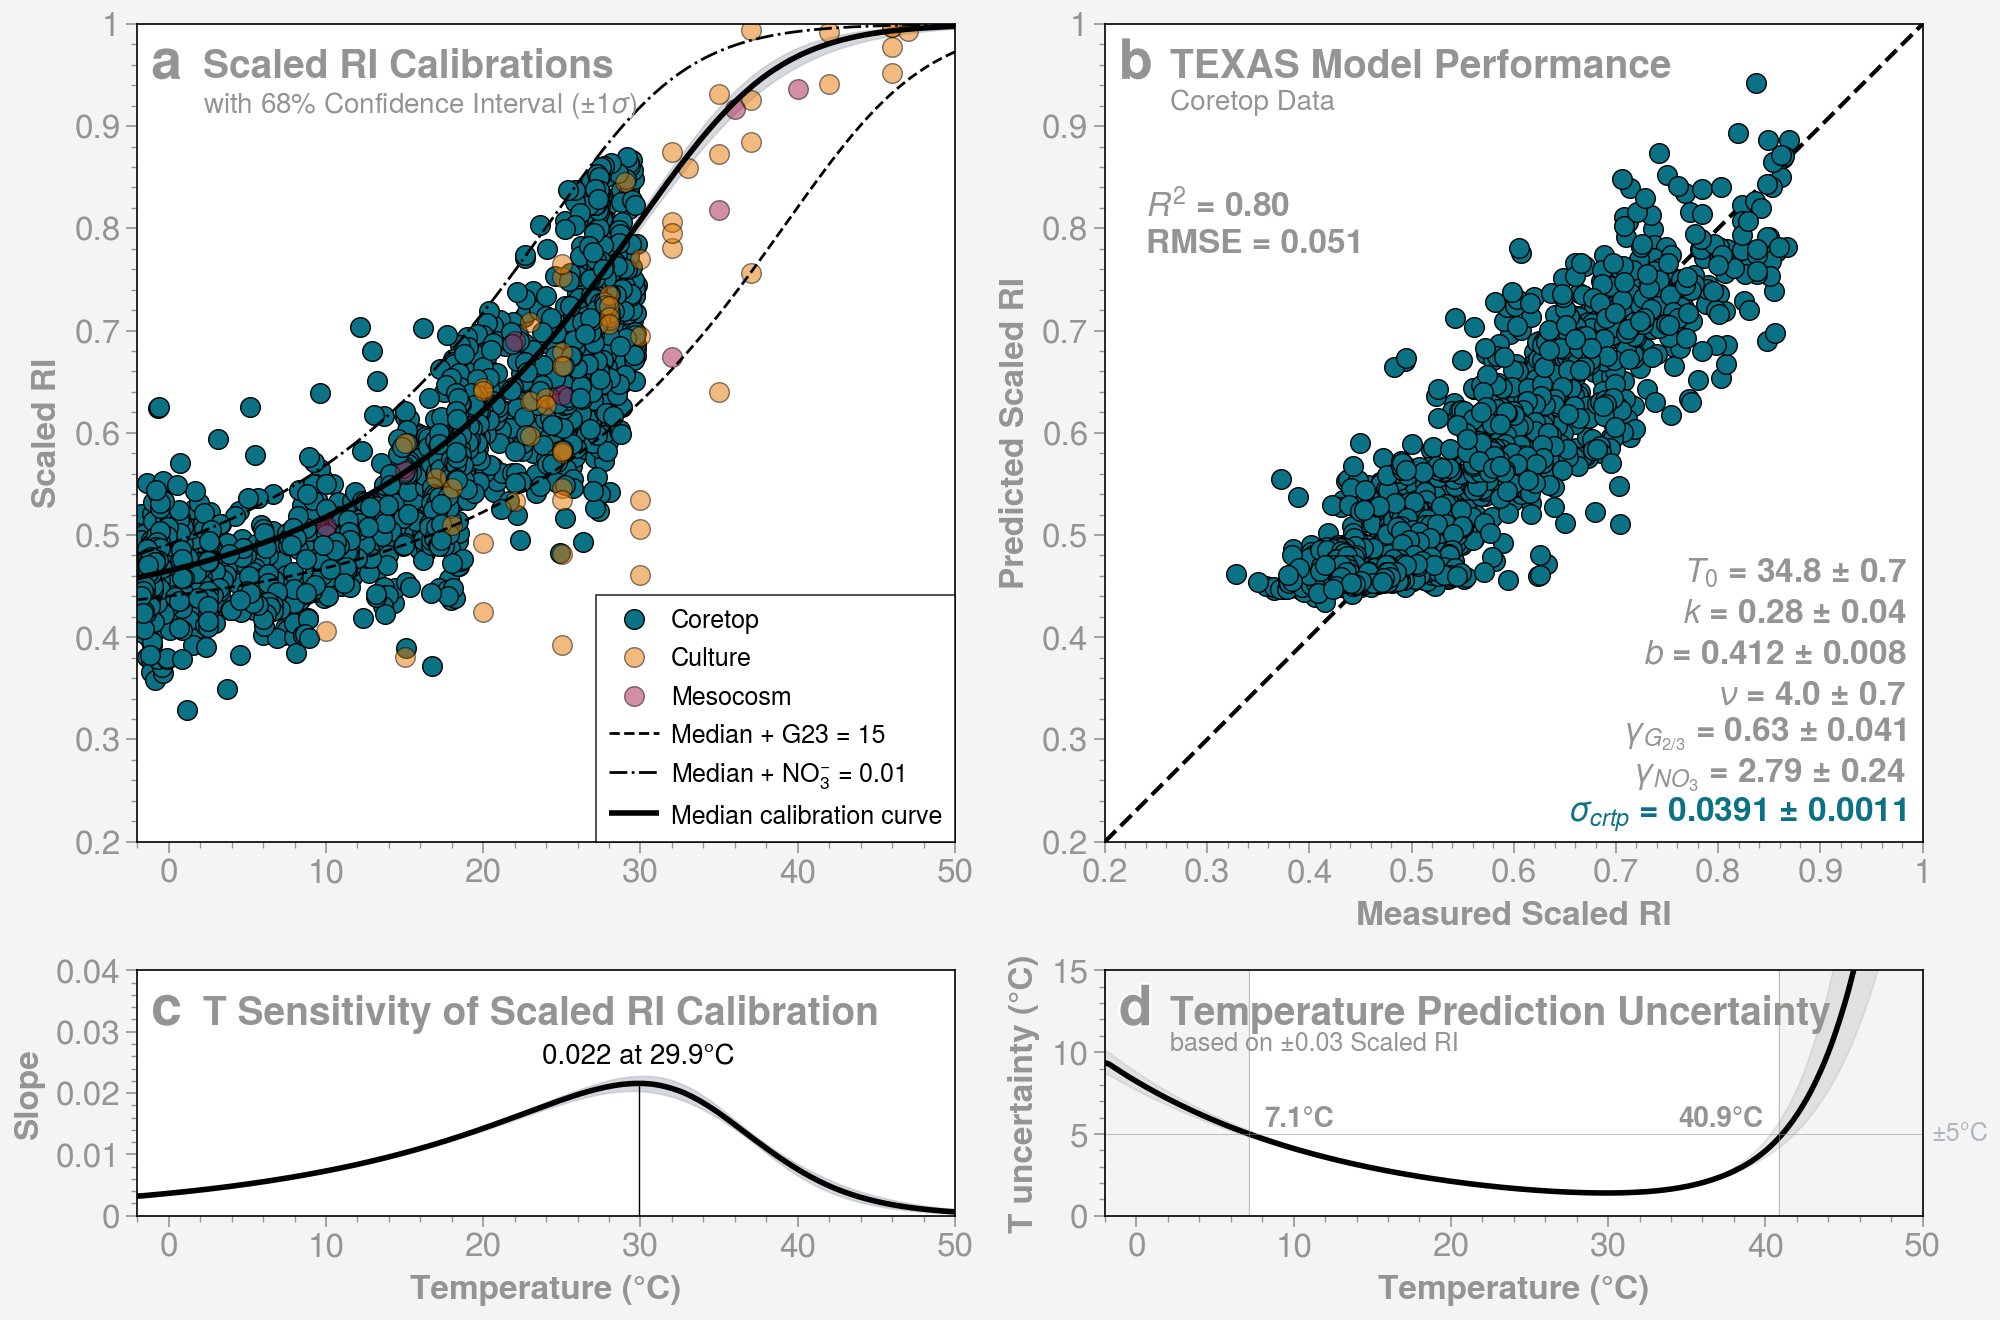

In [67]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_coretop_df
XX = np.linspace(-2,50,200)
grouped_all = gridded_combined_df.groupby('datatype')
x_param = 'SST'
x_param_fwd = 'thermoT' if x_param == 't_sf2tc_avg' else x_param
y_param = 'scaledRI_cren3'
no3_threshold = 1.0
for name, group in grouped_all:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name),
            alpha=0.5 if name!='coretop' else 1,
            label=name.capitalize())
    
grouped = plot_data.groupby('datatype')
for name, group in grouped: 
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name))
   

sel_post_ds = load_posterior(
        fwd_name(x_param_fwd, y_param, gdgt23ratio=True, no3_cutoff=no3_threshold) 
)
# Get all samples
t0_samples = sel_post_ds["t0_crtp"].values.flatten()
b_samples = sel_post_ds["b_crtp"].values.flatten()
k_samples = sel_post_ds["k_crtp"].values.flatten()
v_samples = sel_post_ds["v_crtp"].values.flatten()
gamma_gdgt23ratio_samples = sel_post_ds["gamma_G23_crtp"].values.flatten()
gamma_no3_samples = sel_post_ds["gamma_NO3_crtp"].values.flatten()
# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

### median curve corrected for median beta_gdgt23ratio and beta_no3 values
median_gamma_gdgt23ratio = np.median(gamma_gdgt23ratio_samples)
median_gamma_no3 = np.median(gamma_no3_samples)

# BOUNDED-T CORRECTION -- NOT the parent's additive form.
#
# The parent adds beta * predictor to the RESPONSE, outside the logistic, so a
# corrected curve is `curve + beta * x`. T0-shift adds gamma * x to the
# INFLECTION POINT, inside it:
#     t0_eff = t0 + gamma_G23 * g23 + gamma_NO3 * log10(no3)
#     mu     = b + (1 - b) / (1 + exp(-k (T - t0_eff)))^(1/v)
# so the curve is recomputed at the shifted T0, not shifted vertically. The
# sign convention differs too: gamma is positive where the parent's beta is
# negative, because gamma reads as "this sample behaves like water that is
# gamma * x degC colder".
median_curve_23_corrected = generalized_logistic_model_fixed_upper(
    XX, x0=np.median(t0_samples) + median_gamma_gdgt23ratio * 15,
    b=np.median(b_samples), k=np.median(k_samples), v=np.median(v_samples))
median_curve_no3_corrected = generalized_logistic_model_fixed_upper(
    XX, x0=np.median(t0_samples) + median_gamma_no3 * np.log10(0.01),
    b=np.median(b_samples), k=np.median(k_samples), v=np.median(v_samples))

axs[0,0].plot(XX, median_curve_23_corrected, 'k--', lw=1, label='Median + G23 = 15', zorder=1)
axs[0,0].plot(XX, median_curve_no3_corrected, 'k-.', lw=1, label=r'Median + NO$_{3}^{-}$ = 0.01', zorder=1)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5', zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median calibration curve', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)

################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

nonnan_idx = ~plot_data[y_param].isna() & ~plot_data[f'pred_{y_param}'].isna()
r_squared_crtp = r2_score(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)

rmse_crtp = mean_squared_error(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)
text = f'$R^2$ = {_fmt_r2(r_squared_crtp)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_crtp))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color="gray")

param_label_dict = {
    't0_crtp': r'$T_{0}$',
    'k_crtp': r'$k$',
    'b_crtp': r'$b$',
    'v_crtp': r'$\nu$',
    'gamma_G23_crtp': r'$\gamma_{G_{2/3}}$',
    'gamma_NO3_crtp': r'$\gamma_{NO_{3}}$',
    'sigma_proxyObs_crtp': r'$\sigma_{crtp}$',
}
### Posterior sec
var_list = ['t0_crtp', 'k_crtp', 'b_crtp', 'v_crtp',
            'gamma_G23_crtp', 'gamma_NO3_crtp', 'sigma_proxyObs_crtp']
for var in var_list:
    var_samples = sel_post_ds[var].values.flatten()
    var_median = np.median(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: median={_format_stat(var_median,var_sd)}")
    fmtted_text = _format_stat(var_median,var_sd,fmt='.2g') if var == 'gamma_G23_crtp' else _format_stat(var_median,var_sd)
    text = f"{param_label_dict.get(var,var)} = {fmtted_text}"
    ax.text(0.98, 0.31 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold',
            color=datatype_color_dict.get('coretop') if var == 'sigma_proxyObs_crtp' else "gray")

ax.plot([0.2,1],[0.2,1],c='k',ls='--',zorder=0)
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color="gray")
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color="gray")

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color="gray")

text = 'Coretop Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color="gray")

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color="gray")


h, l = axs[0,0].get_legend_handles_labels()

axs[0,0].legend(
        h,l,
        ncol=1,
        fontsize=9, loc='lower right')

################################################################
# Panel (d): Inverse uncertainty
################################################################
ax = axs[1,1]
ax.axis('on')  # Turn axis back on

# Calculate inverse derivatives for all posterior samples
all_inv_slopes = 1 / all_slopes  # dT/dRI = 1/(dRI/dT)

# Propagate RI measurement uncertainty to temperature uncertainty
sigma_RI = 0.03  # Assumed RI analytical uncertainty to be similar to TEX86
all_T_uncertainty = sigma_RI * np.abs(all_inv_slopes)

# Calculate median and CI
median_T_uncertainty = np.median(all_T_uncertainty, axis=0)
ci_low = np.percentile(all_T_uncertainty, 16, axis=0)
ci_high = np.percentile(all_T_uncertainty, 84, axis=0)

# Plot uncertainty vs temperature
ax.fill_between(XX, ci_low, ci_high, alpha=0.2, color='gray')
ax.plot(XX, median_T_uncertainty, c='k', lw=2, label='Median uncertainty')

# Add reference lines
# ax.axhline(3, ls='-', color="gray", lw=0.2)
ax.axhline(5, ls='-', color="gray", lw=0.2)

# Add text labels for reference lines
ax.text(1.01, 5, '±5°C', transform=ax.get_yaxis_transform(),
        ha='left', va='center', fontsize=9, color='gray5')

# Find where uncertainty crosses 5°C threshold
threshold = 5.0
# Find crossings (where curve goes above/below threshold)
above_threshold = median_T_uncertainty > threshold
# Find indices where it transitions
crossings = np.where(np.diff(above_threshold.astype(int)))[0]

if len(crossings) >= 2:
    # Low temperature crossing (left side)
    low_T_idx = crossings[0]
    low_T_cross = XX[low_T_idx]
    low_T_unc = median_T_uncertainty[low_T_idx]
    
    # High temperature crossing (right side)  
    high_T_idx = crossings[-1]
    high_T_cross = XX[high_T_idx]
    high_T_unc = median_T_uncertainty[high_T_idx]
    
    # Draw vertical lines at crossings
    
    ax.axvline(low_T_cross, color="gray", ls='-', lw=0.2)
    ax.axvline(high_T_cross, color="gray", ls='-', lw=0.2)

    
    # Optional: shade regions with >5°C uncertainty
    ax.axvspan(XX[0], low_T_cross, alpha=0.1, color='gray', zorder=0)
    ax.axvspan(high_T_cross, XX[-1], alpha=0.1, color='gray', zorder=0)

# Format
ax.format(
    xlim=(-2, 50),
    ylim=(0, 15),  # Adjust based on your data
    xlabel='Temperature (°C)',
    ylabel='T uncertainty (°C)',
)

# Add title
text = 'Temperature Prediction Uncertainty'
ax.text(0.08, 0.9, text, transform=ax.transAxes,
        fontsize=14, va='top', ha = 'left',
        fontweight='bold', color="gray")

# Add note about sigma_RI assumption and precision window
text = f'based on ±{sigma_RI:.2f} Scaled RI'
ax.text(0.08, 0.65, text, transform=ax.transAxes,
        fontsize=9, ha='left', va='bottom', color="gray")

# text = f'{low_T_cross:.1f}–{high_T_cross:.1f}°C'

if len(crossings) >= 2:
    text = f'{low_T_cross:.1f}°C'
    ax.text(low_T_cross+1, 5.1, text, 
            ha='left', va='bottom', fontsize=10, 
            fontweight='bold', color="gray")
    text = f'{high_T_cross:.1f}°C'
    ax.text(high_T_cross-1, 5.1, text, 
            ha='right', va='bottom', fontsize=10,
            fontweight='bold', color="gray")


###########
# Update this line (around line where you currently format axs[:3])
axs.format(grid=False,
           abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor="gray",
           fontsize=12, labelsize=12,
           labelcolor="gray", xtickcolor="gray", ytickcolor="gray",
           xticklabelcolor="gray", yticklabelcolor="gray",
           xlabelweight='bold', ylabelweight='bold')
axs[0,0].format(ylim=(0.2,1))
axs[1,0].format(ylim=(0,0.04))

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig7_{x_param}_{y_param}_coretop_calibrations_t0shift.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

t0_crtp: median=33.0 ± 0.8
k_crtp: median=0.27 ± 0.04
b_crtp: median=0.410 ± 0.008
v_crtp: median=3.7 ± 0.7
gamma_G23_crtp: median=0.559 ± 0.039
gamma_NO3_crtp: median=1.93 ± 0.24
sigma_proxyObs_crtp: median=0.0403 ± 0.0012


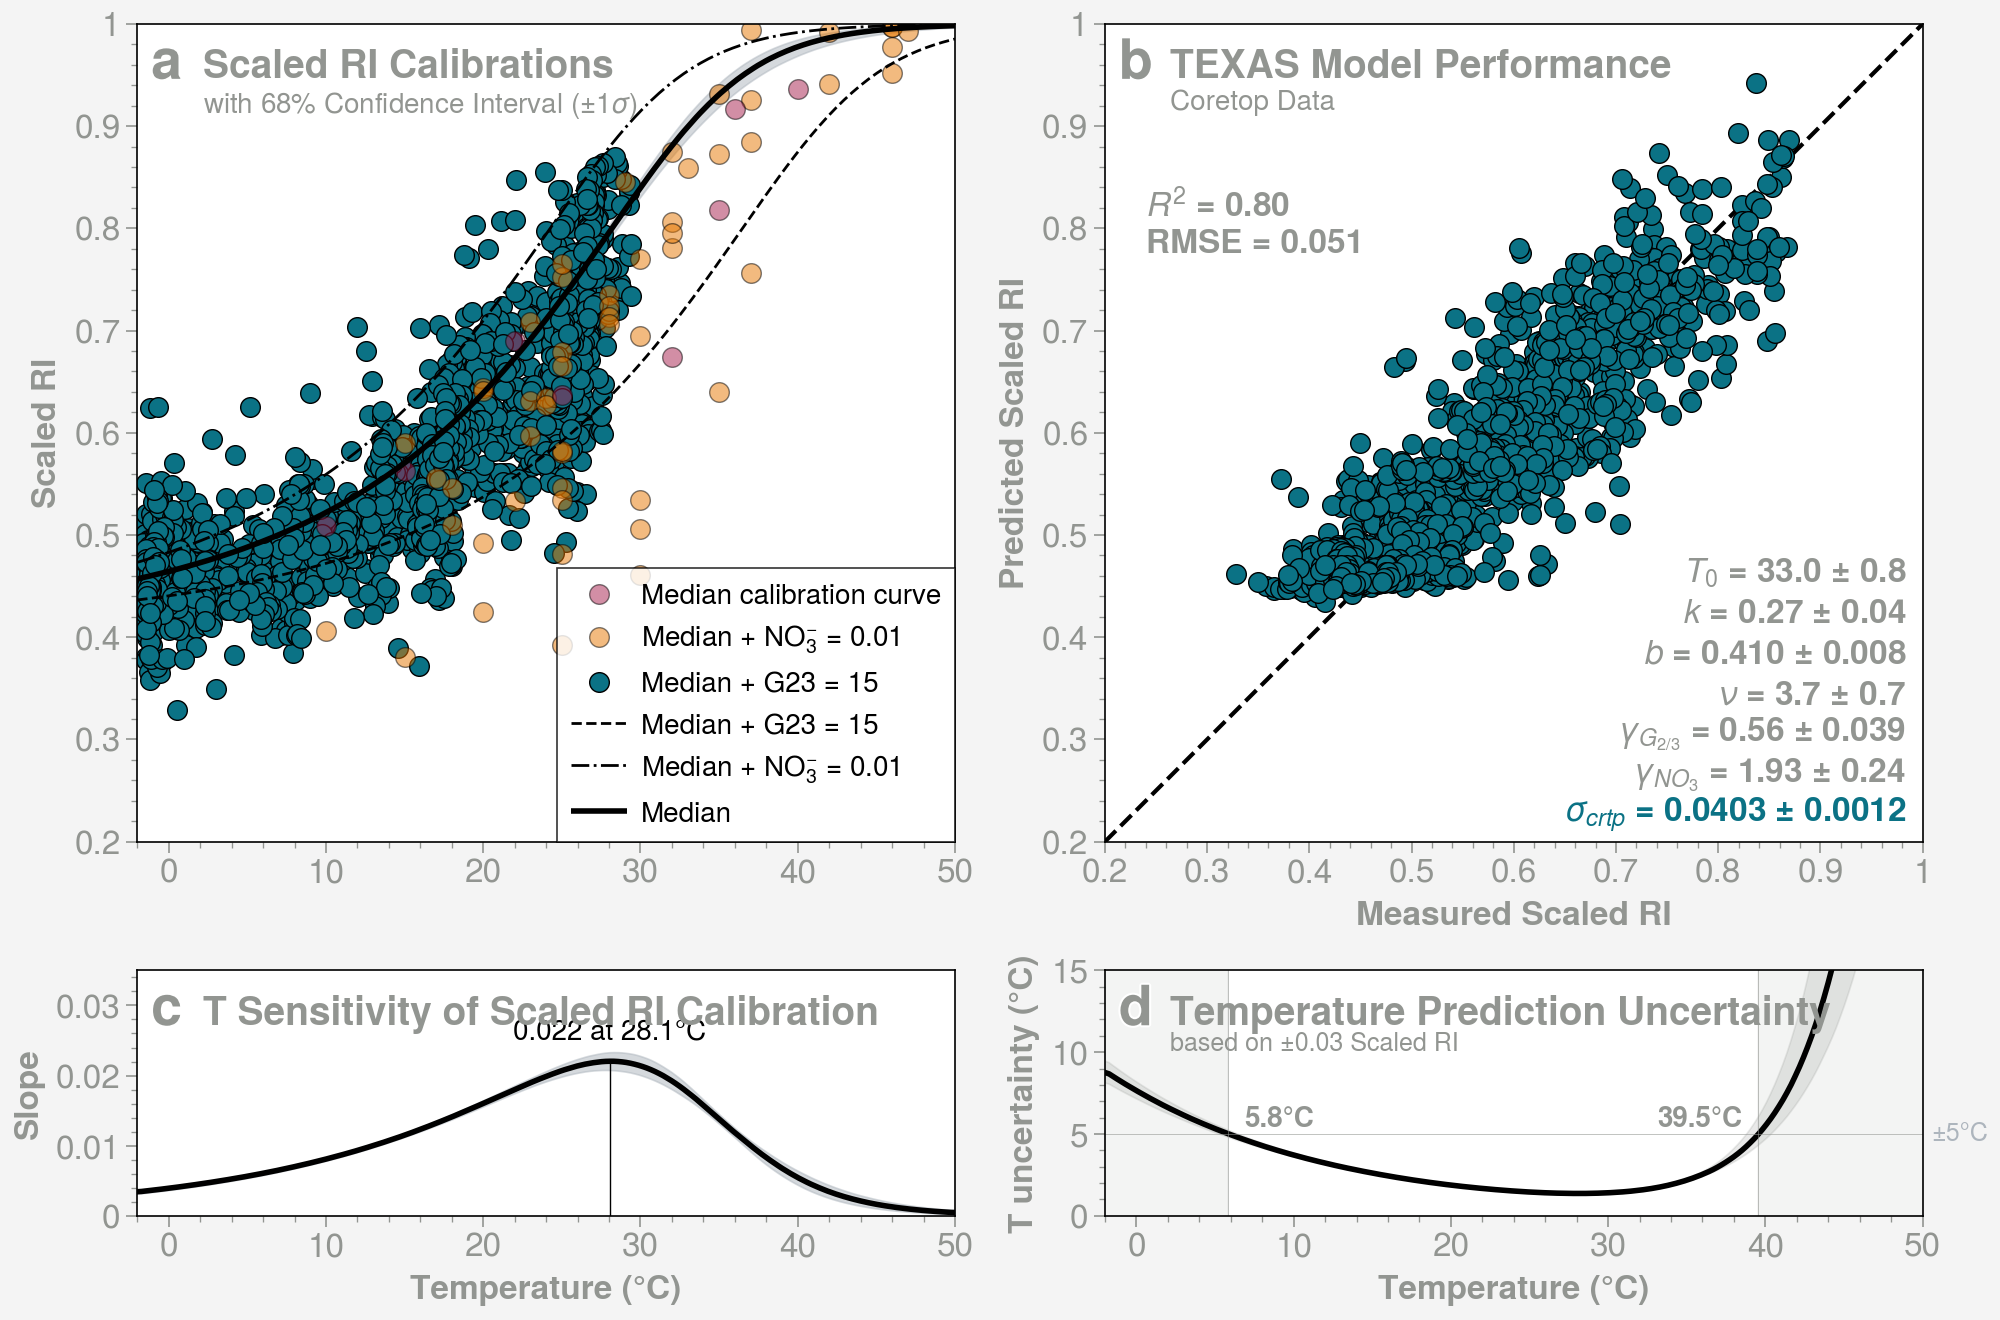

In [68]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_coretop_df
XX = np.linspace(-2,50,200)
grouped_all = gridded_combined_df.groupby('datatype')
x_param = 't_sf2tc_avg'
x_param_fwd = 'thermoT' if x_param == 't_sf2tc_avg' else x_param
y_param = 'scaledRI_cren3'
no3_threshold = 1.0
for name, group in grouped_all:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name),
            alpha=0.5 if name!='coretop' else 1,
            label=name.capitalize())
    
grouped = plot_data.groupby('datatype')
for name, group in grouped: 
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name))
   

sel_post_ds = load_posterior(
        fwd_name(x_param_fwd, y_param, gdgt23ratio=True, no3_cutoff=no3_threshold) 
)
# Get all samples
t0_samples = sel_post_ds["t0_crtp"].values.flatten()
b_samples = sel_post_ds["b_crtp"].values.flatten()
k_samples = sel_post_ds["k_crtp"].values.flatten()
v_samples = sel_post_ds["v_crtp"].values.flatten()
gamma_gdgt23ratio_samples = sel_post_ds["gamma_G23_crtp"].values.flatten()
gamma_no3_samples = sel_post_ds["gamma_NO3_crtp"].values.flatten()
# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

### median curve corrected for median beta_gdgt23ratio and beta_no3 values
median_gamma_gdgt23ratio = np.median(gamma_gdgt23ratio_samples)
median_gamma_no3 = np.median(gamma_no3_samples)

# BOUNDED-T CORRECTION -- NOT the parent's additive form.
#
# The parent adds beta * predictor to the RESPONSE, outside the logistic, so a
# corrected curve is `curve + beta * x`. T0-shift adds gamma * x to the
# INFLECTION POINT, inside it:
#     t0_eff = t0 + gamma_G23 * g23 + gamma_NO3 * log10(no3)
#     mu     = b + (1 - b) / (1 + exp(-k (T - t0_eff)))^(1/v)
# so the curve is recomputed at the shifted T0, not shifted vertically. The
# sign convention differs too: gamma is positive where the parent's beta is
# negative, because gamma reads as "this sample behaves like water that is
# gamma * x degC colder".
median_curve_23_corrected = generalized_logistic_model_fixed_upper(
    XX, x0=np.median(t0_samples) + median_gamma_gdgt23ratio * 15,
    b=np.median(b_samples), k=np.median(k_samples), v=np.median(v_samples))
median_curve_no3_corrected = generalized_logistic_model_fixed_upper(
    XX, x0=np.median(t0_samples) + median_gamma_no3 * np.log10(0.01),
    b=np.median(b_samples), k=np.median(k_samples), v=np.median(v_samples))

axs[0,0].plot(XX, median_curve_23_corrected, 'k--', lw=1, label='Median + G23 = 15', zorder=1)
axs[0,0].plot(XX, median_curve_no3_corrected, 'k-.', lw=1, label=r'Median + NO$_{3}^{-}$ = 0.01', zorder=1)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5', zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)

################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

nonnan_idx = ~plot_data[y_param].isna() & ~plot_data[f'pred_{y_param}'].isna()
r_squared_crtp = r2_score(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)

rmse_crtp = mean_squared_error(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)
text = f'$R^2$ = {_fmt_r2(r_squared_crtp)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_crtp))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color="gray")

param_label_dict = {
    't0_crtp': r'$T_{0}$',
    'k_crtp': r'$k$',
    'b_crtp': r'$b$',
    'v_crtp': r'$\nu$',
    'gamma_G23_crtp': r'$\gamma_{G_{2/3}}$',
    'gamma_NO3_crtp': r'$\gamma_{NO_{3}}$',
    'sigma_proxyObs_crtp': r'$\sigma_{crtp}$',
}
### Posterior sec
var_list = ['t0_crtp', 'k_crtp', 'b_crtp', 'v_crtp',
            'gamma_G23_crtp', 'gamma_NO3_crtp', 'sigma_proxyObs_crtp']
for var in var_list:
    var_samples = sel_post_ds[var].values.flatten()
    var_median = np.median(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: median={_format_stat(var_median,var_sd)}")
    fmtted_text = _format_stat(var_median,var_sd,fmt='.2g') if var == 'gamma_G23_crtp' else _format_stat(var_median,var_sd)
    text = f"{param_label_dict.get(var,var)} = {fmtted_text}"
    ax.text(0.98, 0.31 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold',
            color=datatype_color_dict.get('coretop') if var == 'sigma_proxyObs_crtp' else "gray")

ax.plot([0.2,1],[0.2,1],c='k',ls='--',zorder=0)
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color="gray")
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color="gray")

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color="gray")

text = 'Coretop Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color="gray")

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color="gray")


h, l = axs[0,0].get_legend_handles_labels()

axs[0,0].legend(h[0:3][::-1]+h[3:],
                ['Median calibration curve','Median + NO$_{3}^{-}$ = 0.01','Median + G23 = 15',]+l[3:], 
                ncol=1,
                fontsize=10, loc='lower right')

################################################################
# Panel (d): Inverse uncertainty
################################################################
ax = axs[1,1]
ax.axis('on')  # Turn axis back on

# Calculate inverse derivatives for all posterior samples
all_inv_slopes = 1 / all_slopes  # dT/dRI = 1/(dRI/dT)

# Propagate RI measurement uncertainty to temperature uncertainty
sigma_RI = 0.03  # Assumed RI analytical uncertainty to be similar to TEX86
all_T_uncertainty = sigma_RI * np.abs(all_inv_slopes)

# Calculate median and CI
median_T_uncertainty = np.median(all_T_uncertainty, axis=0)
ci_low = np.percentile(all_T_uncertainty, 16, axis=0)
ci_high = np.percentile(all_T_uncertainty, 84, axis=0)

# Plot uncertainty vs temperature
ax.fill_between(XX, ci_low, ci_high, alpha=0.2, color='gray')
ax.plot(XX, median_T_uncertainty, c='k', lw=2, label='Median uncertainty')

# Add reference lines
# ax.axhline(3, ls='-', color="gray", lw=0.2)
ax.axhline(5, ls='-', color="gray", lw=0.2)

# Add text labels for reference lines
ax.text(1.01, 5, '±5°C', transform=ax.get_yaxis_transform(),
        ha='left', va='center', fontsize=9, color='gray5')

# Find where uncertainty crosses 5°C threshold
threshold = 5.0
# Find crossings (where curve goes above/below threshold)
above_threshold = median_T_uncertainty > threshold
# Find indices where it transitions
crossings = np.where(np.diff(above_threshold.astype(int)))[0]

if len(crossings) >= 2:
    # Low temperature crossing (left side)
    low_T_idx = crossings[0]
    low_T_cross = XX[low_T_idx]
    low_T_unc = median_T_uncertainty[low_T_idx]
    
    # High temperature crossing (right side)  
    high_T_idx = crossings[-1]
    high_T_cross = XX[high_T_idx]
    high_T_unc = median_T_uncertainty[high_T_idx]
    
    # Draw vertical lines at crossings
    
    ax.axvline(low_T_cross, color="gray", ls='-', lw=0.2)
    ax.axvline(high_T_cross, color="gray", ls='-', lw=0.2)

    
    # Optional: shade regions with >5°C uncertainty
    ax.axvspan(XX[0], low_T_cross, alpha=0.1, color='gray', zorder=0)
    ax.axvspan(high_T_cross, XX[-1], alpha=0.1, color='gray', zorder=0)

# Format
ax.format(
    xlim=(-2, 50),
    ylim=(0, 15),  # Adjust based on your data
    xlabel='Temperature (°C)',
    ylabel='T uncertainty (°C)',
)

# Add title
text = 'Temperature Prediction Uncertainty'
ax.text(0.08, 0.9, text, transform=ax.transAxes,
        fontsize=14, va='top', ha = 'left',
        fontweight='bold', color="gray")

# Add note about sigma_RI assumption and precision window
text = f'based on ±{sigma_RI:.2f} Scaled RI'
ax.text(0.08, 0.65, text, transform=ax.transAxes,
        fontsize=9, ha='left', va='bottom', color="gray")

# text = f'{low_T_cross:.1f}–{high_T_cross:.1f}°C'

if len(crossings) >= 2:
    text = f'{low_T_cross:.1f}°C'
    ax.text(low_T_cross+1, 5.1, text, 
            ha='left', va='bottom', fontsize=10, 
            fontweight='bold', color="gray")
    text = f'{high_T_cross:.1f}°C'
    ax.text(high_T_cross-1, 5.1, text, 
            ha='right', va='bottom', fontsize=10,
            fontweight='bold', color="gray")


###########
# Update this line (around line where you currently format axs[:3])
axs.format(grid=False,
           abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor="gray",
           fontsize=12, labelsize=12,
           labelcolor="gray", xtickcolor="gray", ytickcolor="gray",
           xticklabelcolor="gray", yticklabelcolor="gray",
           xlabelweight='bold', ylabelweight='bold')
axs[0,0].format(ylim=(0.2,1))
axs[1,0].format(ylim=(0,0.035))

# fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
# fname = f'figSxx_{x_param}_{y_param}_coretop_calibrations.pdf'
# fig.savefig(os.path.join(fpath, fname),dpi=300)

In [33]:
# url = 'https://www.ncei.noaa.gov/pub/data/paleo/contributions_by_author/tierney2015/tierney2015tex86.txt'
# TT15_coretop_df = pd.read_csv(
#     url,
#     sep='\t',
#     comment='#',
#     na_values='-999'
# )
# TT15_coretop_df = TT15_coretop_df.dropna(subset=['tex86','WOA09_SST']).reset_index(drop=True)
# TT15_coretop_df['binned_tex86'] = pd.cut(TT15_coretop_df['tex86'], bins=np.arange(0,1.05,0.05), right=False)


# methods = ['schouten02','kim2010_tex86H','OBrien17']
# for method in methods:
#     TT15_coretop_df[f'predSST_{method}'] = predictSSTfromTEX(
#         input_tex=TT15_coretop_df['tex86'],
#         method_name=method
#     )
    
#     TT15_coretop_df[f'Tres_{method}'] = TT15_coretop_df['WOA09_SST'] - TT15_coretop_df[f'predSST_{method}']
    
# ### predict T from TEX86 with BAYSPAR
# TT15_coretop_df['predSST_bayspar_mean'] = np.nan
# for i in tqdm(range(len(TT15_coretop_df))):
#     try:
#         TT15_coretop_df.loc[i,'predSST_bayspar_mean'] = bsr.predict_seatemp(TT15_coretop_df['tex86'].iloc[i].reshape(1),
#                lon=TT15_coretop_df['longitude'].iloc[i].reshape(1),
#                lat=TT15_coretop_df['latitude'].iloc[i].reshape(1),
#                prior_std=6,temptype='sst').percentile(50)[0]
        
#         TT15_coretop_df.loc[i,'Tres_bayspar'] = TT15_coretop_df['WOA09_SST'].iloc[i] - TT15_coretop_df.loc[i,'predSST_bayspar_mean']
#     except:
#         continue
    
# ### save for reuse
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'TT15_coretop_data.pkl'
# TT15_coretop_df.to_pickle(os.path.join(fpath,fname))

### reload
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'TT15_coretop_data.pkl'
TT15_coretop_df = pd.read_pickle(os.path.join(fpath,fname))

# ── BAYSPAR predictions for the TT15 coretop set ────────────────────────────
# The pickle ships `predSST_bayspar_mean` as an ALL-NaN placeholder (0 of 1095
# filled) and no `Tres_bayspar` column at all, which is what made the binned
# residual cell below raise KeyError: "Columns not found: 'Tres_bayspar'".
#
# The loop meant to fill it is preserved above, commented out — and it could
# never have worked here: baysparpy's get_close_obs() does `float(lat)`, and
# numpy 2.0 removed float() on a 1-element array, so every one of the 1095
# iterations raised. The loop's bare `except: continue` swallowed all of them,
# which is why the column is silently empty instead of loudly broken. Same
# family of breakage as the bayspar_percentile() shim further down.
#
# Fixed by passing lat/lon as scalars. Failures are counted and reported rather
# than swallowed: a genuine "no analogs here" is worth knowing about, and so is
# a second numpy incompatibility.
if TT15_coretop_df["predSST_bayspar_mean"].notna().sum() == 0:
    print(f"filling predSST_bayspar_mean for {len(TT15_coretop_df)} rows "
          f"(~2 min) ...")
    _pred = np.full(len(TT15_coretop_df), np.nan)
    _failed = []
    for _i in tqdm(range(len(TT15_coretop_df))):
        try:
            _p = bsr.predict_seatemp(
                np.asarray(TT15_coretop_df["tex86"].iloc[_i]).reshape(1),
                lon=float(TT15_coretop_df["longitude"].iloc[_i]),
                lat=float(TT15_coretop_df["latitude"].iloc[_i]),
                prior_std=6, temptype="sst")
            _pred[_i] = float(np.percentile(_p.ensemble, 50))
        except Exception as _e:
            _failed.append((_i, type(_e).__name__))
    TT15_coretop_df["predSST_bayspar_mean"] = _pred
    if _failed:
        from collections import Counter
        print(f"  {len(_failed)} row(s) returned no prediction: "
              f"{Counter(k for _, k in _failed).most_common()}")

# Same convention as the three analytical methods — verified against the pickle,
# where Tres_<m> == WOA09_SST - predSST_<m> holds exactly for all three.
TT15_coretop_df["Tres_bayspar"] = (TT15_coretop_df["WOA09_SST"]
                                   - TT15_coretop_df["predSST_bayspar_mean"])
print(f"Tres_bayspar: {TT15_coretop_df['Tres_bayspar'].notna().sum()} / "
      f"{len(TT15_coretop_df)} non-null")
TT15_coretop_df


filling predSST_bayspar_mean for 1095 rows (~2 min) ...


100%|██████████| 1095/1095 [01:07<00:00, 16.28it/s]

  7 row(s) returned no prediction: [('LinAlgError', 7)]
Tres_bayspar: 1088 / 1095 non-null


,core_name,core_type,sample_depth_start,sample_depth_end,longitude,latitude,depth,tex86,WOA09_SST,OISST_SST,...,Unnamed: 19,binned_tex86,predSST_schouten02,Tres_schouten02,predSST_kim2010_tex86H,Tres_kim2010_tex86H,predSST_OBrien17,Tres_OBrien17,predSST_bayspar_mean,Tres_bayspar
0,GeoB7702-3,GC,5.0,6.0,34.073300,31.651700,562.0,0.662,22.0,22.5,...,NaN,"[0.65, 0.7)",25.466655,-3.466655,26.346686,-4.346686,27.764657,-5.764657,24.524917,-2.524917
1,KNR195-5-17 MC42,MC,0.0,1.0,-89.685500,-1.253000,615.0,0.563,23.1,23.8,...,NaN,"[0.55, 0.6)",18.866652,4.233348,21.534774,1.565226,21.941130,1.158870,22.429900,0.670100
2,KNR195-5-9 MC22,MC,0.0,1.0,-81.250000,-3.850300,689.0,0.567,22.2,22.3,...,NaN,"[0.55, 0.6)",19.133319,3.066681,21.745081,0.454919,22.176424,0.023575,22.322188,-0.122188
3,KNR195-5-15 MC38,MC,0.0,1.0,-89.699300,-1.265700,597.0,0.567,23.1,23.8,...,NaN,"[0.55, 0.6)",19.133319,3.966681,21.745081,1.354919,22.176424,0.923576,22.793210,0.306790
4,KNR195-5-8 MC18,MC,0.0,1.0,-81.310000,-3.986700,1020.0,0.568,22.2,22.3,...,NaN,"[0.55, 0.6)",19.199986,3.000014,21.797426,0.402574,22.235248,-0.035248,22.283444,-0.083444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,64PE301 P1500,MC,0.0,0.5,63.075000,22.078333,1495.0,0.730,26.6,26.7,...,NaN,"[0.7, 0.75)",29.999991,-3.399991,29.251284,-2.651284,31.764655,-5.164655,26.221153,0.378847
1091,64PE301 P1800,MC,0.0,0.5,63.408333,22.308333,1786.0,0.730,26.6,26.8,...,NaN,"[0.7, 0.75)",29.999991,-3.399991,29.251284,-2.651284,31.764655,-5.164655,26.235789,0.364211
1092,64PE301 P2000,MC,0.0,0.5,63.018611,22.144722,1970.0,0.720,26.6,26.7,...,NaN,"[0.7, 0.75)",29.333324,-2.733324,28.841543,-2.241543,31.176420,-4.576420,25.803338,0.796662
1093,64PE301 P2500,MC,0.0,0.5,62.895000,22.104722,2470.0,0.720,26.6,26.7,...,NaN,"[0.7, 0.75)",29.333324,-2.733324,28.841543,-2.241543,31.176420,-4.576420,25.856893,0.743107


In [34]:
methods = ['schouten02','kim2010_tex86H']
features = ['tex86','WOA09_SST']
temp_features = ['predSST_bayspar_mean'] + [f'predSST_{method}' for method in methods] 
predicted_SST_df = TT15_coretop_df[TT15_coretop_df['latitude']<70].copy()
predicted_SST_df['t_est_range'] = predicted_SST_df[temp_features].max(axis=1) - predicted_SST_df[temp_features].min(axis=1)
predicted_SST_df = predicted_SST_df.sort_values(by='tex86').reset_index(drop=True)
predicted_SST_df['binned_tex86'] = pd.cut(predicted_SST_df['tex86'], bins=np.arange(0,1.05,0.1), right=False)
predicted_SST_df

,core_name,core_type,sample_depth_start,sample_depth_end,longitude,latitude,depth,tex86,WOA09_SST,OISST_SST,...,binned_tex86,predSST_schouten02,Tres_schouten02,predSST_kim2010_tex86H,Tres_kim2010_tex86H,predSST_OBrien17,Tres_OBrien17,predSST_bayspar_mean,Tres_bayspar,t_est_range
0,PS69/853-2,MC,0.0,1.0,69.2178,-65.9980,2365.0,0.204,0.2,-1.3,...,"[0.2, 0.3)",-5.066693,5.266693,-8.621297,8.821297,0.823494,-0.623494,-6.075826,6.275826,3.554603
1,PS69/878-4,GBC,0.0,1.0,82.6562,-65.3425,3093.0,0.268,-1.0,-1.5,...,"[0.2, 0.3)",-0.800024,-0.199976,-0.515580,-0.484420,4.588198,-5.588198,-2.737376,1.737376,2.221796
2,B49,grab,0.0,1.0,-166.2500,63.3000,NaN,0.271,3.4,2.6,...,"[0.2, 0.3)",-0.600024,4.000024,-0.184901,3.584901,4.764669,-1.364669,-1.895972,5.295972,1.711072
3,B42,grab,0.0,1.0,-166.7500,62.9500,NaN,0.286,8.2,2.7,...,"[0.2, 0.3)",0.399976,7.800024,1.415437,6.784563,5.647021,2.552979,-0.989580,9.189580,2.405017
4,B47,grab,0.0,1.0,-167.0000,63.6000,NaN,0.289,2.5,2.2,...,"[0.2, 0.3)",0.599976,1.900024,1.725412,0.774588,5.823491,-3.323491,-0.737138,3.237138,2.462551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,RS41-MC101,MC,5.0,6.0,38.4230,20.1050,2309.0,0.866,28.6,28.5,...,"[0.8, 0.9)",39.066662,-10.466662,34.326224,-5.726224,39.764651,-11.164651,28.704037,-0.104037,10.362625
902,RS42-MC113,MC,5.0,6.0,38.6080,19.6400,1991.0,0.866,28.8,28.6,...,"[0.8, 0.9)",39.066662,-10.266662,34.326224,-5.526224,39.764651,-10.964651,28.667288,0.132712,10.399375
903,RS26-MC73,MC,5.0,6.0,37.3770,22.9150,1324.0,0.867,27.4,27.5,...,"[0.8, 0.9)",39.133329,-11.733329,34.360506,-6.960506,39.823475,-12.423475,28.581659,-1.181659,10.551670
904,RS31-MC85,MC,5.0,6.0,37.9800,21.4280,1538.0,0.876,28.0,28.1,...,"[0.8, 0.9)",39.733329,-11.733329,34.667281,-6.667281,40.352886,-12.352886,29.058230,-1.058230,10.675099


In [35]:
methods = ['schouten02', 'kim2010_tex86H', 'OBrien17']
value_cols = [f'Tres_{m}' for m in methods] + ['Tres_bayspar']                       
            
binned_t_res_df = (                             
    predicted_SST_df.groupby('binned_tex86', observed=True)[value_cols]                              
    .agg(['min', 'mean', 'max'])
    .reset_index()                              
)          
binned_t_res_df.columns = ['_'.join(col).strip('_') for col in binned_t_res_df.columns]
binned_t_res_df

,binned_tex86,Tres_schouten02_min,Tres_schouten02_mean,Tres_schouten02_max,Tres_kim2010_tex86H_min,Tres_kim2010_tex86H_mean,Tres_kim2010_tex86H_max,Tres_OBrien17_min,Tres_OBrien17_mean,Tres_OBrien17_max,Tres_bayspar_min,Tres_bayspar_mean,Tres_bayspar_max
0,"[0.2, 0.3)",-1.466643,2.157600,7.800024,-2.935909,1.526158,8.821297,-6.611727,-3.137930,2.552979,1.737376,4.561239,9.189580
1,"[0.3, 0.4)",-9.099980,-1.099593,10.766687,-12.457271,-4.019594,7.471181,-13.476430,-5.733554,6.335335,-3.887404,0.719778,8.208636
2,"[0.4, 0.5)",-12.366649,0.794679,8.633353,-15.889830,-2.690357,5.223515,-16.217604,-3.208183,4.311806,-6.948355,0.256384,7.392523
3,"[0.5, 0.6)",-8.333317,1.832279,9.966683,-11.572028,-0.967368,6.677456,-11.799956,-1.348901,6.452986,-8.730101,-0.075886,5.633003
4,"[0.6, 0.7)",-9.899990,-0.093623,5.733346,-10.261235,-1.131270,3.780995,-12.017598,-2.461347,3.011812,-10.098118,-0.891772,3.078648
5,"[0.7, 0.8)",-7.633326,-1.845626,1.233343,-5.747650,-1.258014,1.252888,-9.052889,-3.663045,-0.758773,-5.432911,-0.915419,1.987580
6,"[0.8, 0.9)",-12.999996,-9.958725,-6.299994,-7.604467,-5.896081,-3.186709,-13.541121,-10.826276,-7.405829,-4.755872,-0.996740,1.699658


In [36]:
binned_tex_t_est_df = (
    predicted_SST_df
    .groupby('binned_tex86', observed=True)['t_est_range']                           
    .agg(['min', 'max', 'mean'])
    .rename(columns={'min': 't_est_range_min', 'max': 't_est_range_max', 'mean': 't_est_range_mean'})               
    .reset_index()                              
)          
binned_tex_t_est_df['mid_tex_bin'] = binned_tex_t_est_df['binned_tex86'].apply(lambda iv: iv.mid)
binned_tex_t_est_df

,binned_tex86,t_est_range_min,t_est_range_max,t_est_range_mean,mid_tex_bin
0,"[0.2, 0.3)",1.711072,6.545746,3.589633,0.25
1,"[0.3, 0.4)",2.032704,10.476945,5.464167,0.35
2,"[0.4, 0.5)",3.364127,10.828550,4.462526,0.45
3,"[0.5, 0.6)",2.092226,6.880284,3.286092,0.55
4,"[0.6, 0.7)",0.220309,5.416450,1.968941,0.65
5,"[0.7, 0.8)",0.276798,8.760881,1.667128,0.75
6,"[0.8, 0.9)",3.447877,10.861743,8.970100,0.85


#### Fig. 1 | Existing TEX<sub>86</sub>&ndash;SST calibration models and SST prediction uncertainties

In [37]:
def bayspar_percentile(pred, q=None, method='nearest'):
    """numpy-2-safe replacement for bayspar's Prediction.percentile().
    baysparpy 0.0.3 calls np.percentile(interpolation=), a kwarg removed in
    numpy 2.0. This reproduces the method exactly using the current `method=`."""
    if q is None:
        q = [5, 50, 95]
    q = np.asarray(q, dtype=np.float64)
    axes = tuple(range(1, pred.ensemble.ndim))
    return np.percentile(pred.ensemble, q=q, axis=axes, method=method).T

Data <70N len:  906
Data >70N len:  189
Lat/Lon Red Sea:  21.875 37.875
Lat/Lon Mediterranean:  41.875 12.875
Lat/Lon Southern Ocean:  -61.875 -158.0


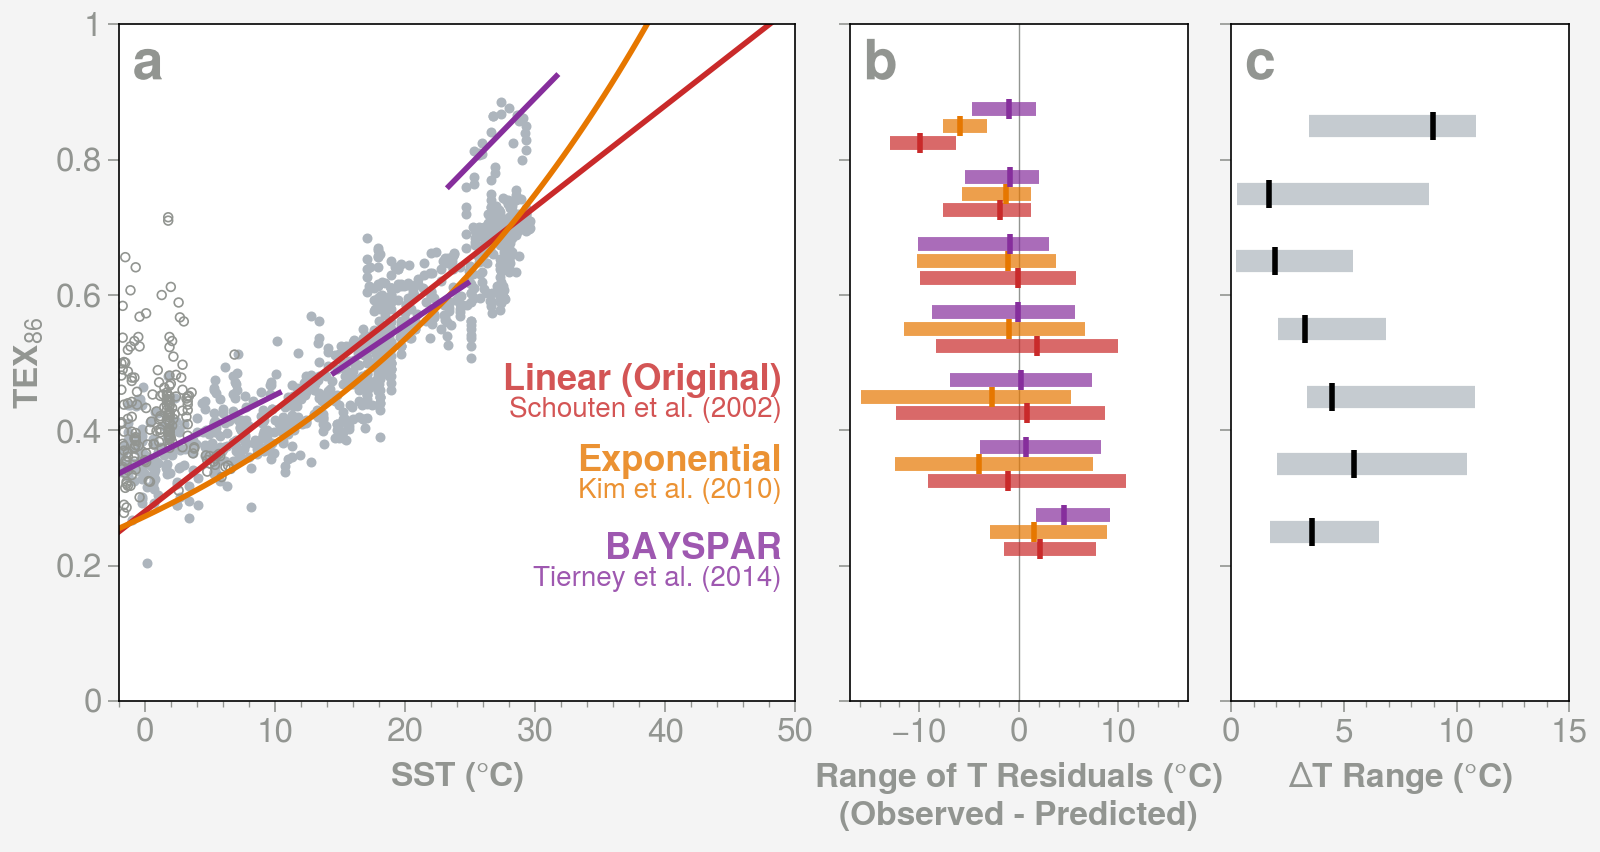

In [38]:
fig, axs = plot.subplots(width=8,ncols=3,wratios=[1,0.5,0.5],sharex=0)

ax = axs[0] 
# grouped = gridded_combined_df.groupby('datatype')
# for name, group in grouped:
#     if name!='coretop':
#         continue
#     else:
#         ax.scatter(group['SST'], group['TEX86'], 
#                 m=datatype_marker_dict.get(name,'o'), 
#                 mec='none' if name=='coretop' else 'black',
#                 label=name,
#                 color=datatype_color_dict.get(name,'gray5'),)

below70N_idx = TT15_coretop_df['latitude']<70
ax.scatter(TT15_coretop_df['WOA09_SST'][below70N_idx], TT15_coretop_df['tex86'][below70N_idx],
           m='.',
           c='gray5')
print("Data <70N len: ",len(TT15_coretop_df['WOA09_SST'][below70N_idx]))
ax.scatter(TT15_coretop_df['WOA09_SST'][~below70N_idx], TT15_coretop_df['tex86'][~below70N_idx],
           m='o',mec="gray",s=10,
           facecolor='none',
           label='>70°N')
print("Data >70N len: ",len(TT15_coretop_df['WOA09_SST'][~below70N_idx]))
ax.format(
    xlabel=r'SST ($\degree$C)',
    ylabel=r'TEX$_{86}$',
)

#### existing calibration models

temperature_range = np.linspace(-2, 50, 100)
methods = ['schouten02','kim2010_tex86H']
colors = ['red9','yellow9','lime9']
for i, method_name in enumerate(methods):
    predicted_tex = predictTEXfromSST(temperature_range,method_name=method_name)
    ax.plot(temperature_range, predicted_tex,
            c=colors[i],lw=2,
            ls='-',
            label=f'{method_name}',)
    
#### bayspar forward model

mid_redsea_lat = coretop_df[coretop_df['regionName']=='Red Sea']['match_lat_04deg'].median()
mid_redsea_lon = coretop_df[coretop_df['regionName']=='Red Sea']['match_lon_04deg'].median()
min_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].min()-2
max_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].max()+2
print("Lat/Lon Red Sea: ", mid_redsea_lat, mid_redsea_lon)
xx = np.linspace(min_redsea_sst, max_redsea_sst, 50)
pred_tex_redsea = bayspar_percentile(bsr.predict_tex(
    xx,
    lat=mid_redsea_lat,
    lon=mid_redsea_lon,
    temptype='sst'
),50)

ax.plot([xx.min(),xx.max()], [pred_tex_redsea.min(),pred_tex_redsea.max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Red Sea',)


min_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].min()-2
max_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].max()+2
xx = np.linspace(min_mediterranean_sst, max_mediterranean_sst, 50)

mid_mediterranean_lat = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lat_04deg'].median()
mid_mediterranean_lon = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lon_04deg'].median()
print("Lat/Lon Mediterranean: ", mid_mediterranean_lat, mid_mediterranean_lon)
pred_tex_mediterranean = bayspar_percentile(bsr.predict_tex(
    xx,
    lat=mid_mediterranean_lat,
    lon=mid_mediterranean_lon,
    temptype='sst'
),q=[10,50,90])

ax.plot([xx.min(),xx.max()], [pred_tex_mediterranean[:,1].min(),pred_tex_mediterranean[:,1].max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Mediterranean Sea',)

# ax.fill_between([xx.min(),xx.max()], 
#                 [pred_tex_mediterranean[:,0].min(),pred_tex_mediterranean[:,0].max()],
#                 [pred_tex_mediterranean[:,2].min(),pred_tex_mediterranean[:,2].max()],
#                 color='grape9',alpha=0.2)

min_southernocean_sst = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['SST'].min()-2
max_southernocean_sst = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['SST'].max()+2
xx = np.linspace(min_southernocean_sst, max_southernocean_sst, 50)
mid_southernocean_lat = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['match_lat_04deg'].median()
mid_southernocean_lon = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['match_lon_04deg'].median()
print("Lat/Lon Southern Ocean: ", mid_southernocean_lat, mid_southernocean_lon)
pred_tex_southernocean = bayspar_percentile(bsr.predict_tex(
    xx,
    lat=mid_southernocean_lat,
    lon=mid_southernocean_lon,
    temptype='sst'
),q=[10,50,90])

ax.plot([xx.min(),xx.max()], [pred_tex_southernocean[:,1].min(),pred_tex_southernocean[:,1].max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Southern Ocean',)

ax.format(
    ylim=(0,1),
    xlim=(-2,50),
    tickminor=False
)

method_list = ['schouten02','kim2010_tex86H']
annonation_dict = {
    "schouten02":{"text": "Linear (Original)","y_top": 0.5,"color": 'red9',
              "source":"Schouten et al. (2002)"},
    "kim2010_tex86H":{"text": "Exponential","y_top": 0.38,"color": 'yellow9',
                "source":"Kim et al. (2010)"},
    "BAYSPAR":{"text": "BAYSPAR","y_top": 0.25,"color": 'grape9',
                "source":"Tierney et al. (2014)"},
}
### Calibration models annotation
for i, method_name in enumerate(methods):
    if method_name in annonation_dict:
        text_str = annonation_dict[method_name]["text"]
        y_top = annonation_dict[method_name]["y_top"]
        color = annonation_dict[method_name]["color"]
        ax.text(0.98,y_top,
                text_str,
                transform=ax.transAxes,
                color=color,
                fontsize=13, fontweight='bold',
                ha='right',
                va='top',
                alpha=0.8
               )
        ax.text(0.98,y_top-0.05,
                annonation_dict[method_name]["source"],
                transform=ax.transAxes,
                color=color,
                fontsize=10,
                ha='right',
                va='top',
                alpha=0.8
               )
### annotation for BAYSPAR
text_str = annonation_dict["BAYSPAR"]["text"]
y_top = annonation_dict["BAYSPAR"]["y_top"]
color = annonation_dict["BAYSPAR"]["color"]
ax.text(0.98,y_top,
        text_str,
        transform=ax.transAxes,
        color=color,
        fontsize=13, fontweight='bold',
        ha='right',
        va='top',
        alpha=0.8
       )
ax.text(0.98,y_top-0.05,
        annonation_dict["BAYSPAR"]["source"],
        transform=ax.transAxes,
        color=color,
        fontsize=10,
        ha='right',
        va='top',
        alpha=0.8
       )
#### boxplot of T residuals
ax = axs[1]
method_list = ['schouten02','kim2010_tex86H','bayspar']
colors = ['red9','yellow9','grape9']
ypos_offset = [-0.025,0,0.025]
for i in range(len(binned_t_res_df)):
    ypos = binned_t_res_df['binned_tex86'].iloc[i].mid
    for j, method_name in enumerate(method_list):
        res_min = binned_t_res_df[f'Tres_{method_name}_min'].iloc[i]
        res_max = binned_t_res_df[f'Tres_{method_name}_max'].iloc[i]
        res_mean = binned_t_res_df[f'Tres_{method_name}_mean'].iloc[i]
        ax.plot([res_min, res_max],
                [ypos+ypos_offset[j], ypos+ypos_offset[j]],
                c=colors[j], lw=5, solid_capstyle='butt', alpha=0.7)
        ax.plot(res_mean,
                ypos+ypos_offset[j],
                marker='|', c=colors[j], markersize=7,markeredgewidth=2,zorder=5)

ax.format(
    xlabel=r'Range of T Residuals ($\degree$C)'+'\n(Observed - Predicted)',
    xlim=(-17,17),
)

### boxplot of prediction ranges
ax = axs[2] 
for i in range(len(binned_tex_t_est_df)):
    ypos = binned_tex_t_est_df['mid_tex_bin'].iloc[i]
    ax.plot([binned_tex_t_est_df['t_est_range_min'].iloc[i], binned_tex_t_est_df['t_est_range_max'].iloc[i]],
            [ypos, ypos],
            c='gray5', lw=8, solid_capstyle='butt', alpha=0.7)
    ax.plot(binned_tex_t_est_df['t_est_range_mean'].iloc[i],
            ypos,
            marker='|', c='black', markersize=10,markeredgewidth=2)
    
ax.format(
    xlabel=r'$\Delta$T Range ($\degree$C)',
    ylabel=r'',
    xlim=(0,15),
    ylim=(0,1),
    tickminor=False
)
# h, l = ax.get_legend_handles_labels()
# ax.legend(h[5:], l[5:], loc='ul', ncols=1,frameon=False)
# ax.legend(h[:5], l[:5], loc='lr', ncols=1,frameon=False)

axs[1].axvline(0,zorder=0,lw=0.5,c="gray")


axs.format(
    abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor="gray",
    fontsize=12, labelsize=12,
    labelcolor="gray", xtickcolor="gray", ytickcolor="gray",
    xticklabelcolor="gray", yticklabelcolor="gray",
    xlabelweight='bold', ylabelweight='bold',
    xtickminor=True, grid=False,
)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'fig1_existing_calibrations_with_DeltaT_Tres_ranges_t0shift.pdf'),dpi=300)

# Residuals plot

In [39]:
import numpy as np
from scipy.stats import gamma
import xarray as xr

def calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25):
    """
    Calculate gamma-weighted subsurface temperature (0-200m).
    
    Parameters:
    -----------
    T_da : xarray.DataArray
        Temperature data with depth dimension
    depth_dim : str
        Name of depth dimension (default: 'depth')
    alpha : float
        Gamma distribution shape parameter (default: 6.5)
    beta : float
        Gamma distribution scale parameter (default: 25 meters)
    
    Returns:
    --------
    subT : xarray.DataArray
        Gamma-weighted subsurface temperature
    """
    
    # Select top 200m
    T_200m = T_da.sel({depth_dim: slice(0, 200)})
    depths = T_200m[depth_dim].values
    
    # Calculate gamma weights
    # Gamma PDF: f(z; α, β) = (z^(α-1) * exp(-z/β)) / (β^α * Γ(α))
    weights = gamma.pdf(depths, a=alpha, scale=beta)
    
    # Normalize weights to sum to 1
    weights_norm = weights / np.sum(weights)
    
    # Create xarray DataArray for weights
    weights_da = xr.DataArray(
        weights_norm,
        coords={depth_dim: depths},
        dims=[depth_dim]
    )
    
    # Calculate weighted average
    subT = (T_200m * weights_da).sum(dim=depth_dim)
    
    return subT

# Usage example:
subT = calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25)

In [40]:
coretop_df['subT_gamma'] = np.array([
    subT.sel(lon=coretop_df.loc[i,'match_lon_04deg'], lat=coretop_df.loc[i,'match_lat_04deg'], method='nearest').values
    for i in range(len(coretop_df))
])

# Predict proxy values from temperature

In [41]:
# pred_TEX_BAYSPAR_SST = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     sst = row['SST']
#     if not np.isnan(sst):
#         pred_TEX_BAYSPAR_SST[i] = bsr.predict_tex(
#             np.atleast_1d(sst),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             temptype='sst'
#         ).percentile(50)[0]
        
# display(pred_TEX_BAYSPAR_SST)

# pred_TEX_BAYSPAR_subT = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     sst = row['subT_gamma']
#     if not np.isnan(sst):
#         pred_TEX_BAYSPAR_subT[i] = bsr.predict_tex(
#             np.atleast_1d(sst),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             temptype='subt'
#         ).percentile(50)[0]
        
# pred_TEX_BAYSPAR_subT

# ## Save for reuse
# a = coretop_df[['match_lat_04deg', 'match_lon_04deg']]
# b = pd.DataFrame(pred_TEX_BAYSPAR_SST,columns=['predTEX_bsr_sst'])
# c = pd.DataFrame(pred_TEX_BAYSPAR_subT,columns=['predTEX_bsr_subt'])

# pred_TEX_BAYSPAR_p50_df = pd.concat([a,b,c],axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'predTEX_bayspar_p50.csv'
# pred_TEX_BAYSPAR_p50_df.to_csv(os.path.join(fpath,fname),index=False)

## load result
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'predTEX_bayspar_p50.csv'
pred_TEX_BAYSPAR_p50_df = pd.read_csv(os.path.join(fpath,fname))
pred_TEX_BAYSPAR_SST = pred_TEX_BAYSPAR_p50_df['predTEX_bsr_sst']
pred_TEX_BAYSPAR_subT= pred_TEX_BAYSPAR_p50_df['predTEX_bsr_subt']

In [42]:
def run_bayesian_variance_partitioning(posterior_names: dict) -> dict:
    """
    Compute sequential R² variance partitioning by loading each separately-fit
    posterior and extracting R2_full / bayesR2_full per draw.

    Each posterior uses its OWN estimated parameters, avoiding the parameter
    confounding that arises from zeroing betas in a single full-model posterior.
    Delta quantities are derived by differencing R2_full across posteriors.

    Parameters
    ----------
    posterior_names : dict
        Keys are model labels, values are posterior name strings for load_posterior().
        Expected keys (in sequential order):
            'Tonly' : univariate posterior (T only)
            'TG23'  : bivariate posterior (T + G23)
            'full'  : full posterior (T + G23 + NO3)
        Optional:
            'TNO3'  : bivariate posterior (T + NO3 only), if available

    Returns
    -------
    dict with keys:
        'R2_full', 'R2_TG23', 'R2_TNO3', 'R2_Tonly'  (if TNO3 provided)
        'bayesR2_full', 'bayesR2_TG23', 'bayesR2_Tonly'
        'RMSE_full', 'RMSE_TG23', 'RMSE_TNO3', 'RMSE_Tonly'
        'deltaR2_G23', 'deltaR2_NO3', 'deltaR2_both'
        'delta_bayesR2_G23', 'delta_bayesR2_NO3', 'delta_bayesR2_both'
        Each value: {median, lo68, hi68, lo90, hi90, formatted, formatted_68ci}
    """
    import numpy as np
    from TEXAS.stan.io import load_posterior

    draws = {}
    for key, name in posterior_names.items():
        post = load_posterior(name)
        draws[key] = {
            'R2_full':      post['R2_full'].values.ravel(),
            'bayesR2_full': post['bayesR2_full'].values.ravel(),
            'RMSE_full':    post['RMSE_full'].values.ravel(),
        }

    def _summarize(arr):
        med = float(np.median(arr))
        return {
            'median':         med,
            'lo68':           float(np.percentile(arr, 16)),
            'hi68':           float(np.percentile(arr, 84)),
            'lo90':           float(np.percentile(arr, 5)),
            'hi90':           float(np.percentile(arr, 95)),
            'formatted':      _fmt_r2(med),
            'formatted_68ci': f"{_fmt_r2(med)} [{_fmt_r2(float(np.percentile(arr, 16)))}, {_fmt_r2(float(np.percentile(arr, 84)))}]",
        }

    results = {}

    # ── Per-model R2 ──────────────────────────────────────────────────────────
    for key in ['Tonly', 'TG23', 'TNO3', 'full']:
        if key in draws:
            results[f'R2_{key}']      = _summarize(draws[key]['R2_full'])
            results[f'bayesR2_{key}'] = _summarize(draws[key]['bayesR2_full'])
            results[f'RMSE_{key}']    = _summarize(draws[key]['RMSE_full'])

    # ── Delta R2 (frequentist) ────────────────────────────────────────────────
    if 'TG23' in draws and 'Tonly' in draws:
        results['deltaR2_G23']  = _summarize(draws['TG23']['R2_full']  - draws['Tonly']['R2_full'])
    if 'TNO3' in draws and 'Tonly' in draws:
        results['deltaR2_NO3']  = _summarize(draws['TNO3']['R2_full']  - draws['Tonly']['R2_full'])
    if 'full' in draws and 'Tonly' in draws:
        results['deltaR2_both'] = _summarize(draws['full']['R2_full']  - draws['Tonly']['R2_full'])

    # ── Delta R2 (Bayesian) ───────────────────────────────────────────────────
    if 'TG23' in draws and 'Tonly' in draws:
        results['delta_bayesR2_G23']  = _summarize(draws['TG23']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])
    if 'TNO3' in draws and 'Tonly' in draws:
        results['delta_bayesR2_NO3']  = _summarize(draws['TNO3']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])
    if 'full' in draws and 'Tonly' in draws:
        results['delta_bayesR2_both'] = _summarize(draws['full']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])

    return results


def print_bayesian_vp_table(res: dict, label: str = "") -> None:
    """Print sequential R² table with 68% CI for both freq and Bayesian R²."""
    title = "Variance Partitioning" + (" — " + label if label else "")
    hdr = (f"  {'Model':<28} "
           f"{'Freq R2':>8} {'68% CI':>16}  "
           f"{'Bayes R2':>9} {'68% CI':>16}  "
           f"{'RMSE':>7} {'68% CI':>16}")
    sep = "-" * len(hdr)
    print(f"\n{title}")
    print(sep)
    print(hdr)
    print(sep)

    def _ci(v):
        return f"[{_fmt_r2(v['lo68'])}, {_fmt_r2(v['hi68'])}]"

    def _row(label, r2_key, br2_key, rmse_key=None, indent=0):
        pad = "  " * indent
        fv = res.get(r2_key)
        bv = res.get(br2_key)
        rv = res.get(rmse_key) if rmse_key else None
        fstr = f"{fv['formatted']:>8} {_ci(fv):>16}" if fv else f"{'--':>8} {'':>16}"
        bstr = f"{bv['formatted']:>9} {_ci(bv):>16}" if bv else f"{'--':>9} {'':>16}"
        rstr = f"{_fmt_rmse(rv['median']):>7} {_ci(rv):>16}" if rv else f"{'--':>7} {'':>16}"
        print(f"  {pad}{label:<{28 - len(pad)}}  {fstr}  {bstr}  {rstr}")

    _row("T only (baseline)", "R2_Tonly",  "bayesR2_Tonly", "RMSE_Tonly")
    _row("+ G23",             "R2_TG23",   "bayesR2_TG23",  "RMSE_TG23")
    _row("+ NO3",             "R2_TNO3",   "bayesR2_TNO3",  "RMSE_TNO3")
    _row("+ G23 + NO3 (full)","R2_full",   "bayesR2_full",  "RMSE_full")
    print(sep)
    print(f"  {'delta-R2':<28}  {'Freq':>8} {'68% CI':>16}  {'Bayes':>9} {'68% CI':>16}  {'RMSE':>7} {'68% CI':>16}")
    print(sep)
    _row("G23",  "deltaR2_G23",  "delta_bayesR2_G23",  indent=1)
    _row("NO3",  "deltaR2_NO3",  "delta_bayesR2_NO3",  indent=1)
    _row("Both", "deltaR2_both", "delta_bayesR2_both", indent=1)
    print(sep)


In [43]:
def multivariate_frequentist_model(X, x0, b, k, v, betaG23=0, betaNO3=0, threshold=1.8):
    """
    Frequentist implementation of the multivariate RI model.
    X: 2D array with columns [Temp, GDGT23, NO3]
    """
    t = X[:, 0]
    gdgt23 = X[:, 1]
    no3 = X[:, 2]
    
    # 1. Base Logistic Temperature Model
    # Note: Assumes generalized_logistic_model_fixed_upper is defined elsewhere
    pred_ri = generalized_logistic_model_fixed_upper(t, x0, b, k, v)
    
    # 2. GDGT-2/3 Correction
    pred_ri += betaG23 * gdgt23
    
    # 3. NO3 Correction (Zero-anchored with hard cutoff)
    no3_term = np.zeros_like(no3)
    # Mask to match: if (no3 > 0 && no3 < cutoff)
    mask = (no3 > 0) & (no3 < threshold)
    no3_term[mask] = betaNO3 * np.log10(no3[mask] + 1e-9)
    
    pred_ri += no3_term
    
    return pred_ri

In [44]:

# XX = np.linspace(-2,50,200)
# predRI_thermoT_Tonly_frequentist = generalized_logistic_model_fixed_upper(
#     coretop_df['t_sf2tc_avg'],*res_hier_glob_fixed_thermoT['popt_global']
# )
# RIres_thermoT_Tonly_frequentist = coretop_df['scaledRI'] - predRI_thermoT_Tonly_frequentist

# predRI_thermoT_T_g23r_frequentist = multivariate_frequentist_model(
#     coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_thermoT['popt_global'],
#     betaG23=res_hier_thermoT['beta_g23']['biv'][0],
#     betaNO3=0
# )
# RIres_thermoT_T_g23r_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_g23r_frequentist

# predRI_thermoT_T_no3_frequentist = multivariate_frequentist_model(
#     coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_thermoT['popt_global'],
#     betaG23=0,
#     betaNO3=res_hier_thermoT['beta_no3']['biv'][0]
# )
# RIres_thermoT_T_no3_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_no3_frequentist

# predRI_thermoT_T_g23r_no3_frequentist = multivariate_frequentist_model(
#     coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_thermoT['popt_global'],
#     betaG23=res_hier_thermoT['beta_g23']['mul'][0],
#     betaNO3=res_hier_thermoT['beta_no3']['mul'][0]
# )
# RIres_thermoT_T_g23r_no3_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_g23r_no3_frequentist



In [45]:

# XX = np.linspace(-2,50,200)
# predRI_SST_Tonly_frequentist = generalized_logistic_model_fixed_upper(
#     coretop_df['SST'],*res_hier_glob_fixed_SST['popt_global']
# )
# RIres_SST_Tonly_frequentist = coretop_df['scaledRI'] - predRI_SST_Tonly_frequentist

# predRI_SST_T_g23r_frequentist = multivariate_frequentist_model(
#     coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_SST['popt_global'],
#     betaG23=res_hier_SST['beta_g23']['biv'][0],
#     betaNO3=0
# )
# RIres_SST_T_g23r_frequentist = coretop_df['scaledRI'] - predRI_SST_T_g23r_frequentist

# predRI_SST_T_no3_frequentist = multivariate_frequentist_model(
#     coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_SST['popt_global'],
#     betaG23=0,
#     betaNO3=res_hier_SST['beta_no3']['biv'][0]
# )
# RIres_SST_T_no3_frequentist = coretop_df['scaledRI'] - predRI_SST_T_no3_frequentist

# predRI_SST_T_g23r_no3_frequentist = multivariate_frequentist_model(
#     coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_SST['popt_global'],
#     betaG23=res_hier_SST['beta_g23']['mul'][0],
#     betaNO3=res_hier_SST['beta_no3']['mul'][0]
# )
# RIres_SST_T_g23r_no3_frequentist = coretop_df['scaledRI'] - predRI_SST_T_g23r_no3_frequentist



In [46]:
coretop_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,weighted_tex_cren3,weighted_tex_cren5,ocean_region_id,ocean_region,ocean_region_abbrev,pred_scaledRI_cren3,residual_scaledRI_cren3,pred_scaledRI_cren3_thermoT,residual_scaledRI_cren3_thermoT,subT_gamma
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,1.647303,1.874926,24.0,Weddell Sea,Weddell Sea,0.456216,0.053767,0.455350,0.054632,-1.853857
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,1.498516,1.652819,27.0,Ross Sea,Ross Sea,0.454072,-0.015954,0.453192,-0.015073,-1.799108
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,1.556650,1.741155,24.0,Weddell Sea,Weddell Sea,0.455416,-0.044481,0.454587,-0.043652,-1.890376
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,1.486532,1.607744,24.0,Weddell Sea,Weddell Sea,0.455787,-0.022444,0.454774,-0.021432,-1.784612
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,1.515084,1.693855,24.0,Weddell Sea,Weddell Sea,0.454873,-0.007357,0.454361,-0.006845,-1.861055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,84.125,46.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,1.562667,1.797333,0.0,Arctic Ocean,Arctic Ocean,0.454644,-0.008094,0.454777,-0.008227,0.299375
1509,84.875,40.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,1.530122,1.741537,0.0,Arctic Ocean,Arctic Ocean,0.452077,-0.012689,0.452350,-0.012961,-0.503482
1510,86.875,-146.125,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,1.721014,2.253623,0.0,Arctic Ocean,Arctic Ocean,0.443189,-0.043339,0.443395,-0.043545,-1.230342
1511,87.125,104.625,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,1.825056,2.353273,0.0,Arctic Ocean,Arctic Ocean,0.453345,-0.020270,0.453787,-0.020712,-0.903467


In [47]:
x_params = ['SST','t_sf2tc_avg']
temp_param_label = {'t_sf2tc_avg':'thermoT'}
y_params = ['scaledRI_cren3']

for x_param in x_params:
    for y_param in y_params:
        no3_threshold = 1.0
        coretop_df[f'pred_{y_param}_{x_param}only'] = generate_ensemble_auto(
            load_posterior(fwd_name(temp_param_label.get(x_param, x_param), y_param, stem=UNIV_STEM)),
            x_vals = coretop_df[x_param])['p50']

        coretop_df[f'{y_param}_res_{x_param}only'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}only']

        coretop_df[f'pred_{y_param}_{x_param}_g23r'] = generate_ensemble_auto(
            load_posterior(fwd_name(temp_param_label.get(x_param, x_param), y_param, gdgt23ratio=True, no3_cutoff=no3_threshold)),
            x_vals = coretop_df[x_param],
            gdgt23ratio = coretop_df['gdgt23ratio'],
        )['p50']
        coretop_df[f'{y_param}_res_{x_param}_g23r'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_g23r']

        coretop_df[f'pred_{y_param}_{x_param}_no3'] = generate_ensemble_auto(
            load_posterior(fwd_name(temp_param_label.get(x_param, x_param), y_param, gdgt23ratio=True, no3_cutoff=no3_threshold)),
            x_vals = coretop_df[x_param],
            no3 = coretop_df['no3_sf2tc_avg'],
            no3_cutoff=1)['p50']
        coretop_df[f'{y_param}_res_{x_param}_no3'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_no3']

        coretop_df[f'pred_{y_param}_{x_param}_g23r_no3'] = generate_ensemble_auto(
            load_posterior(fwd_name(temp_param_label.get(x_param, x_param), y_param, gdgt23ratio=True, no3_cutoff=no3_threshold)),
            x_vals = coretop_df[x_param],
            gdgt23ratio = coretop_df['gdgt23ratio'],
            no3 = coretop_df['no3_sf2tc_avg'],
            no3_cutoff=1)['p50']
        coretop_df[f'{y_param}_res_{x_param}_g23r_no3'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_g23r_no3']

In [48]:
# Calculate TEX86 predictions and residuals
pred_TEX_schouten02 = predictTEXfromSST(coretop_df['SST'], method_name='schouten02')
pred_TEX_kim2010 = predictTEXfromSST(coretop_df['SST'], method_name='kim2010_tex86H')

TEX_residuals_schouten02 = coretop_df['TEX86'] - pred_TEX_schouten02
TEX_residuals_kim2010 = coretop_df['TEX86'] - pred_TEX_kim2010
TEX_residuals_BAYSPAR_SST = coretop_df['TEX86'] - pred_TEX_BAYSPAR_SST
TEX_residuals_BAYSPAR_subT = coretop_df['TEX86'] - pred_TEX_BAYSPAR_subT

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

class FlatCenterNormalize(Normalize):
    def __init__(self, vmin=None, vmax=None, center=0, plateau_width=0.025, clip=False):
        self.center = center
        self.plateau_width = plateau_width
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # Process input value(s)
        result, is_scalar = self.process_value(value)
        vmin, vmax = self.vmin, self.vmax
        # Map values in a piecewise linear fashion:
        # vmin --> 0, (center - plateau) --> 0.5, (center + plateau) --> 0.5, vmax --> 1
        mapped = np.ma.masked_array(np.interp(result, 
                    [vmin, self.center - self.plateau_width, self.center + self.plateau_width, vmax],
                    [0, 0.5, 0.5, 1]))
        if is_scalar:
            mapped = mapped[0]
        return mapped


#### Fig. S11 | Forward calibration performance of existing TEX<sub>86</sub> calibrations and TEXAS evaluated against the extended global coretop dataset

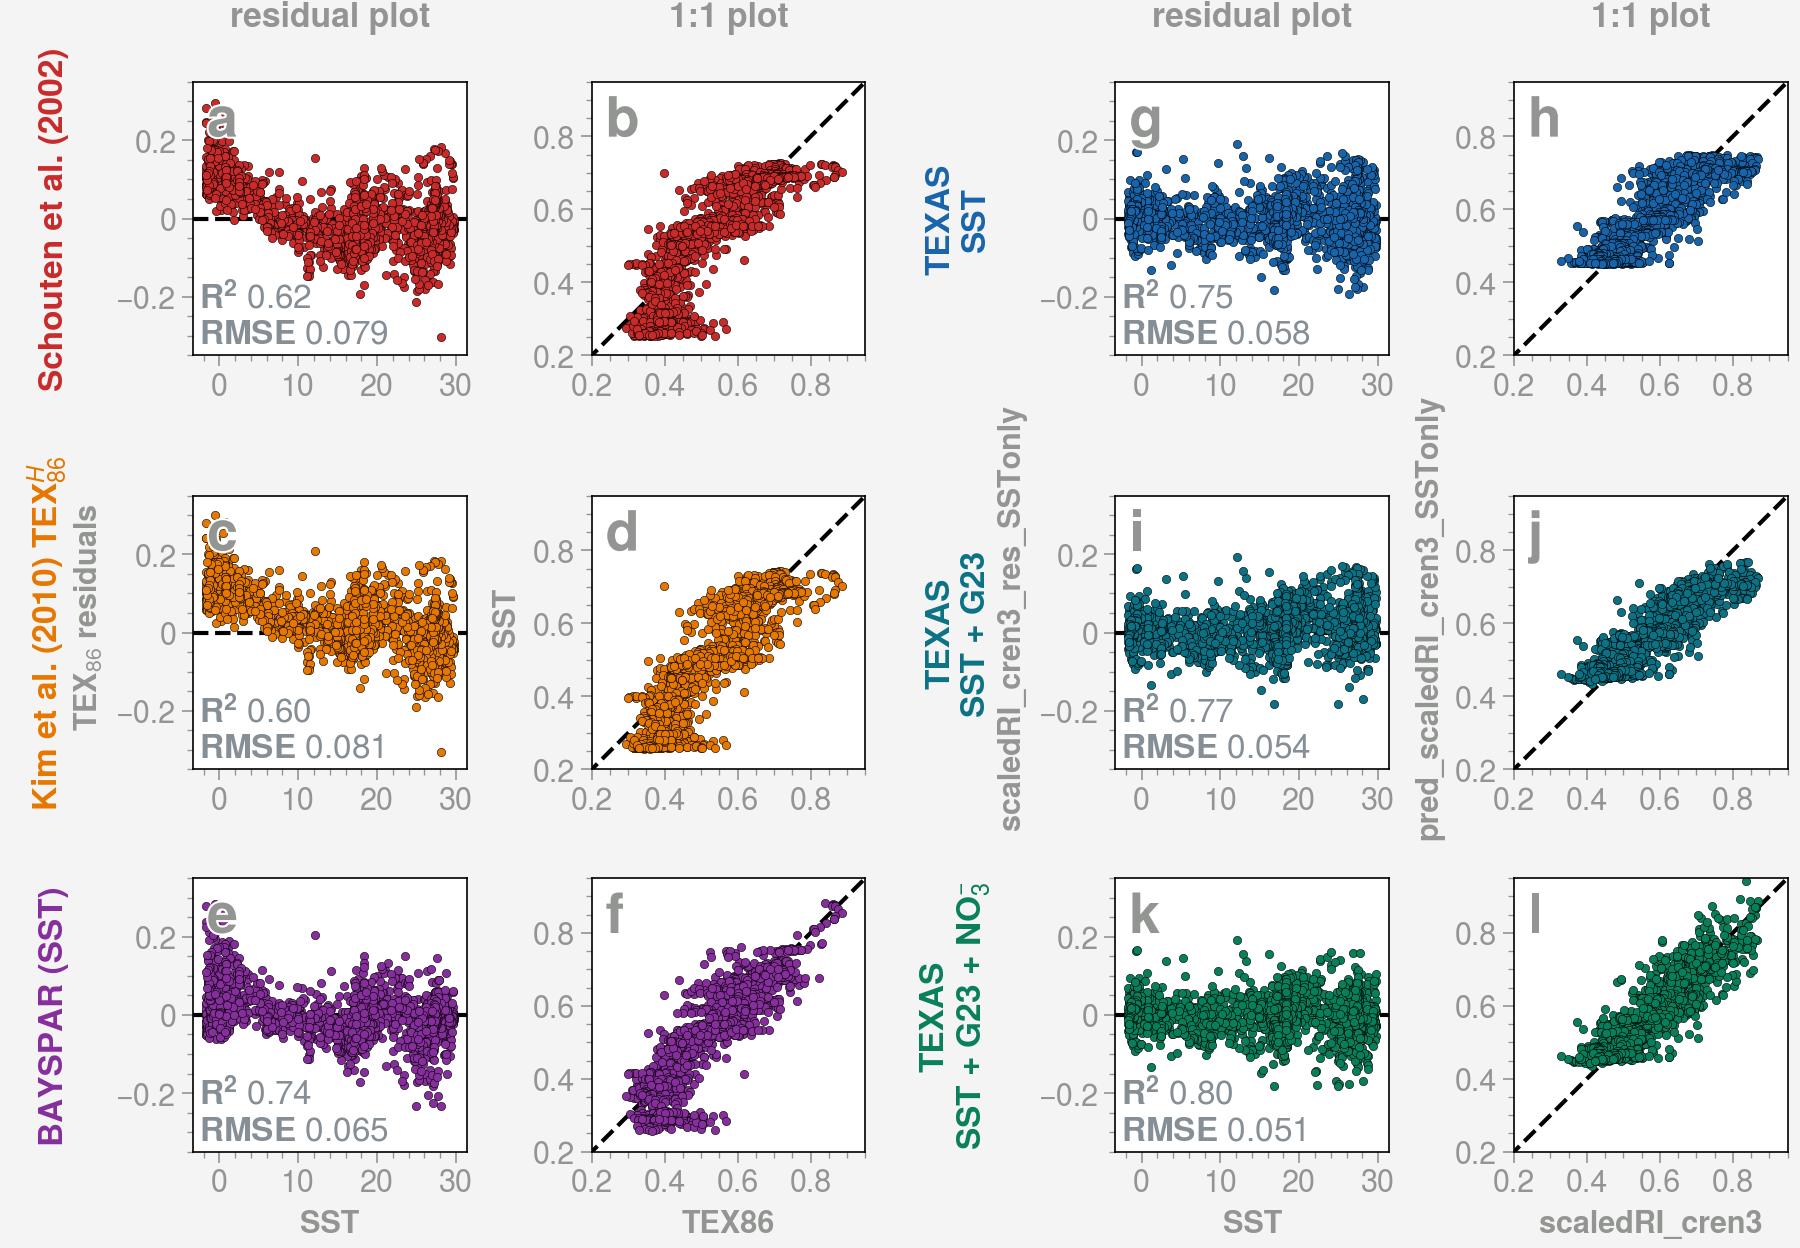

In [50]:
temp_param = 'SST'
y_param = 'scaledRI_cren3'
data = [
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_schouten02, TEX_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_kim2010, TEX_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_BAYSPAR_SST, TEX_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}only"], coretop_df[f"{y_param}_res_{temp_param}only"], 'blue9', f'TEXAS\n{temp_param}'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r"], coretop_df[f"{y_param}_res_{temp_param}_g23r"], 'cyan9', f'TEXAS\n{temp_param} + G23'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{temp_param}_g23r_no3"], 'teal9', f'TEXAS\n{temp_param} '+r'+ G23 + NO$_{3}^{-}$'),    
]

array = [
    [1,2,7,8],
    [3,4,9,10],
    [5,6,11,12]
]
fig, axs = plot.subplots(
    array,
    width=9,  
    share=0,
    wspace=[5,10,5])
axs.format(collabels=['residual plot', '1:1 plot','residual plot', '1:1 plot'],
           toplabels_kw={'size': 14,
                         'weight': 'bold',
                         'color':"gray"},)

metrics = []
row_labels = []
for _, measured, predicted, residuals, _, _ in data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics.append((r2, rmse))
    
ii=0
for i, ((predictor, measured, predicted, residuals, color, method_label),
        (r2, rmse)) in enumerate(zip(data, metrics)):

    # Column 0: Map of residuals
    
    
    if i <= 2:
        col_idx = 2 if 'TEXAS' in method_label else 0 
        ax = axs[i, col_idx]
        text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
        ax.text(0.02,0.02, text, transform=ax.transAxes,
                fontsize=12, ha='left', va='bottom', c='gray6')
        
        method_text = f"{method_label}"
        ax.text(-0.45,0.5,method_text,
                transform=ax.transAxes,
                fontsize=12, fontweight='bold',
                ha='right', va='center', c=color,
                rotation=90)
        
        # Column 1: Residuals vs Temperature
        ax = axs[i, col_idx]
        ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
        ax.axhline(0, c='k', ls='--', zorder=0)
        ax.format(
            xticks=np.arange(0, 40.1, 10)
        )
        
        col_idx = 3 if 'TEXAS' in method_label else 1
        # Column 2: Predicted vs Measured
        ax = axs[i, col_idx]
        ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
        ax.plot([0.1, 1.0], [0.1, 1.0], c='k', ls='--', zorder=0)
        ax.format(
            xticks=np.arange(0.2, 0.91, 0.2),
            yticks=np.arange(0.2, 0.91, 0.2),
        )
        
    else:
        col_idx = 2 if 'TEXAS' in method_label else 0 
        ax = axs[ii, col_idx]
        text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
        ax.text(0.02,0.02, text, transform=ax.transAxes,
                fontsize=12, ha='left', va='bottom', c='gray6')
        
        method_text = f"{method_label}"
        ax.text(-0.45,0.5,method_text,
                transform=ax.transAxes,
                fontsize=12, fontweight='bold',
                ha='right', va='center', c=color,
                multialignment='center',
                rotation=90)
        
        # Column 1: Residuals vs Temperature
        ax = axs[ii, col_idx]
        ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
        ax.axhline(0, c='k', ls='--', zorder=0)
        ax.format(
            xticks=np.arange(0, 40.1, 10)
        )
        
        col_idx = 3 if 'TEXAS' in method_label else 1
        # Column 2: Predicted vs Measured
        ax = axs[ii, col_idx]
        ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
        ax.plot([0.1, 1.0], [0.1, 1.0], c='k', ls='--', zorder=0)
        ax.format(
            xticks=np.arange(0.2, 0.91, 0.2),
            yticks=np.arange(0.2, 0.91, 0.2),
        )   
        ii += 1 

axs[:,0].format(ylim=(-0.35,0.35),ylabel=r'TEX$_{86}$ residuals',xlabel=r"Temperature ($\degree$C)")
axs[:,1].format(xlabel=r'Measured TEX$_{86}$',ylabel=r'Predicted TEX$_{86}$',
                xlim=(0.2,0.95),ylim=(0.2,0.95),)
axs[:,2].format(ylim=(-0.35,0.35),ylabel='Scaled RI residuals',xlabel=r"Temperature ($\degree$C)")
axs[:,3].format(xlabel=r'Measured Scaled RI',ylabel=r'Predicted Scaled RI',
                xlim=(0.2,0.95),ylim=(0.2,0.95))
axs.format(
    labelsize=11, fontsize=11, labelweight='bold',
    grid=False,
    abc=True, abcstyle='a', abcsize=20, abcweight='bold', abcloc='ul',
    abccolor="gray", labelcolor="gray", textcolor="gray",
    tickcolor="gray", ticklabelcolor="gray",
)


fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS11_comparison_all_calibrations_residuals_maps_and_scatterplots_t0shift.pdf'
fig.savefig(os.path.join(fpath,fname), dpi=300)

In [51]:
fpath = f'{local_github_path}/data/spreadsheets/published_data'
fname = 'Kim2010_coretop.xlsx'
kim2010_coretop_df = pd.read_excel(os.path.join(fpath,fname)).rename(
    columns={
        'Satellite T (°C)':'SST',
        'TEX86 ':'TEX86'
    }
)

kim2010_coretop_df['predSST'] = predictSSTfromTEX(
    kim2010_coretop_df['TEX86'],method_name='kim2010_tex86H'
)
kim2010_coretop_df['predTEX'] = predictTEXfromSST(
    kim2010_coretop_df['SST'],method_name='kim2010_tex86H'
)



In [52]:
print(r"R^2:", r2_score(kim2010_coretop_df['TEX86'],kim2010_coretop_df['predTEX']))

residuals = kim2010_coretop_df['TEX86'] - kim2010_coretop_df['predTEX']
rmse = np.sqrt(np.mean(residuals**2))
print("RMSE:", rmse)

R^2: 0.6350387954004244
RMSE: 0.08616691232988934


In [53]:
# temp_param = 't_sf2tc_avg'
# y_param = 'scaledRI_cren3'
# data = [
#     (coretop_df["subT_gamma"], coretop_df['TEX86'], pred_TEX_BAYSPAR_subT, TEX_residuals_BAYSPAR_subT, 'grape9', 'BAYSPAR (SubT)'),
    
#     (coretop_df[temp_param], coretop_df[y_param], 
#      coretop_df[f"pred_{y_param}_{temp_param}only"], coretop_df[f"{y_param}_res_{temp_param}only"], 'blue9', f'TEXAS\nThermo-T'),
#     (coretop_df[temp_param], coretop_df[y_param], 
#      coretop_df[f"pred_{y_param}_{temp_param}_g23r"], coretop_df[f"{y_param}_res_{temp_param}_g23r"], 'cyan9', f'TEXAS\nThermo-T + G23'),
#     (coretop_df[temp_param], coretop_df[y_param], 
#      coretop_df[f"pred_{y_param}_{temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{temp_param}_g23r_no3"], 'teal9', f'TEXAS\nThermo-T '+r'+ G23 + NO$_{3}^{-}$'),    
# ]

# fig, axs = plot.subplots(width=5, ncols=2, nrows=len(data), share=0,)
# axs.format(collabels=['residual plot', '1:1 plot'],)
# metrics = []
# row_labels = []
# for _, measured, predicted, residuals, _, _ in data:
#     nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
#     r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
#     rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
#     metrics.append((r2, rmse))
    

# for i, ((predictor, measured, predicted, residuals, color, method_label),
#         (r2, rmse)) in enumerate(zip(data, metrics)):
#     row_labels.append(method_label)
#     # Column 0: Map of residuals
#     ax = axs[i, 0]
#     text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
#     ax.text(0.02,0.02, text, transform=ax.transAxes,
#             fontsize=12, ha='left', va='bottom', c='gray6')
    
#     # Column 1: Residuals vs Temperature
#     ax = axs[i, 0]
#     ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
#     ax.axhline(0, c='k', ls='--', zorder=0)
#     ax.format(
#         xticks=np.arange(0, 40.1, 10)
#     )
    
#     # Column 2: Predicted vs Measured
#     ax = axs[i, 1]
#     ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
#     ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)
#     ax.format(
#         xticks=np.arange(0.2, 0.91, 0.2),
#         yticks=np.arange(0.2, 0.91, 0.2),
#     )
    

# axs[:, 0].format(xlabel='Temperature (°C)', ylabel='Residuals', ylim=(-0.35, 0.35), tickminor=False)
# axs[:, 1].format(xlim=(0.25,0.9), ylim=(0.25,0.9), tickminor=False, xlabel='Measured', ylabel='Predicted')
# axs[:-1, :].format(xlabel='',xticklabels=[])
# axs.format(grid=False,rowlabels=row_labels,leftlabels_kw={'multialignment':'center'})
# axs.format(
#     labelsize=11, fontsize=11, labelweight='bold',
#     grid=False,
#     abc=True, abcstyle='a', abcsize=20, abcweight='bold', abcloc='ul',
#     abccolor="gray", labelcolor="gray", textcolor="gray",
#     tickcolor="gray", ticklabelcolor="gray",
# )

# fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
# fname = 'figSxx_comparison_all_calibrations_residuals_maps_and_scatterplots_t0shift.pdf'
# fig.savefig(os.path.join(fpath,fname), dpi=300)

In [54]:
# from TEXAS.plotting import plot_residual_maps

# # ── Coordinates ───────────────────────────────────────────────────────────────                             
# lons = coretop_df["match_lon_04deg"].values
# lats = coretop_df["match_lat_04deg"].values    
                
# # ── Config ────────────────────────────────────────────────────────────────────
# y_param        = "scaledRI_cren3"   # or "scaledRI_cren3"
# sel_temp_param = "SST"        # or "t_sf2tc_avg"                              
# KRIGE_RES      = 2.5
# MAX_DIST_DEG   = 10.0                    
    
# # ── data: list of (measured, proxy, predicted, residuals, color, label) ───────
# data = [  
#     # ── Existing calibrations ─────────────────────────────────────────────
#     (coretop_df[sel_temp_param], coretop_df["TEX86"],
#     pred_TEX_schouten02,  TEX_residuals_schouten02,  "red9",    "Schouten et al. (2002)"),                  
#     (coretop_df[sel_temp_param], coretop_df["TEX86"],                         
#     pred_TEX_kim2010,     TEX_residuals_kim2010,     "yellow9", r"Kim et al. (2010) TEX$_{86}^H$"),         
#     (coretop_df[sel_temp_param], coretop_df["TEX86"],                         
#     pred_TEX_BAYSPAR_SST, TEX_residuals_BAYSPAR_SST, "grape9",  "BAYSPAR (SST)"),
#     # ── TEXAS ─────────────────────────────────────────────────────────────  
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}only"],      coretop_df[f"{y_param}_res_{sel_temp_param}only"],      "blue9", sel_temp_param),                           
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r"],     coretop_df[f"{y_param}_res_{sel_temp_param}_g23r"],     "cyan9", "SST + G23"),                              
#     (coretop_df[sel_temp_param], coretop_df[y_param],                         
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r_no3"], "teal9", r"SST + G23 + NO$_{3}^{-}$"),                    
# ]   
                
# fig, axs = plot_residual_maps(     
#     data, lons, lats,
#     temp_param   = sel_temp_param,       
#     y_param      = y_param,
#     residual_tag = 'proxy_residual',
#     recompute    = 'auto',                
#     krige_res    = KRIGE_RES,
#     max_dist_deg = MAX_DIST_DEG,
#     cmap='DryWet_r',
#     vlim = 0.15,   
#     boundary_step = 0.025,
#     show_grid    = False,
#     annotations  = [(40, 55, "1"), (23, 2, "2")],
#     hspace = [0.0, 0.0, 1, 0.0, 0.0],                          
#     section_headers = [
#         (0, 0, r"Existing Calibration | T → TEX$_{86}$"),                     
#         (3, 3, "TEXAS | T → Scaled RI"), 
#     ],
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),           
#     fname    = f"fig8_comparison_all_calibrations_proxy_residuals_maps_{y_param}_{sel_temp_param}_and_scatterplots",
# )


In [55]:
# from TEXAS.plotting import plot_residual_maps                           
    
# # ── Coordinates ───────────────────────────────────────────────────────────────                             
# lons = coretop_df["match_lon_04deg"].values
# lats = coretop_df["match_lat_04deg"].values    
                
# # ── Config ────────────────────────────────────────────────────────────────────
# y_param        = "scaledRI_cren3"   # or "scaledRI_cren3"
# sel_temp_param = "t_sf2tc_avg"        # or "t_sf2tc_avg"  
# temp_label     = "Thermo-T"                             
# KRIGE_RES      = 2.5
# MAX_DIST_DEG   = 10.0    
    
# # ── data: list of (measured, proxy, predicted, residuals, color, label) ───────
# data = [  
#     # ── Existing calibrations ─────────────────────────────────────────────     
#     (coretop_df["subT_gamma"], coretop_df["TEX86"],                         
#     pred_TEX_BAYSPAR_subT, TEX_residuals_BAYSPAR_subT, "grape9",  "BAYSPAR (SubT)"),
#     # ── TEXAS ─────────────────────────────────────────────────────────────  
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}only"], coretop_df[f"{y_param}_res_{sel_temp_param}only"],      "blue9", f"{temp_label}"),                           
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r"],     "cyan9", f"{temp_label} + G23"),                              
#     (coretop_df[sel_temp_param], coretop_df[y_param],                         
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r_no3"], "teal9", f"{temp_label} "+r"+ G23 + NO$_{3}^{-}$"),                    
# ] 

# # ── Plot ──────────────────────────────────────────────────────────────────────                             
# fig, axs = plot_residual_maps(
#     data, lons, lats,             
#     temp_param      = sel_temp_param,
#     y_param         = y_param,
#     residual_tag    = 'proxy_residual',       
#     recompute       = 'auto', 
#     krige_res       = KRIGE_RES,         
#     max_dist_deg    = MAX_DIST_DEG,
#     cmap            = "DryWet",            
#     vlim            = 0.15,   
#     boundary_step   = 0.025,
#     show_grid       = False,
#     annotations     = [(40, 55, "1"), (23, 2, "2")],   
#     hspace          = [1, 0.0, 0.0],                         
#     section_headers = [
#         (0, 0, r"Existing Calibration | T → TEX$_{86}$"),                     
#         (1, 1, "TEXAS | T → Scaled RI"), 
#     ],
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "supplementary"),           
#     fname    = f"figSxx_comparison_all_calibrations_proxy_residuals_maps_{y_param}_{sel_temp_param}_and_scatterplots",
# )

# Predict temperatures from proxy values

In [56]:
# pred_SST_BAYSPAR_TEX86 = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         pred_SST_BAYSPAR_TEX86[i] = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             prior_mean=row['SST'],
#             prior_std=10,
#             temptype='sst'
#         ).percentile(50)[0]
        
# display(pred_SST_BAYSPAR_TEX86)

# pred_subT_BAYSPAR_TEX86 = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         pred_subT_BAYSPAR_TEX86[i] = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             prior_mean=row['subT_gamma'],
#             prior_std=10,
#             temptype='subt'
#         ).percentile(50)[0]
        
# pred_subT_BAYSPAR_TEX86
        
# ## Save for reuse
# a = coretop_df[['match_lat_04deg', 'match_lon_04deg']]
# b = pd.DataFrame(pred_SST_BAYSPAR_TEX86,columns=['predT_bsr_sst'])
# c = pd.DataFrame(pred_subT_BAYSPAR_TEX86,columns=['predT_bsr_subt'])

# pred_temp_BAYSPAR_p50_df = pd.concat([a,b,c],axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'predT_bayspar_p50.csv'
# pred_temp_BAYSPAR_p50_df.to_csv(os.path.join(fpath,fname),index=False)

## load result
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'predT_bayspar_p50.csv'
pred_temp_BAYSPAR_p50_df = pd.read_csv(os.path.join(fpath,fname))
pred_SST_BAYSPAR_TEX86 = pred_temp_BAYSPAR_p50_df['predT_bsr_sst']
pred_subT_BAYSPAR_TEX86 = pred_temp_BAYSPAR_p50_df['predT_bsr_subt']

In [57]:
# #### ── BAYSPAR predictions — p16, p50, p84 ─────────────────────────────
# #### Uncomment the computation block to regenerate; loads from CSV by default.

# pred_SST_BAYSPAR_TEX86_p16 = np.full(len(coretop_df), np.nan)
# pred_SST_BAYSPAR_TEX86_p50 = np.full(len(coretop_df), np.nan)
# pred_SST_BAYSPAR_TEX86_p84 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p16 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p50 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p84 = np.full(len(coretop_df), np.nan)

# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         res_sst  = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'], lon=row['match_lon_04deg'],
#             prior_mean=row['SST'], prior_std=10, temptype='sst',
#         )
#         pred_SST_BAYSPAR_TEX86_p16[i] = res_sst.percentile(16)[0]
#         pred_SST_BAYSPAR_TEX86_p50[i] = res_sst.percentile(50)[0]
#         pred_SST_BAYSPAR_TEX86_p84[i] = res_sst.percentile(84)[0]

#         res_subt = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'], lon=row['match_lon_04deg'],
#             prior_mean=row['subT_gamma'], prior_std=10, temptype='subt',
#         )
#         pred_subT_BAYSPAR_TEX86_p16[i] = res_subt.percentile(16)[0]
#         pred_subT_BAYSPAR_TEX86_p50[i] = res_subt.percentile(50)[0]
#         pred_subT_BAYSPAR_TEX86_p84[i] = res_subt.percentile(84)[0]

# ## Save for reuse
# pred_temp_BAYSPAR_df = pd.concat([
#     coretop_df[['match_lat_04deg', 'match_lon_04deg']],
#     pd.DataFrame({
#         'predT_bsr_sst_p16':  pred_SST_BAYSPAR_TEX86_p16,
#         'predT_bsr_sst_p50':  pred_SST_BAYSPAR_TEX86_p50,
#         'predT_bsr_sst_p84':  pred_SST_BAYSPAR_TEX86_p84,
#         'predT_bsr_subt_p16': pred_subT_BAYSPAR_TEX86_p16,
#         'predT_bsr_subt_p50': pred_subT_BAYSPAR_TEX86_p50,
#         'predT_bsr_subt_p84': pred_subT_BAYSPAR_TEX86_p84,
#     }),
# ], axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# pred_temp_BAYSPAR_df.to_csv(os.path.join(fpath, 'predT_bayspar_p16_p50_p84.csv'), index=False)

#### Load results
fpath = f'{local_github_path}/data/spreadsheets'
pred_temp_BAYSPAR_df = pd.read_csv(os.path.join(fpath, 'predT_bayspar_p16_p50_p84.csv'))

pred_SST_BAYSPAR_TEX86     = pred_temp_BAYSPAR_df['predT_bsr_sst_p50']
pred_SST_BAYSPAR_TEX86_p16 = pred_temp_BAYSPAR_df['predT_bsr_sst_p16']
pred_SST_BAYSPAR_TEX86_p84 = pred_temp_BAYSPAR_df['predT_bsr_sst_p84']

pred_subT_BAYSPAR_TEX86     = pred_temp_BAYSPAR_df['predT_bsr_subt_p50']
pred_subT_BAYSPAR_TEX86_p16 = pred_temp_BAYSPAR_df['predT_bsr_subt_p16']
pred_subT_BAYSPAR_TEX86_p84 = pred_temp_BAYSPAR_df['predT_bsr_subt_p84']

In [58]:
# from concurrent.futures import ProcessPoolExecutor, as_completed
# from TEXAS.data.builder import InvTConfig
# import numpy as np

# # ── Config ───────────────────────────────────────────────────────────────────
# BATCH_SIZE = 300
# N_DRAWS    = 300
# DATE_TAG1   = "050126"
# DATE_TAG2   = "050126"

# TEMPTYPE_MAP = {
#     "SST":         "SST",
#     "t_sf2tc_avg": "thermoT",
# }

# # 2D map: (x_param, y_param) → NO3 cutoff string in the fwd posterior filename
# NO3_CUTOFF_MAP = {
#     # ("SST",         "scaledRI"):       "1.0",
#     ("SST",         "scaledRI_cren3"): "1.0",   # confirm if different
#     # ("t_sf2tc_avg", "scaledRI"):       "1.0",
#     ("t_sf2tc_avg", "scaledRI_cren3"): "1.0",   # only this combo uses 1.9
# }

# def _get_fwd_post_list(x_param, y_param):
#     temptype   = TEMPTYPE_MAP[x_param]
#     proxy_name = y_param
#     no3_cutoff = NO3_CUTOFF_MAP[(x_param, y_param)]
#     pfx = "gen_logi_fixed_hier_crtp"
#     return [
#         f"{pfx}_univ_priorApprox_{temptype}_{proxy_name}_{DATE_TAG1}",
#         f"{pfx}_multiv_priorApprox_eiv_{temptype}_gdgt23ratio_{proxy_name}_{DATE_TAG2}",
#         f"{pfx}_multiv_priorApprox_eiv_{temptype}_gdgt23ratio_no3_{no3_cutoff}_{proxy_name}_{DATE_TAG2}_eiv",
#     ]

# def _get_predictors(fwd_post_name, df):
#     predictors = {}
#     if 'gdgt23ratio' in fwd_post_name:
#         predictors['gdgt23ratio'] = df['gdgt23ratio'].to_numpy(dtype=float)
#     if 'no3' in fwd_post_name:
#         predictors['no3'] = df['no3_sf2tc_avg'].to_numpy(dtype=float)
#     return predictors

# def _run_one(fwd_post_name, proxyObs, prior_mu_t, predictors, temptype, 
#              batch_size, n_draws, y_param, date_tag):
#     from TEXAS.predict import predict_T_from_proxyObs
#     from TEXAS.data.builder import InvTConfig

#     n = len(proxyObs)
#     p5_parts, p50_parts, p95_parts = [], [], []

#     for i, start in enumerate(range(0, n, batch_size)):
#         end = min(start + batch_size, n)
#         batch_preds = {k: v[start:end] for k, v in predictors.items()}

#         result = predict_T_from_proxyObs(
#             proxyObs          = proxyObs[start:end],
#             prior_mu_t        = prior_mu_t[start:end],
#             prior_sigma_t     = 10,
#             fwd_posterior_name = fwd_post_name,
#             predictors        = batch_preds,
#             site_name         = f'global_coretop_b{i}',
#             constraint_type   = 'unconstrained',
#             temptype          = temptype,
#             proxy_name        = y_param,       # ← fixes y_param_tag          
#             filename_tag      = date_tag,      # ← fixes date_tag
#             config            = InvTConfig(n_draws=n_draws),
#             save_results      = True,
#             iter_warmup       = 300,
#             iter_sampling     = 1000,
#             threads_per_chain = 4,
#         )
#         p5_parts.append(result['p5'])
#         p50_parts.append(result['p50'])
#         p95_parts.append(result['p95'])
#         print(f"  [{fwd_post_name}] batch {i+1}/{-(-n//batch_size)} done")

#     return fwd_post_name, {
#         'p5':  np.concatenate(p5_parts),
#         'p50': np.concatenate(p50_parts),
#         'p95': np.concatenate(p95_parts),
#     }


# def run_invT_parallel(x_param, y_param, df, max_workers=2):
#     """
#     Run inverse-T for all three forward posteriors matching (x_param, y_param).
#     Returns {fwd_post_name: {'p5', 'p50', 'p95'}}.
#     """
#     temptype      = TEMPTYPE_MAP[x_param]
#     fwd_post_list = _get_fwd_post_list(x_param, y_param)
#     proxyObs      = df[y_param].to_numpy(dtype=float)
#     prior_mu_t    = df[x_param].to_numpy(dtype=float)

#     results = {}
#     with ProcessPoolExecutor(max_workers=max_workers) as pool:
#         futures = {
#             pool.submit(
#                 _run_one,
#                 fwd_post,
#                 proxyObs,
#                 prior_mu_t,
#                 _get_predictors(fwd_post, df),
#                 temptype,
#                 BATCH_SIZE,
#                 N_DRAWS,                 
#                 y_param,
#                 DATE_TAG2,
#             ): fwd_post
#             for fwd_post in fwd_post_list
#         }
#         for future in as_completed(futures):
#             fwd_post = futures[future]
#             try:
#                 name, res = future.result()
#                 results[name] = res
#                 print(f"✅ {name} | N={res['p50'].shape[0]} | NaNs={np.isnan(res['p50']).sum()}")
#             except Exception as e:
#                 print(f"❌ {fwd_post}: {e}")
#     return results


# # ── Run ──────────────────────────────────────────────────────────────────────
# all_results = {}   # keyed by (x_param, y_param)

# for x_param in [
#     # "SST", 
#     "t_sf2tc_avg"
#     ]:
#     for y_param in ["scaledRI_cren3"]:
#         print(f"\n{'='*60}")
#         print(f"x={x_param}  y={y_param}  →  temptype={TEMPTYPE_MAP[x_param]}")
#         print(f"  posteriors: {_get_fwd_post_list(x_param, y_param)}")
#         print('='*60)
#         all_results[(x_param, y_param)] = run_invT_parallel(
#             x_param, y_param, coretop_df
#         )


In [59]:
# ── Load the gridded-coretop invT results ───────────────────────────────────
# Rewritten 2026-08-13 for the case-id layout. The old version globbed
# "global_coretop_*_direct.nc" and parsed a "_<batch>_direct.nc" suffix, which
# no longer matches anything: scripts/run_coretop_maps.py writes
#
#     tx.GHEA.sst.sri03.G23-N10.inv.global_coretop_b03.ud.nc
#      \_____ parent forward case _____/      \_ batch _/
#
# so the arm, target, predictors and batch are all recoverable from the name,
# and the parent calibration is named rather than implied.
#
# ARM selects which calibration the maps are drawn from. This notebook is the
# T0-shift analysis, so GHEB. SI_code2 (the parent) sets GHEA.
#
# The figures below therefore carry a _t0shift suffix: the parent notebook
# writes the untagged names, and both must survive so the two arms can be
# compared rather than one silently overwriting the other.
import re

CACHE = Path(f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache')
ARM_COMPSET = {'eiv': 'GHEA', 'bnd': 'GHEB'}
ARM = 'bnd'

_CASE_PAT = re.compile(
    r'^(?P<case>tx\.(?P<compset>[A-Z]{4})\.(?P<tt>[a-z]+)\.(?P<proxy>[a-z0-9]+)'
    r'\.(?P<pred>[A-Za-z0-9-]+))\.inv\.global_coretop_b(?P<batch>\d+)\.ud\.nc$')


def _model_label(pred_token: str) -> str:
    """Predictor token -> the label the figure cells below ask for."""
    if pred_token == 'p0':
        return 'univ'            # thermal-only baseline
    if 'N' in pred_token and 'G23' in pred_token:
        return 'multiv_no3'      # G23 + NO3, the full model
    if 'G23' in pred_token:
        return 'multiv_g23'
    return 'univ'


def combine_batches(files) -> xr.Dataset:
    """Concatenate a case's batches along t_est_dim_0, in batch order."""
    datasets = []
    for _, f in sorted(files):
        ds = xr.open_dataset(f)
        ds.load()
        ds.close()
        datasets.append(ds)
    combined = xr.concat(datasets, dim='t_est_dim_0')
    combined.attrs = datasets[0].attrs.copy()
    combined.attrs['combined_from_batches'] = [str(f) for _, f in sorted(files)]
    return combined


# group files by parent case
_groups = {}
for f in sorted(CACHE.glob('*.inv.global_coretop_b*.ud.nc')):
    m = _CASE_PAT.match(f.name)
    if m:
        _groups.setdefault(m.group('case'), []).append((int(m.group('batch')), f))

# The figure cells below key on the LABEL form ('SST'), while
# run_coretop_maps.py records the tag form ('sst') in temptype -- it passes the
# same tag the GIG and PETM runs use, so the reconstructions are named
# consistently. Canonicalise here rather than in either of those places: the
# tag is right for filenames and the label is right for the lookup, and this is
# the one point where the two meet.
_TT_CANON = {'sst': 'SST', 'thm': 'thermoT', 'thermoT': 'thermoT',
             'thermot': 'thermoT', 'cultureT': 'cultureT'}

combined_datasets = {}
for case, files in sorted(_groups.items()):
    m = _CASE_PAT.match(files[0][1].name)
    compset = m.group('compset')
    # the thermal-only run (GHPU) is shared by both arms; the multivariate runs
    # are taken from the selected arm only, or the two would overwrite each
    # other under the same key.
    if compset not in (ARM_COMPSET[ARM], 'GHPU'):
        continue
    ds = combine_batches(files)
    _tt_raw = ds.attrs.get('temptype', 'unknown')
    key = (_TT_CANON.get(_tt_raw, _tt_raw),
           ds.attrs.get('proxy_name', 'unknown'),
           _model_label(m.group('pred')))
    if key in combined_datasets:
        raise KeyError(f'two cases claim {key}: {case} collides with an earlier one')
    combined_datasets[key] = ds
    print(f"  {key}  <- {case}  ({len(files)} batches, {ds['t_est'].sizes})")

if not combined_datasets:
    print('No gridded-coretop invT results found. Generate them with:')
    print('    python scripts/run_coretop_maps.py --arm univ')
    print('    python scripts/run_coretop_maps.py --arm eiv')


  ('SST', 'scaledRI_cren3', 'multiv_g23')  <- tx.GHEB.sst.sri03.G23  (7 batches, Frozen({'quantile': 13, 't_est_dim_0': 1513}))
  ('SST', 'scaledRI_cren3', 'multiv_no3')  <- tx.GHEB.sst.sri03.G23-N10  (7 batches, Frozen({'quantile': 13, 't_est_dim_0': 1513}))
  ('thermoT', 'scaledRI_cren3', 'multiv_g23')  <- tx.GHEB.thm.sri03.G23  (7 batches, Frozen({'quantile': 13, 't_est_dim_0': 1513}))
  ('thermoT', 'scaledRI_cren3', 'multiv_no3')  <- tx.GHEB.thm.sri03.G23-N10  (7 batches, Frozen({'quantile': 13, 't_est_dim_0': 1513}))
  ('SST', 'scaledRI_cren3', 'univ')  <- tx.GHPU.sst.sri03.p0  (7 batches, Frozen({'quantile': 13, 't_est_dim_0': 1513}))
  ('thermoT', 'scaledRI_cren3', 'univ')  <- tx.GHPU.thm.sri03.p0  (7 batches, Frozen({'quantile': 13, 't_est_dim_0': 1513}))


In [60]:
# Calculate TEX86 predictions and residuals
pred_TfromTEX_schouten02 = predictSSTfromTEX(coretop_df['TEX86'], method_name='schouten02')
pred_TfromTEX_kim2010 = predictSSTfromTEX(coretop_df['TEX86'], method_name='kim2010_tex86H')

T_residuals_schouten02 = coretop_df['SST'] - pred_TfromTEX_schouten02
T_residuals_kim2010 = coretop_df['SST'] - pred_TfromTEX_kim2010
T_residuals_BAYSPAR_SST = coretop_df['SST'] - pred_SST_BAYSPAR_TEX86
T_residuals_BAYSPAR_subT = coretop_df['subT_gamma'] - pred_subT_BAYSPAR_TEX86

# T residual plots

#### Fig. 9 | Spatial distribution of SST residuals comparing existing TEX<sub>86</sub> calibrations and TEXAS for the extended global coretop dataset

Auto cache path: /home/ronnie-rattan/Documents/GitHub/TEXAS/data/cache/kriged_grids_1deg_10dmax_woa23_SST_scaledRI_cren3_temp_residual.npz
Loaded grids cache ← /home/ronnie-rattan/Documents/GitHub/TEXAS/data/cache/kriged_grids_1deg_10dmax_woa23_SST_scaledRI_cren3_temp_residual.npz
Grids loaded/built (6 halo + 6 true panels)
Saved → /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/finalized/main-text/fig8_TEX86_calibrations_SST_T_residuals_scaledRI_cren3_maps_t0shift


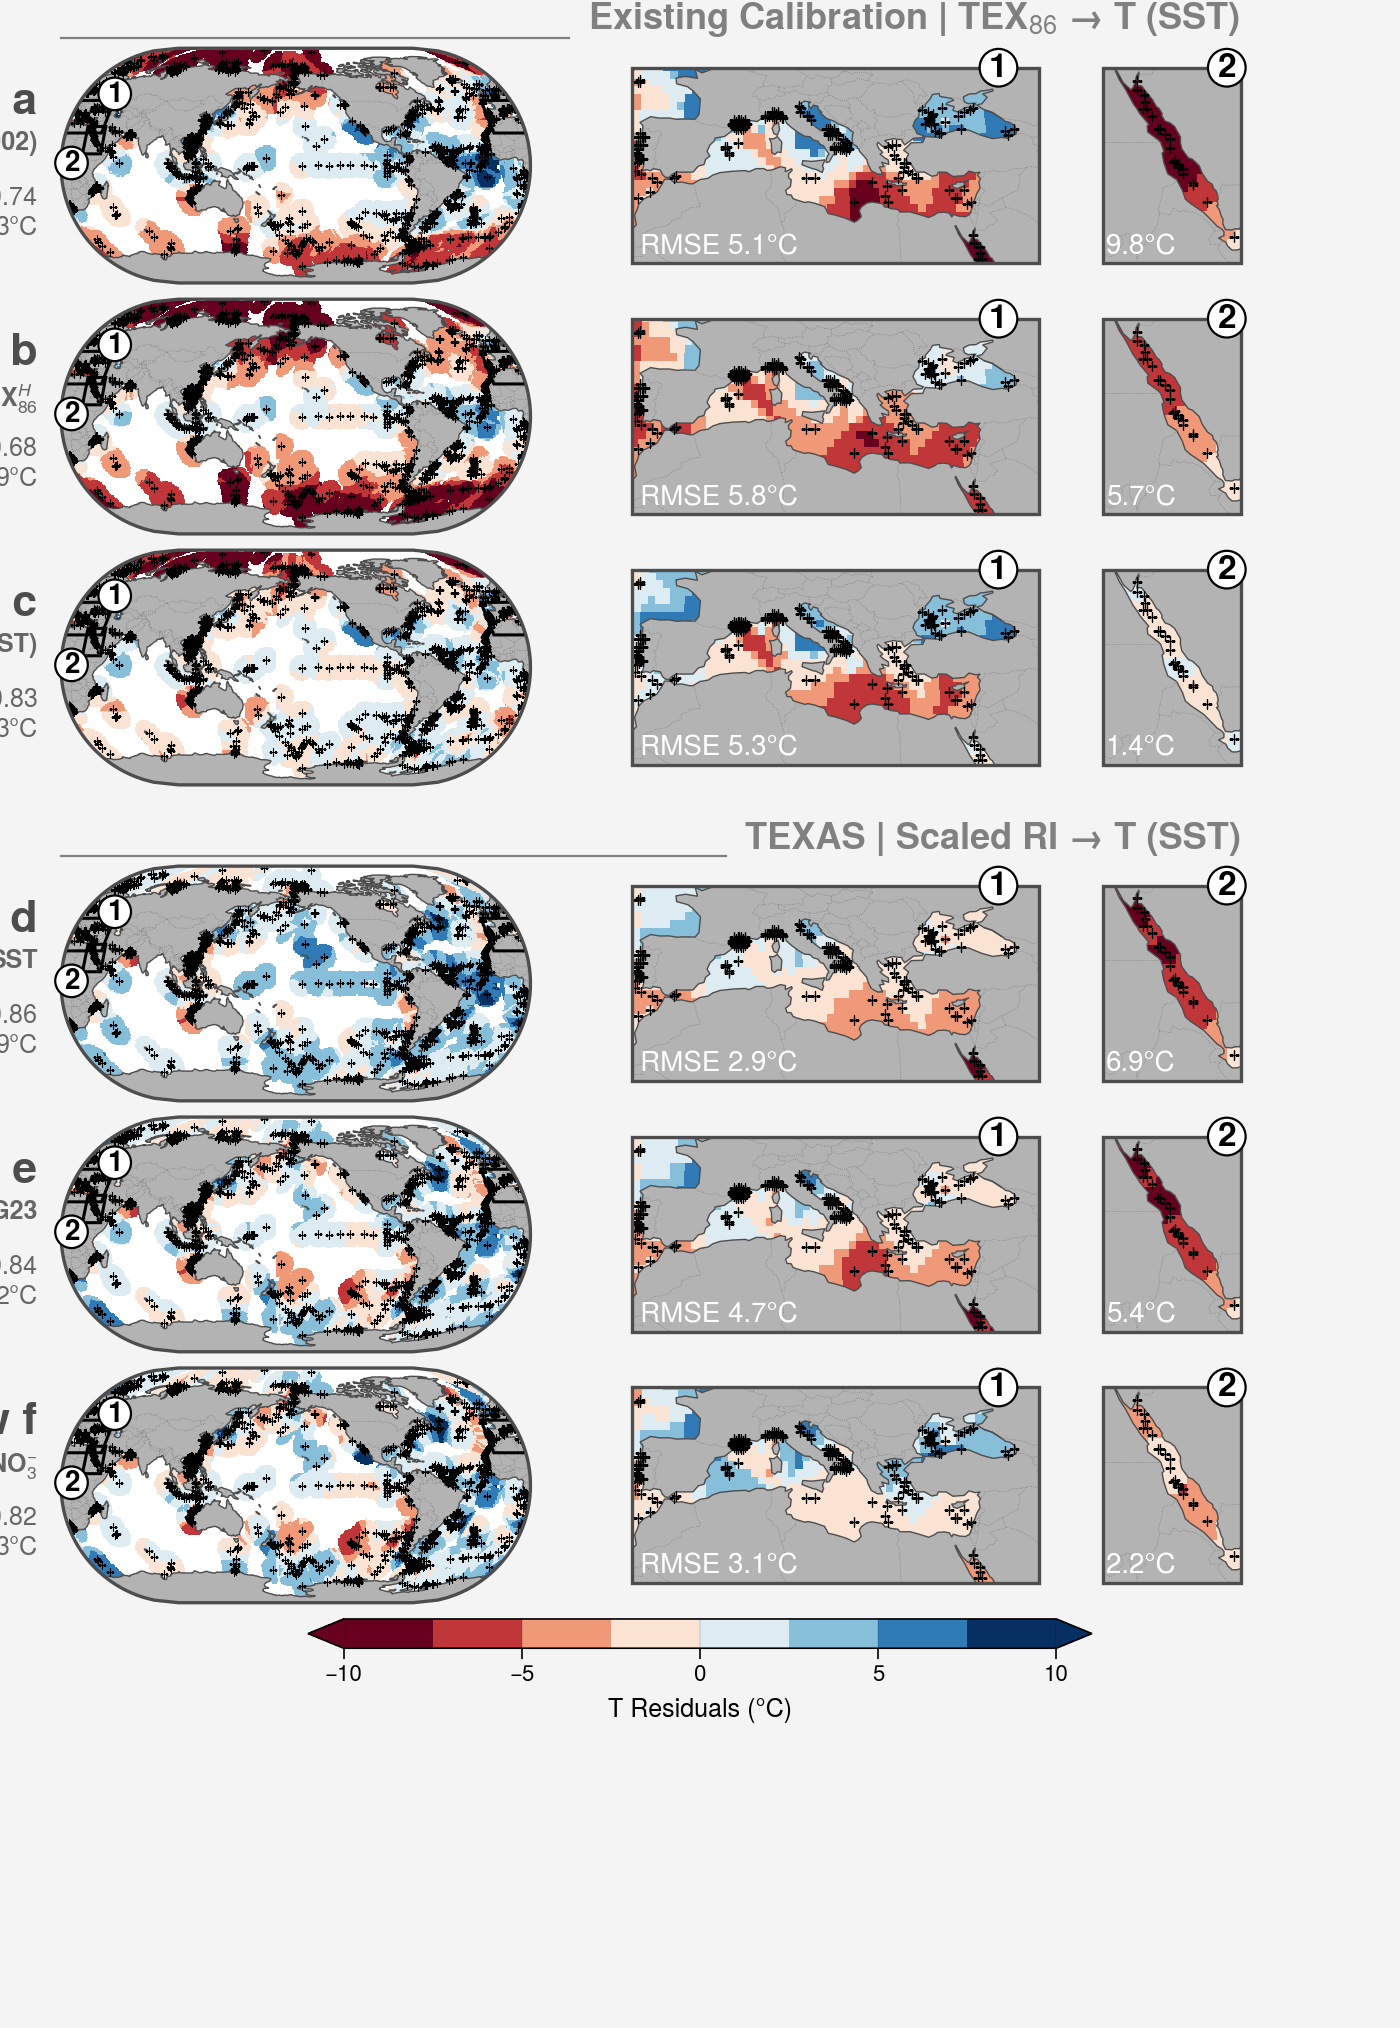

In [61]:
import importlib, TEXAS.plotting.residual_maps as _rm
importlib.reload(_rm)
importlib.reload(TEXAS)

from TEXAS.plotting.residual_maps import plot_residual_maps
importlib.reload(TEXAS.plotting.residual_maps)

# ── Coordinates ───────────────────────────────────────────────────────────────                             
lons = coretop_df["match_lon_04deg"].values    
lats = coretop_df["match_lat_04deg"].values    
    
# ── Config ────────────────────────────────────────────────────────────────────                             
sel_temp_param = "SST"
temp_param_alt = "SST"
y_param        = "scaledRI_cren3"     # key used in combined_datasets               
KRIGE_RES      = 1                    
MAX_DIST_DEG   = 10.0                    
    
# ── Predictions + residuals from invT combined_datasets ──────────────────────                              
predT_TEXAS          = combined_datasets.get((temp_param_alt, y_param, "univ"))["t_est"].sel(quantile=0.5).values                       
predT_TEXAS_g23r     = combined_datasets.get((temp_param_alt, y_param, "multiv_g23"))["t_est"].sel(quantile=0.5).values                         
predT_TEXAS_g23r_no3 = combined_datasets.get((temp_param_alt, y_param, "multiv_no3"))["t_est"].sel(quantile=0.5).values                         
    
Tres_TEXAS          = coretop_df[sel_temp_param] - predT_TEXAS                
Tres_TEXAS_g23r     = coretop_df[sel_temp_param] - predT_TEXAS_g23r           
Tres_TEXAS_g23r_no3 = coretop_df[sel_temp_param] - predT_TEXAS_g23r_no3
    
# ── data: (predictor, measured, predicted, residuals, color, label) ───────────                             
data = [
    (coretop_df['TEX86'], coretop_df[sel_temp_param], pred_TfromTEX_schouten02, T_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
    (coretop_df['TEX86'], coretop_df[sel_temp_param], pred_TfromTEX_kim2010, T_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
    (coretop_df['TEX86'], coretop_df[sel_temp_param], pred_SST_BAYSPAR_TEX86, T_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS,              Tres_TEXAS,                 "blue9",  f"{temp_param_alt}"),       
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r,         Tres_TEXAS_g23r,            "cyan9",  f"{temp_param_alt} + G23"), 
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r_no3,     Tres_TEXAS_g23r_no3,        "teal9",  f"{temp_param_alt}"+r" + G23 + NO$_{3}^{-}$"), 
]
      
# ── Plot ──────────────────────────────────────────────────────────────────────                             
fig, axs = plot_residual_maps(
    data, lons, lats,
    temp_param      = sel_temp_param,
    y_param         = y_param,
    residual_tag    = 'temp_residual',       
    recompute       = 'auto',
    krige_res       = KRIGE_RES,         
    max_dist_deg    = MAX_DIST_DEG,
    vlim            = 10.0,              
    boundary_step   = 2.5,
    cmap            = "RdBu",          
    colorbar_label  = "T Residuals (°C)",
    rmse_fmt        = ".1f",             
    rmse_unit       = "°C",
    annotations     = [(40, 55, "1"), (23, 2, "2")],  
    hspace          = [0.0, 0.0, 1, 0.0, 0.0],  
    show_grid       = False,
    lon_center      = 195,
    # zoom_show_rmse  = True,
    colorbar_ticks=[-10, -5, 0, 5, 10],                  
    section_headers = [                  
        (0, 0, r"Existing Calibration | TEX$_{86}$ → T "+f"({temp_param_alt})"),                     
        (3, 3, f"TEXAS | Scaled RI → T ({temp_param_alt})"), 
    ],          
    save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),           
    fname    = f"fig8_TEX86_calibrations_{sel_temp_param}_T_residuals_{y_param}_maps_t0shift",                   
)  

#### Fig. S13 | Spatial partitioning of nonthermal corrections in the TEXAS multivariate framework

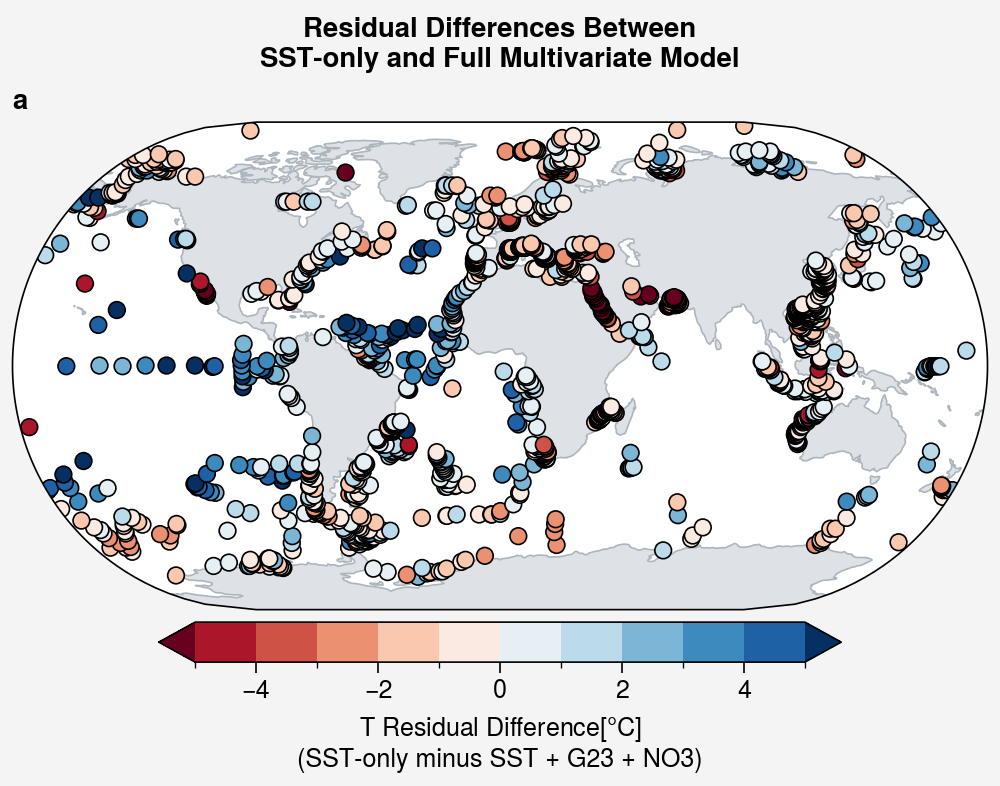

In [62]:
data = [
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS,              Tres_TEXAS,                 "blue9",  f"{temp_param_alt}"),       
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r,         Tres_TEXAS_g23r,            "cyan9",  f"{temp_param_alt} + G23"), 
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r_no3,     Tres_TEXAS_g23r_no3,        "teal9",  f"{temp_param_alt}"+r" + G23 + NO$_{3}^{-}$"), 
]

fig, axs = plot.subplots(nrows=1,width=5,proj='eck3')
axs.format(
    suptitle='Residual Differences Between\nSST-only and Full Multivariate Model',
    grid=False,
    land=True,landcolor='gray3',landzorder=0,
    coast=True,coastcolor='gray5',coastzorder=1,
)


axs1_data = data[0][3] - data[2][3]
lons = coretop_df["match_lon_04deg"].values    
lats = coretop_df["match_lat_04deg"].values  
m = axs[0].scatter(lons,lats,c=axs1_data,
               cmap='rdbu',mec='k',
               vmin=-5,vmax=5,
               levels=10,
               extend='both',
               zorder=2)
axs[0].colorbar(m,loc='b',shrink=0.7,title='T Residual Difference[$\\degree$C]\n(SST-only minus SST + G23 + NO3)')
plot.rc['abc'] = False

fpath = os.path.join(local_github_path, "figures", "manuscript", "finalized", "supplementary")
fname    = f"figS14_residual_difference_maps_multivariate_minus_SST_only_t0shift.pdf"
fig.savefig(os.path.join(fpath,fname), dpi=300)

#### Fig. S12 | Spatial distribution of subT and thermo-T residuals comparing existing TEX$_{86}$ calibrations and TEXAS for the extended global coretop dataset

Auto cache path: /home/ronnie-rattan/Documents/GitHub/TEXAS/data/cache/kriged_grids_1deg_10dmax_woa23_t_sf2tc_avg_scaledRI_cren3_temp_residual.npz
Loaded grids cache ← /home/ronnie-rattan/Documents/GitHub/TEXAS/data/cache/kriged_grids_1deg_10dmax_woa23_t_sf2tc_avg_scaledRI_cren3_temp_residual.npz
Grids loaded/built (4 halo + 4 true panels)
Saved → /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/finalized/main-text/figS13_TEX86_calibrations_t_sf2tc_avg_T_residuals_scaledRI_cren3_maps_t0shift


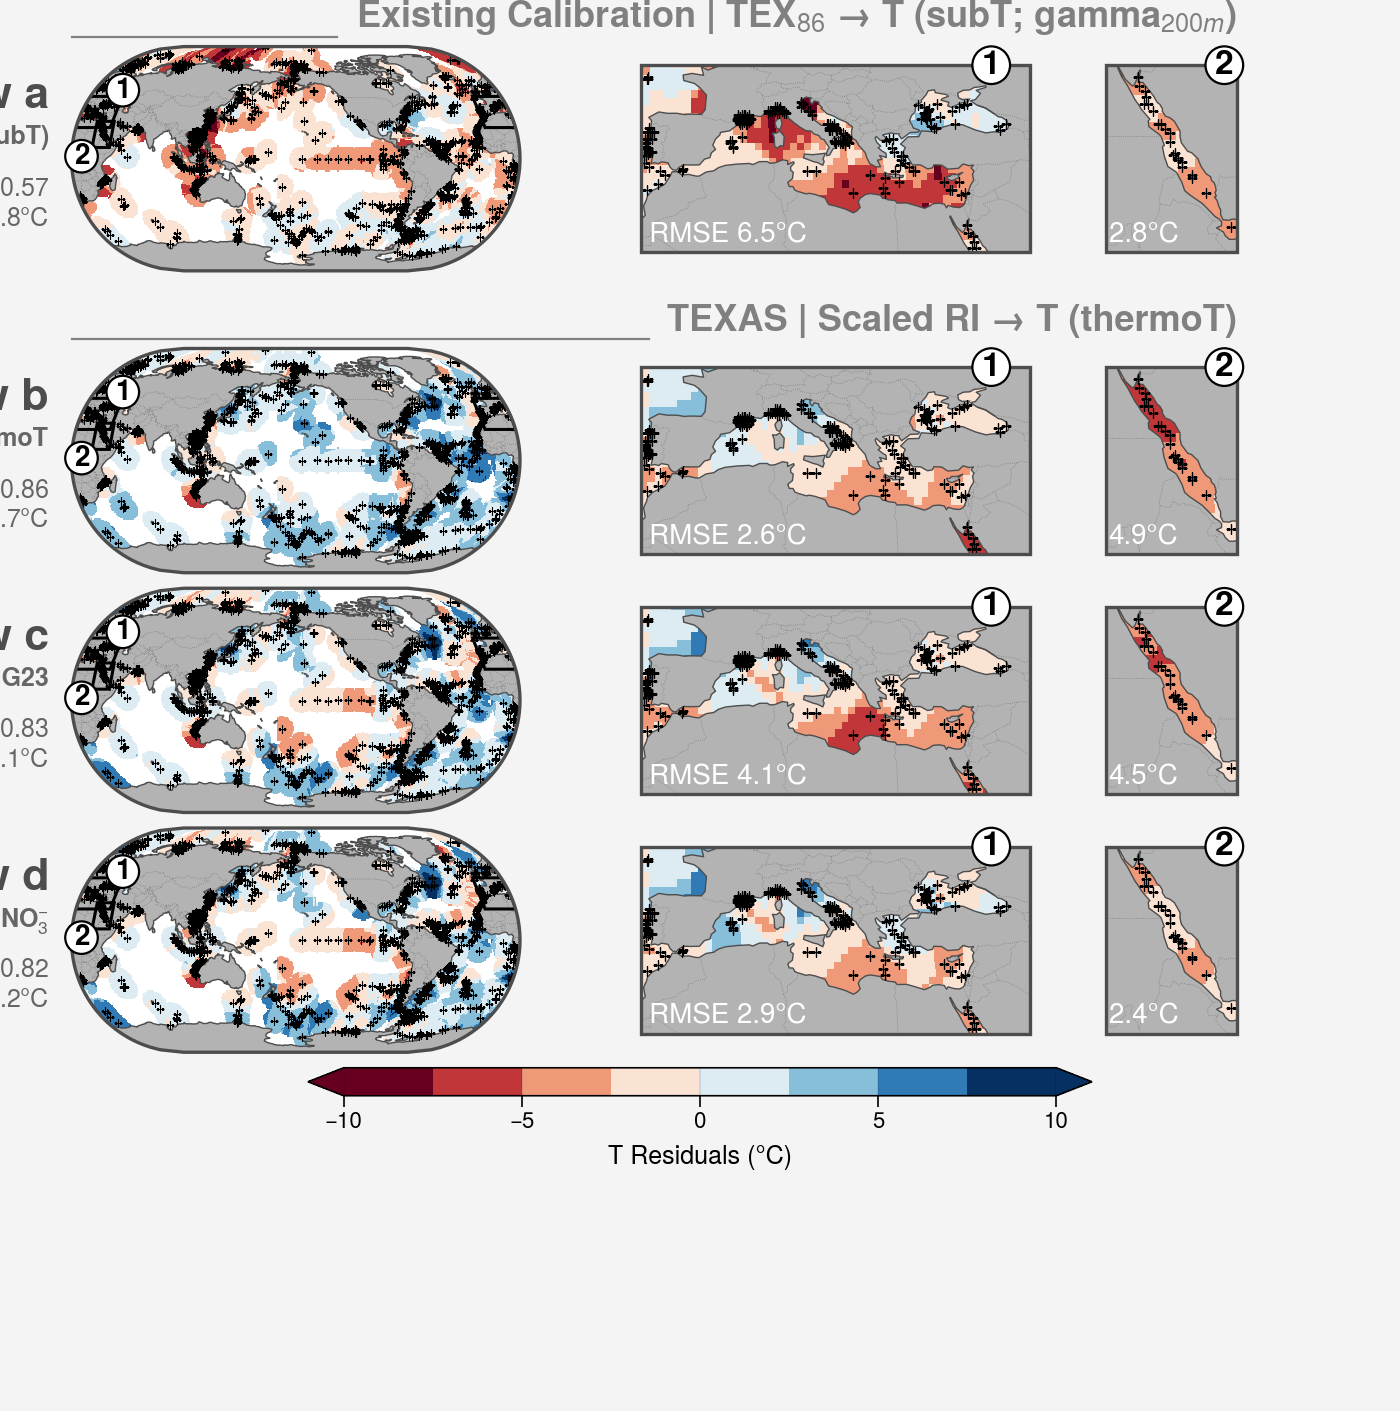

In [63]:
import importlib, TEXAS.plotting.residual_maps as _rm
importlib.reload(_rm)
importlib.reload(TEXAS)

from TEXAS.plotting.residual_maps import plot_residual_maps
importlib.reload(TEXAS.plotting.residual_maps)                      
    
# ── Coordinates ───────────────────────────────────────────────────────────────                             
lons = coretop_df["match_lon_04deg"].values    
lats = coretop_df["match_lat_04deg"].values    
    
# ── Config ────────────────────────────────────────────────────────────────────                             
sel_temp_param = "t_sf2tc_avg"
temp_param_alt = "thermoT"
y_param        = "scaledRI_cren3"     # key used in combined_datasets               
KRIGE_RES      = 1                    
MAX_DIST_DEG   = 10.0                    
    
# ── Predictions + residuals from invT combined_datasets ──────────────────────                              
predT_TEXAS          = combined_datasets.get((temp_param_alt, y_param, "univ"))["t_est"].sel(quantile=0.5).values                       
predT_TEXAS_g23r     = combined_datasets.get((temp_param_alt, y_param, "multiv_g23"))["t_est"].sel(quantile=0.5).values                         
predT_TEXAS_g23r_no3 = combined_datasets.get((temp_param_alt, y_param, "multiv_no3"))["t_est"].sel(quantile=0.5).values                         
    
Tres_TEXAS          = coretop_df[sel_temp_param] - predT_TEXAS                
Tres_TEXAS_g23r     = coretop_df[sel_temp_param] - predT_TEXAS_g23r           
Tres_TEXAS_g23r_no3 = coretop_df[sel_temp_param] - predT_TEXAS_g23r_no3       
    
# ── data: (predictor, measured, predicted, residuals, color, label) ───────────                             
data = [  
    (coretop_df["TEX86"], coretop_df["subT_gamma"], pred_subT_BAYSPAR_TEX86,  T_residuals_BAYSPAR_subT,   "grape9", "BAYSPAR (SubT)"), 
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS,              Tres_TEXAS,                 "blue9",  f"{temp_param_alt}"),       
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r,         Tres_TEXAS_g23r,            "cyan9",  f"{temp_param_alt} + G23"), 
    (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r_no3,     Tres_TEXAS_g23r_no3,        "teal9",  f"{temp_param_alt}"+r" + G23 + NO$_{3}^{-}$"), 
]   
    

# ── Plot ──────────────────────────────────────────────────────────────────────                             
fig, axs = plot_residual_maps(
    data, lons, lats,
    temp_param      = sel_temp_param,
    y_param         = y_param,
    residual_tag    = 'temp_residual',       
    recompute       = 'auto',
    krige_res       = KRIGE_RES,         
    max_dist_deg    = MAX_DIST_DEG,
    vlim            = 10.0,              
    boundary_step   = 2.5,
    cmap            = "RdBu",          
    colorbar_label  = "T Residuals (°C)",
    rmse_fmt        = ".1f",             
    rmse_unit       = "°C",
    annotations     = [(40, 55, "1"), (23, 2, "2")],  
    hspace          = [1, 0.0, 0.0],  
    show_grid       = False,
    lon_center      = 195,
    # zoom_show_rmse  = True,
    colorbar_ticks=[-10, -5, 0, 5, 10],                           
    section_headers = [                  
        (0, 0, r"Existing Calibration | TEX$_{86}$ → T (subT; gamma$_{200m}$)"),                     
        (1, 1, f"TEXAS | Scaled RI → T ({temp_param_alt})"), 
    ],          
    save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),           
    fname    = f"figS13_TEX86_calibrations_{sel_temp_param}_T_residuals_{y_param}_maps_t0shift",                   
)  

# Uncertainty maps

lons length: 1513
  BAYSPAR (SST)                                  len=1513  nan=0
  SST                                            len=1513  nan=0
  SST + G23                                      len=1513  nan=0
  SST + G23 + NO$_{3}^{-}$                       len=1513  nan=0
±1σ summary (°C):
  BAYSPAR (SST)                                  median=3.3  p5=2.0  p95=4.7
  SST                                            median=5.1  p5=3.2  p95=8.9
  SST + G23                                      median=3.9  p5=2.0  p95=8.0
  SST + G23 + NO$_{3}^{-}$                       median=3.8  p5=1.9  p95=7.9
Parallel kriging: 4 panels on 4 workers ...


/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/plotting/residual_maps.py:57: UserWarning: `natural_earth_v5_0_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  _OCEAN_BASINS_50 = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50
/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/plotting/residual_maps.py:57: UserWarning: `natural_earth_v5_0_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  _OCEAN_BASINS_50 = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50
/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/plotting/residual_maps.py:57: UserWarning: `natural_earth_v5_0_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` inste

  [1] Kriging halo: BAYSPAR (SST) ...
  [2] Kriging halo: SST ...
  [3] Kriging halo: SST + G23 ...
  [4] Kriging halo: SST + G23 + NO$_{3}^{-}$ ...
  [2] nugget=4.8542  sill=100.8508  range=0.000
  [1] nugget=1.2726  sill=367.3138  range=0.222
  [4] nugget=5.5514  sill=109.3982  range=0.000
  [3] nugget=5.4681  sill=108.2975  range=0.000
  [1] done. unmasked=40754
  [2] done. unmasked=40754
  [4] done. unmasked=40754
  [3] done. unmasked=40754
Grids loaded/built (4 halo + 4 true panels)
Saved → /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/finalized/main-text/fig9_TEXAS_1sigma_uncertainty_maps_p16p84_SST_scaledRI_cren3_t0shift


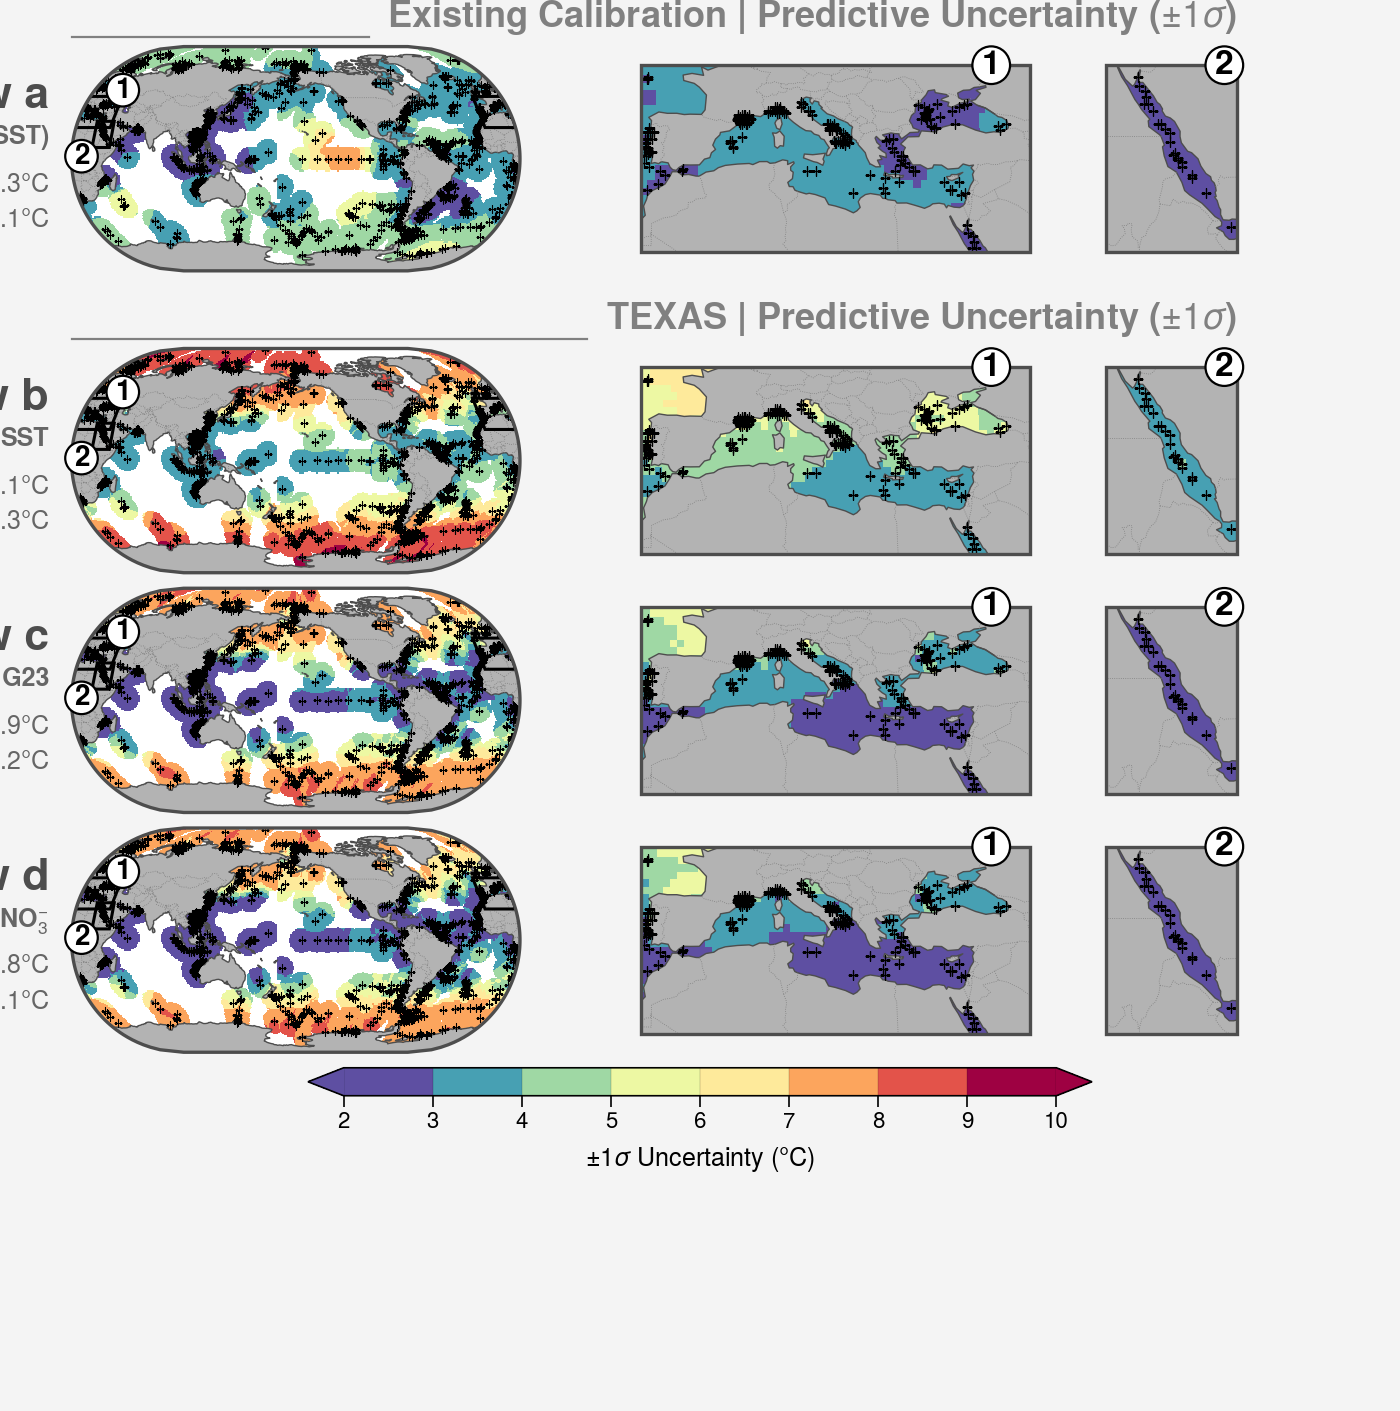

In [64]:
# ============================================================================
# FIGURE: ±1σ Uncertainty Maps
# ============================================================================
%matplotlib inline
import numpy as np
import pandas as pd
import os
import importlib, TEXAS.plotting.residual_maps as _rm
importlib.reload(_rm)
importlib.reload(TEXAS)

from TEXAS.plotting.residual_maps import plot_residual_maps
importlib.reload(TEXAS.plotting.residual_maps)     

# ── Read predictions ─────────────────────────────────────────────────
lons = coretop_df['match_lon_04deg'].values
lats = coretop_df['match_lat_04deg'].values

def _read_texas(fname, quantile):
    return combined_datasets.get(fname)['t_est'].sel(quantile=quantile).values

temp_param = 'SST'
y_param = 'scaledRI_cren3'
temp_param_bsr = 'SST'
_fname_univ = (temp_param,y_param,'univ')
_fname_g23  = (temp_param,y_param,'multiv_g23')
_fname_g23_no3  = (temp_param,y_param,'multiv_no3')

predT_TEXAS_T_p16     = _read_texas(_fname_univ, 0.16)
predT_TEXAS_T_p84     = _read_texas(_fname_univ, 0.84)
predT_TEXAS_T_g23r_p16 = _read_texas(_fname_g23, 0.16)
predT_TEXAS_T_g23r_p84 = _read_texas(_fname_g23, 0.84)
predT_TEXAS_T_g23r_no3_p16 = _read_texas(_fname_g23_no3, 0.16)
predT_TEXAS_T_g23r_no3_p84 = _read_texas(_fname_g23_no3, 0.84)

def _sigma(p16, p84):
    return (p84 - p16) / 2

sigmas = {
    'bayspar': _sigma(pred_SST_BAYSPAR_TEX86_p16, pred_SST_BAYSPAR_TEX86_p84),
    'univ':    _sigma(predT_TEXAS_T_p16,         predT_TEXAS_T_p84),
    'g23':     _sigma(predT_TEXAS_T_g23r_p16,    predT_TEXAS_T_g23r_p84),
    'g23_no3': _sigma(predT_TEXAS_T_g23r_no3_p16, predT_TEXAS_T_g23r_no3_p84),
}

# ── data list ────────────────────────────────────────────────────────
_variants = [
    ('bayspar', 'grape9', f'BAYSPAR ({temp_param_bsr})'),
    ('univ',    'blue9',  f'{temp_param}'),
    ('g23',     'cyan9',  f'{temp_param} + G23'),
    ('g23_no3', 'teal9',  f'{temp_param}'+r' + G23 + NO$_{3}^{-}$'),
]

print("lons length:", len(lons))
for vkey, _, label in _variants:
    s = sigmas[vkey]
    print(f"  {label:<45}  len={len(s)}  nan={np.sum(np.isnan(s))}")

data = [
    (None, None, None, pd.Series(sigmas[vkey]), color, label)
    for vkey, color, label in _variants
]

# ── Summary ──────────────────────────────────────────────────────────
print("±1σ summary (°C):")
for (vkey, _, label), (_, _, _, s, _, _) in zip(_variants, data):
    v = s.values
    print(f"  {label:<45}  median={np.nanmedian(v):.1f}  "
        f"p5={np.nanpercentile(v,5):.1f}  p95={np.nanpercentile(v,95):.1f}")

# ── Row annotations (mean σ) ─────────────────────────────────────────
row_annotations = []
for vkey, _, _ in _variants:
    sigma_vals = sigmas[vkey].values if hasattr(sigmas[vkey], "values") else np.array(sigmas[vkey])
    global_median = np.nanmedian(sigma_vals)
    tropic_median = np.nanmedian(sigma_vals[(lats >= -60) & (lats <= 60)])
    row_annotations.append(
        f"$\\mathbf{{\\tilde{{\\sigma}}}}$ {global_median:.1f}°C\n"
        u"$\\mathbf{{\\tilde{{\\sigma}}}}_{{60^\\circ\\mathrm{{S}}\u201360^\\circ\\mathrm{{N}}}}$"+f" {tropic_median:.1f}°C"
    )

# ── Plot ──────────────────────────────────────────────────────────────
fig, axs = plot_residual_maps(
    data, lons, lats,
    residual_tag = 'uncertainty',
    recompute='auto',
    vmin=2.0, vmax=10.0, boundary_step=1,
    cmap='spectral_r',
    colorbar_label=r'$\pm 1\sigma$ Uncertainty (°C)',
    row_annotations=row_annotations,
    annotations=[(40, 55, "1"), (23, 2, "2")],
    section_headers=[
        (0, 0, r'Existing Calibration | Predictive Uncertainty ($\pm 1\sigma$)'),
        (1, 1, r'TEXAS | Predictive Uncertainty ($\pm 1\sigma$)'),
    ],
    hspace=[1,0,0],
    show_grid=False,
    lon_center      = 195,
    colorbar_ticks=[2,3,4,5,6,7,8,9,10],
    krige_res=1,
    fig_width=7,
)

# ── Save ──────────────────────────────────────────────────────────────
fpath = os.path.join(local_github_path, 'figures', 'manuscript', 'finalized', 'main-text')
fname = f'fig9_TEXAS_1sigma_uncertainty_maps_p16p84_{temp_param}_{y_param}_t0shift'
fig.savefig(os.path.join(fpath, fname + '.png'), dpi=400, facecolor='white', bbox_inches='tight')
fig.savefig(os.path.join(fpath, fname + '.pdf'), dpi=400, facecolor='white', bbox_inches='tight')
print(f"Saved → {os.path.join(fpath, fname)}")

±1σ summary (°C):
  BAYSPAR (SubT)                                 median=3.3  p5=2.7  p95=4.6
  thermoT                                        median=5.0  p5=2.6  p95=8.8
  thermoT + G23                                  median=3.7  p5=1.9  p95=7.8
  thermoT + G23 + NO$_{3}^{-}$                   median=3.7  p5=1.9  p95=7.8
Parallel kriging: 4 panels on 4 workers ...
  [1] Kriging halo: BAYSPAR (SubT) ...
  [2] Kriging halo: thermoT ...
  [3] Kriging halo: thermoT + G23 ...
  [4] Kriging halo: thermoT + G23 + NO$_{3}^{-}$ ...
  [1] nugget=0.4397  sill=52.0237  range=0.001
  [2] nugget=5.7484  sill=98.0435  range=0.000
  [3] nugget=5.6035  sill=106.1920  range=0.000
  [4] nugget=5.3369  sill=108.2120  range=0.000
  [3] done. unmasked=40754
  [1] done. unmasked=40754
  [4] done. unmasked=40754
  [2] done. unmasked=40754
Grids loaded/built (4 halo + 4 true panels)
Saved → /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/finalized/main-text/figXX_TEXAS_1sigma_uncertainty_maps_

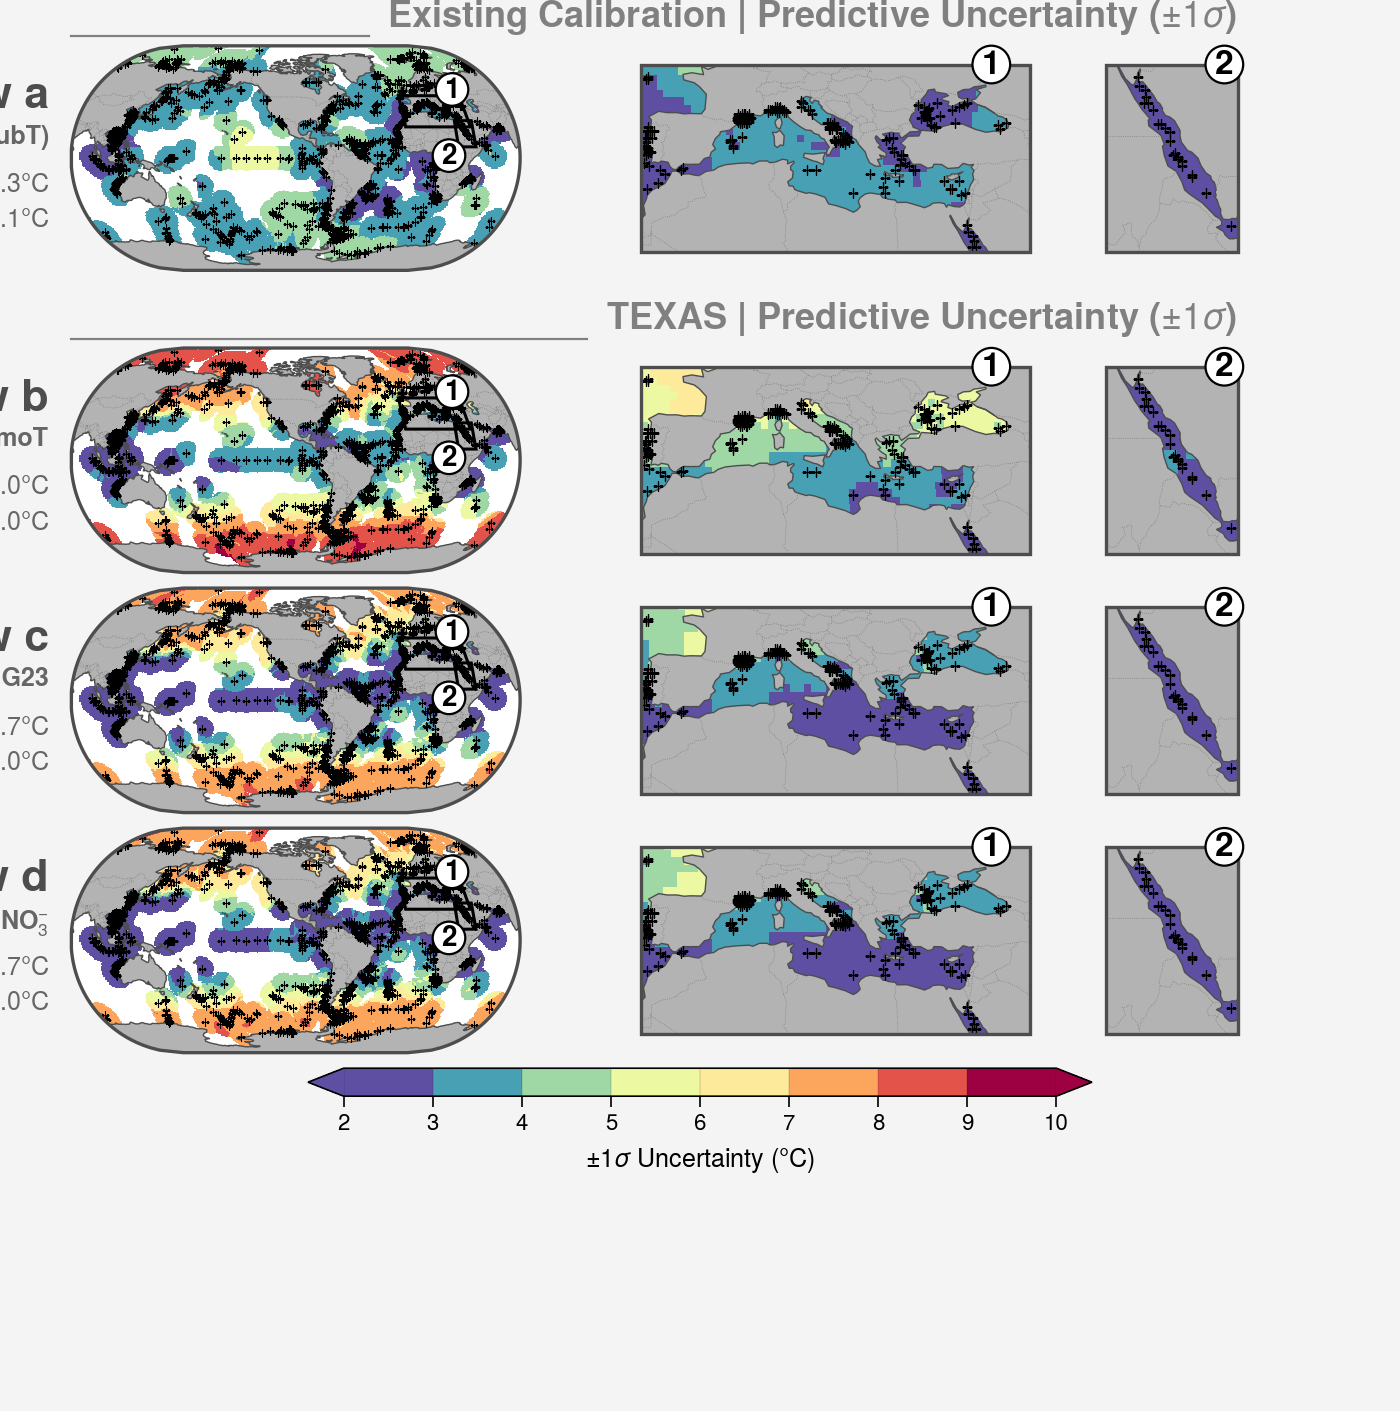

In [65]:
# ============================================================================
# FIGURE: ±1σ Uncertainty Maps
# ============================================================================
%matplotlib inline
import numpy as np
import pandas as pd
import os
from TEXAS.plotting.residual_maps import plot_residual_maps

# ── Read predictions ─────────────────────────────────────────────────
lons = coretop_df['match_lon_04deg'].values
lats = coretop_df['match_lat_04deg'].values

def _read_texas(fname, quantile):
    return combined_datasets.get(fname)['t_est'].sel(quantile=quantile).values

temp_param = 'thermoT'
y_param = 'scaledRI_cren3'
temp_param_bsr = 'SubT'
_fname_univ = (temp_param,y_param,'univ')
_fname_g23  = (temp_param,y_param,'multiv_g23')
_fname_g23_no3  = (temp_param,y_param,'multiv_no3')

predT_TEXAS_T_p16     = _read_texas(_fname_univ, 0.16)
predT_TEXAS_T_p84     = _read_texas(_fname_univ, 0.84)
predT_TEXAS_T_g23r_p16 = _read_texas(_fname_g23, 0.16)
predT_TEXAS_T_g23r_p84 = _read_texas(_fname_g23, 0.84)
predT_TEXAS_T_g23r_no3_p16 = _read_texas(_fname_g23_no3, 0.16)
predT_TEXAS_T_g23r_no3_p84 = _read_texas(_fname_g23_no3, 0.84)

def _sigma(p16, p84):
    return (p84 - p16) / 2

sigmas = {
    'bayspar': _sigma(pred_subT_BAYSPAR_TEX86_p16, pred_subT_BAYSPAR_TEX86_p84),
    'univ':    _sigma(predT_TEXAS_T_p16,         predT_TEXAS_T_p84),
    'g23':     _sigma(predT_TEXAS_T_g23r_p16,    predT_TEXAS_T_g23r_p84),
    'g23_no3': _sigma(predT_TEXAS_T_g23r_no3_p16, predT_TEXAS_T_g23r_no3_p84),
}

# ── data list ────────────────────────────────────────────────────────
_variants = [
    ('bayspar', 'grape9', f'BAYSPAR ({temp_param_bsr})'),
    ('univ',    'blue9',  f'{temp_param}'),
    ('g23',     'cyan9',  f'{temp_param} + G23'),
    ('g23_no3', 'teal9',  f'{temp_param}'+r' + G23 + NO$_{3}^{-}$'),
]

data = [
    (None, None, None, pd.Series(sigmas[vkey]), color, label)
    for vkey, color, label in _variants
]

# ── Summary ──────────────────────────────────────────────────────────
print("±1σ summary (°C):")
for (vkey, _, label), (_, _, _, s, _, _) in zip(_variants, data):
    v = s.values
    print(f"  {label:<45}  median={np.nanmedian(v):.1f}  "
        f"p5={np.nanpercentile(v,5):.1f}  p95={np.nanpercentile(v,95):.1f}")

# ── Row annotations (mean σ) ─────────────────────────────────────────
row_annotations = []
for vkey, _, _ in _variants:
    sigma_vals = sigmas[vkey].values if hasattr(sigmas[vkey], "values") else np.array(sigmas[vkey])
    global_median = np.nanmedian(sigma_vals)
    tropic_median = np.nanmedian(sigma_vals[(lats >= -60) & (lats <= 60)])
    row_annotations.append(
        f"$\\mathbf{{\\tilde{{\\sigma}}}}$ {global_median:.1f}°C\n"
        u"$\\mathbf{{\\tilde{{\\sigma}}}}_{{60^\\circ\\mathrm{{S}}\u201360^\\circ\\mathrm{{N}}}}$"+f" {tropic_median:.1f}°C"
    )

# ── Plot ──────────────────────────────────────────────────────────────
fig, axs = plot_residual_maps(
    data, lons, lats,
    residual_tag = 'uncertainty',
    recompute=True,
    vmin=2.0, vmax=10.0, boundary_step=1.0,
    cmap='spectral_r',
    colorbar_label=r'$\pm 1\sigma$ Uncertainty (°C)',
    row_annotations=row_annotations,
    annotations=[(40, 55, "1"), (23, 2, "2")],
    section_headers=[
        (0, 0, r'Existing Calibration | Predictive Uncertainty ($\pm 1\sigma$)'),
        (1, 1, r'TEXAS | Predictive Uncertainty ($\pm 1\sigma$)'),
    ],
    hspace=[1,0,0],
    show_grid=False,  
    colorbar_ticks=[2,3,4,5,6,7,8,9,10],
    fig_width=7,
)

# ── Save ──────────────────────────────────────────────────────────────
fpath = os.path.join(local_github_path, 'figures', 'manuscript', 'finalized', 'main-text')
fname = f'figXX_TEXAS_1sigma_uncertainty_maps_p16p84_{temp_param}_{y_param}_t0shift'
fig.savefig(os.path.join(fpath, fname + '.png'), dpi=400, facecolor='white', bbox_inches='tight')
fig.savefig(os.path.join(fpath, fname + '.pdf'), dpi=400, facecolor='white', bbox_inches='tight')
print(f"Saved → {os.path.join(fpath, fname)}")

In [66]:
# Replace both fig.savefig calls at the bottom with:
from matplotlib.backends.backend_pdf import FigureCanvasPdf
from matplotlib.backends.backend_agg import FigureCanvasAgg

FigureCanvasAgg(fig).print_figure(
    os.path.join(fpath, fname + '.png'),
    dpi=400, facecolor='white', bbox_inches='tight',
)
FigureCanvasPdf(fig).print_figure(
    os.path.join(fpath, fname + '.pdf'),
    dpi=400, facecolor='white', bbox_inches='tight',
)
print(f"Saved → {os.path.join(fpath, fname)}")

Saved → /home/ronnie-rattan/Documents/GitHub/TEXAS/figures/manuscript/finalized/main-text/figXX_TEXAS_1sigma_uncertainty_maps_p16p84_thermoT_scaledRI_cren3_t0shift
